<a href="https://colab.research.google.com/github/aaa923804918-max/mooncake/blob/main/Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project**

## **installation and setup**

In [ ]:
# This cell handles all installation, imports, ONE API setup, and utility function definitions for the project.
# If you encounter 'ModuleNotFoundError' after running this cell, please restart the Colab runtime (Runtime > Restart runtime) and run this cell again.

# --- 1. Install dependencies ---
! pip install ONE-api --quiet
! pip install ibllib --quiet
! pip install iblutil --quiet
! pip install ibl_style --quiet

# --- 2. Imports ---
import os
import sys
import pandas as pd
import numpy as np
from scipy import sparse
import zipfile
import tqdm
import scipy.stats as stats
from scipy.ndimage import gaussian_filter1d
from iblutil.util import Bunch

from one.api import ONE
from one.remote.aws import s3_download_file

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# --- 3. Setup ONE API ---
# When running in jupyter set number of threads to 1
os.environ.setdefault('ONE_HTTP_DL_THREADS', '1')

ONE.setup(base_url='https://openalyx.internationalbrainlab.org', silent=True)
one = ONE(password='international')

# This is to view dataframe interactively in Google colab
if 'google.colab' in sys.modules:
    from google.colab import data_table
    data_table.enable_dataframe_formatter()

# This is to style figures
if sys.version_info >= (3, 10):
    from ibl_style.style import figure_style
    figure_style()

# --- 4. Define loading utility functions ---
def download_data(event):
  assert event in ['firstMove', 'stimOn', 'feedback'], 'event must be one of "firstMove", "stimOn" or "feedback'

  # Dataset name
  fname = f'data_{event}.zip'
  # Remote location of data
  s3_data_path = f'sample_data/Neuromatch/{fname}'
  # Local location to download data to
  save_path = one.cache_dir.joinpath('Neuromatch', fname)
  save_path.parent.mkdir(exist_ok=True, parents=True)

  # Download file
  file = s3_download_file(s3_data_path, save_path)
  # Unzip content
  with zipfile.ZipFile(file, 'r') as zip_ref:
    zip_ref.extractall(save_path.parent)


def get_data_path(event):
  return one.cache_dir.joinpath('Neuromatch', f'data_{event}')


def load_metadata(event):
  metadata = Bunch()
  data_path = get_data_path(event)
  metadata['clusters'] = pd.read_parquet(data_path.joinpath('clusters.pqt'))
  metadata['trials'] = pd.read_parquet(data_path.joinpath('trials.pqt'))
  metadata['sessions'] = pd.read_parquet(data_path.joinpath('sessions.pqt'))
  metadata['times'] = np.load(data_path.joinpath('t.npy'))
  metadata['nbins'] = metadata['times'].size
  metadata['dt'] = np.round(np.median(np.diff(metadata['times'])), 2)
  metadata['data_path'] = data_path
  return metadata


def load_times(data_path):
  return np.load(data_path.joinpath('t.npy'))


def load_psth(data_path, pid, nbins=150):
    psth = sparse.load_npz(data_path.joinpath(f'{pid}.npz')).toarray()
    psth = psth.reshape(psth.shape[0], -1, nbins)
    return psth

# --- 5. Define processing utility functions ---
def split_trials_by_variable(trials, split='contrast'):
  trials = trials.set_index('psth_index')
  if split == 'contrast':
    trials['contrast'] = np.nansum([trials['contrastLeft'], trials['contrastRight']], axis=0) * 100
    grp = trials.groupby('contrast')
  elif split == 'signed contrast':
    trials['signedContrast'] = np.nansum([-1 * trials['contrastLeft'], trials['contrastRight']], axis=0) * 100
    grp = trials.groupby('signedContrast')
  elif split == 'stimulus':
    trials['stimulus'] = 'right'
    trials.loc[trials['contrastRight'].isna(), 'stimulus'] = 'left'
    grp = trials.groupby('stimulus')
  elif split == 'choice':
    grp = trials.groupby('choice')
  elif split == 'block':
    grp = trials.groupby('probabilityLeft')
  else:
    raise NotImplementedError('split must be one of "contrast", "signed contrast", "stimulus", "choice" or "block"')
  return grp.groups


def get_avg_psth_for_insertion(pid, meta, reg=None, uuids=None, split=None):
  df = meta.clusters[meta.clusters['pid'] == pid]
  df = df[['acronym', 'pid', 'uuids', 'cluster_id', 'psth_index']]
  sp = load_psth(meta.data_path, pid, nbins=meta.nbins)

  if reg is not None:
    in_reg = df['acronym'] == reg
    sp = sp[:, in_reg.values, :]
    df = df[in_reg].reset_index(drop=True)

  if uuids is not None:
    in_uuid = df['uuids'].isin(uuids)
    sp = sp[:, in_uuid.values, :]
    df = df[in_uuid].reset_index(drop=True)

  if split is None:
    psth = sp.mean(axis=0) / meta['dt']
  else:
    psth = dict()
    eid = meta.sessions[meta.sessions['pid'] == pid].iloc[0]['eid']
    trials = meta.trials[meta.trials['eid'] == eid].reset_index(drop=True)
    grps = split_trials_by_variable(trials, split=split)

    for key, vals in grps.items():
      psth[key] = sp[vals, :, :].mean(axis=0)

  return psth, df

def get_avg_psth_for_region(reg, meta, split=None):
  clusters = meta.clusters[meta.clusters['acronym'] == reg]
  pids = clusters['pid'].unique()
  all_df = []
  all_psth = []
  for pid in pids:
    psth, df = get_avg_psth_for_insertion(pid, meta, reg=reg, split=split)
    all_df.append(df)
    all_psth.append(psth)

  all_df = pd.concat(all_df).reset_index(drop=True)
  if split is None:
    all_psth = np.concatenate(all_psth)
  else:
    all_psth = {key: np.concatenate([d[key] for d in all_psth if key in d.keys()])
    for key in all_psth[0]}

  return all_psth, all_df


def get_avg_psth_for_clusters(uuids, meta, split=None):
  clusters = meta.clusters[meta.clusters['uuids'].isin(uuids)]
  pids = clusters['pid'].unique()
  all_df = []
  all_psth = []
  for pid in pids:
    psth, df = get_avg_psth_for_insertion(pid, meta, uuids=uuids, split=split)
    all_df.append(df)
    all_psth.append(psth)

  all_df = pd.concat(all_df).reset_index(drop=True)
  if split is None:
    all_psth = np.concatenate(all_psth)
  else:
    all_psth = {key: np.concatenate([d[key] for d in all_psth if key in d.keys()])
    for key in all_psth[0]}

  return all_psth, all_df


def get_psth_for_insertion(pid, meta, reg=None, uuids=None):
  df = meta.clusters[meta.clusters['pid'] == pid]
  df = df[['acronym', 'pid', 'uuids', 'cluster_id', 'psth_index']]
  sp = load_psth(meta.data_path, pid, nbins=meta.nbins)

  if reg is not None:
    in_reg = df['acronym'] == reg
    sp = sp[:, in_reg.values, :]
    df = df[in_reg].reset_index(drop=True)

  if uuids is not None:
    in_uuid = df['uuids'].isin(uuids)
    sp = sp[:, in_uuid.values, :]
    df = df[in_uuid].reset_index(drop=True)

  eid = meta.sessions[meta.sessions['pid'] == pid].iloc[0]['eid']
  trials = meta.trials[meta.trials['eid'] == eid].reset_index(drop=True)
  psth = sp / meta['dt']
  return psth, df, trials


def get_psth_for_region(reg, meta):
  clusters = meta.clusters[meta.clusters['acronym'] == reg]
  pids = clusters['pid'].unique()
  all_clust = []
  all_psth = []
  all_trials = []
  for pid in pids:
    psth, clust, trials = get_psth_for_insertion(pid, meta, reg=reg)
    all_clust.append(clust)
    all_psth.append(psth)
    all_trials.append(trials)
  return all_psth, all_clust, all_trials


def get_psth_for_clusters(uuids, meta):
  clusters = meta.clusters[meta.clusters['uuids'].isin(uuids)]
  pids = clusters['pid'].unique()
  all_clust = []
  all_psth = []
  all_trials = []
  for pid in pids:
    psth, clust, trials = get_psth_for_insertion(pid, meta, uuids=uuids)
    all_clust.append(clust)
    all_psth.append(psth)
    all_trials.append(trials)
  return all_psth, all_clust, all_trials

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 132.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 120.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 11.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 124.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.6/442.6 kB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.6/102.6 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.0/48.0 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.1

In [ ]:
import random
import numpy as np
import torch

def set_seed(seed=42):
    """Set global random seed for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

# Apply the global seed
set_seed(42)
print("Global random seed is set to 42 for reproducibility.")


Global random seed is set to 42 for reproducibility.


In [ ]:
download_data('stimOn')
download_data('firstMove')

(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/Neuromatch/data_stimOn.zip: 100%|██████████| 810M/810M [00:05<00:00, 152MB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/Neuromatch/data_firstMove.zip: 100%|██████████| 823M/823M [00:05<00:00, 151MB/s]


In [ ]:
import random
import numpy as np
import torch

def set_seed(seed=42):
    """Set global random seed for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

# Apply the global seed
set_seed(42)
print("Global random seed is set to 42 for reproducibility.")

Global random seed is set to 42 for reproducibility.


## **Analysis**

## **ROI**

In [ ]:
import pandas as pd
import numpy as np

# Define the ROIs as specified
PFC = ['PL', 'ILA', 'ACAd', 'ACAv', 'FRP', 'ORBl', 'ORBm', 'ORBvl']
MOs_region = ['MOs']
MOp_region = ['MOp']

roi_dict = {'PFC': PFC, 'MOs': MOs_region, 'MOp': MOp_region}

print(f"Defined ROIs:\nPFC: {PFC}\nMOs: {MOs_region}\nMOp: {MOp_region}")


Defined ROIs:
PFC: ['PL', 'ILA', 'ACAd', 'ACAv', 'FRP', 'ORBl', 'ORBm', 'ORBvl']
MOs: ['MOs']
MOp: ['MOp']


In [ ]:
# Combine into superregion
superregion = list(np.unique(PFC + MOs_region + MOp_region))
print(f"Superregion: {superregion}")


Superregion: [np.str_('ACAd'), np.str_('ACAv'), np.str_('FRP'), np.str_('ILA'), np.str_('MOp'), np.str_('MOs'), np.str_('ORBl'), np.str_('ORBm'), np.str_('ORBvl'), np.str_('PL')]


### **Number of good units per ROI**

In [ ]:
meta_stimOn = load_metadata('stimOn')


### **Filter sessions by specific ROIs (>20 units)**
We will now find sessions that have more than 20 good units strictly within PFC, MOs, and MOp, and create dedicated session groups for each.

In [ ]:
# Extract sessions with >20 good units for each ROI
session_info_list = []
for roi_name, acronyms in roi_dict.items():
    roi_clusters = meta_stimOn.clusters[meta_stimOn.clusters['acronym'].isin(acronyms)]
    pid_counts = roi_clusters['pid'].value_counts()
    valid_pids = pid_counts[pid_counts > 20].index

    valid_eids = meta_stimOn.sessions[meta_stimOn.sessions['pid'].isin(valid_pids)]['eid'].unique()

    for eid in valid_eids:
        pids = meta_stimOn.sessions[meta_stimOn.sessions['eid'] == eid]['pid'].unique()
        unit_count = len(roi_clusters[roi_clusters['pid'].isin(pids)])
        session_info_list.append({'ROI': roi_name, 'Session EID': eid, 'Good Units Count': unit_count})

df_sessions = pd.DataFrame(session_info_list).sort_values(by=['ROI', 'Good Units Count'], ascending=[True, False]).reset_index(drop=True)


## **ROI-Preanalysis**

In [ ]:
import warnings
warnings.filterwarnings('ignore')

filtered_results = []
rt_data_list = []

# Evaluate and filter top sessions directly (Accuracy >= 80%, Mean RT <= 1.0s)
for roi in ['PFC', 'MOs', 'MOp']:
    roi_sessions = df_sessions[df_sessions['ROI'] == roi]
    valid_count = 0

    for _, row in roi_sessions.iterrows():
        if valid_count >= 7:  # Cap at 7 sessions per ROI
            break
        eid, units = row['Session EID'], row['Good Units Count']

        try:
            # Align with multisession trial extraction logic
            trials_df = meta_stimOn.trials[meta_stimOn.trials['eid'] == eid].reset_index(drop=True)
            session_choices = trials_df['choice'].values
            valid_choice_mask = ~np.isnan(session_choices)

            trials = one.load_object(eid, 'trials', collection='alf')
            rts = trials.get('firstMovement_times', np.array([])) - trials.get('stimOn_times', np.array([]))
            fb = trials.get('feedbackType', np.array([]))

            # Pad or truncate ONE API data to match session_choices length
            if len(rts) >= len(session_choices):
                rts = rts[:len(session_choices)]
            else:
                rts = np.pad(rts, (0, len(session_choices) - len(rts)), constant_values=np.nan)

            if len(fb) >= len(session_choices):
                fb = fb[:len(session_choices)]
            else:
                fb = np.pad(fb, (0, len(session_choices) - len(fb)), constant_values=np.nan)

            # Apply mask strictly matching dataloader criteria (excluding NaN choices and NaN RTs)
            valid_mask = valid_choice_mask & ~np.isnan(rts)
            valid_rts = rts[valid_mask]
            valid_fb = fb[valid_mask]

            acc = np.mean(valid_fb == 1.0) * 100 if len(valid_fb) > 0 else np.nan
            mean_rt = np.mean(valid_rts) if len(valid_rts) > 0 else np.nan

            if not np.isnan(acc) and acc >= 80.0 and not np.isnan(mean_rt) and mean_rt <= 1.0:
                filtered_results.append({'ROI': roi, 'Session EID': eid, 'Good Units': units, 'Accuracy (%)': np.round(acc, 2), 'Mean RT (s)': np.round(mean_rt, 3)})

                # Store valid RTs aligned with non-NaN choices
                for rt in valid_rts:
                    rt_data_list.append({'ROI': roi, 'Session EID': eid, 'RT (s)': rt})
                valid_count += 1
        except Exception:
            continue

df_top10_filtered = pd.DataFrame(filtered_results)
print("=== Filtered Sessions (Accuracy >= 80% & Mean RT <= 1.0s) ===")
display(df_top10_filtered)


(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/mainenlab/Subjects/ZM_1897/2019-12-02/001/alf/_ibl_trials.goCueTrigger_times.npy: 100%|██████████| 3.43k/3.43k [00:00<00:00, 14.4kB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/mainenlab/Subjects/ZM_1897/2019-12-02/001/alf/_ibl_trials.intervals_bpod.npy: 100%|██████████| 6.74k/6.74k [00:00<00:00, 30.9kB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/mainenlab/Subjects/ZM_1897/2019-12-02/001/alf/_ibl_trials.quiescencePeriod.npy: 100%|██████████| 3.43k/3.43k [00:00<00:00, 14.7kB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/mainenlab/Subjects/ZM_1897/2019-12-02/001/alf/#2025-03-03#/_ibl_trials.stimOffTrigger_times.npy: 100%|██████████| 3.43k/3.43k [00:00<00:00, 15.8kB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/mainenlab/Subjects/ZM_1897/2019-12-02/001/alf/#2025-03-03#/_ibl_trials.stimOff_times.npy: 100%|██████████| 3.43k/3.43k [00:00<00:00, 16.0kB/s]
(S3) /ro

=== Filtered Sessions (Accuracy >= 80% & Mean RT <= 1.0s) ===


,ROI,Session EID,Good Units,Accuracy (%),Mean RT (s)
0,PFC,dd4da095-4a99-4bf3-9727-f735077dba66,291,88.22,0.554
1,PFC,dfbe628d-365b-461c-a07f-8b9911ba83aa,229,81.18,0.453
2,PFC,1191f865-b10a-45c8-9c48-24a980fd9402,179,91.89,0.337
3,PFC,d33baf74-263c-4b37-a0d0-b79dcb80a764,151,82.18,0.327
4,PFC,f99ac31f-171b-4208-a55d-5644c0ad51c3,142,84.16,0.081
5,PFC,fb70ebf7-8175-42b0-9b7a-7c6e8612226e,98,83.61,0.558
6,PFC,5ec72172-3901-4771-8777-6e9490ca51fc,87,89.47,0.214
7,MOs,d33baf74-263c-4b37-a0d0-b79dcb80a764,72,82.18,0.327
8,MOs,fb70ebf7-8175-42b0-9b7a-7c6e8612226e,70,83.61,0.558
9,MOs,ff4187b5-4176-4e39-8894-53a24b7cf36b,69,85.45,0.136


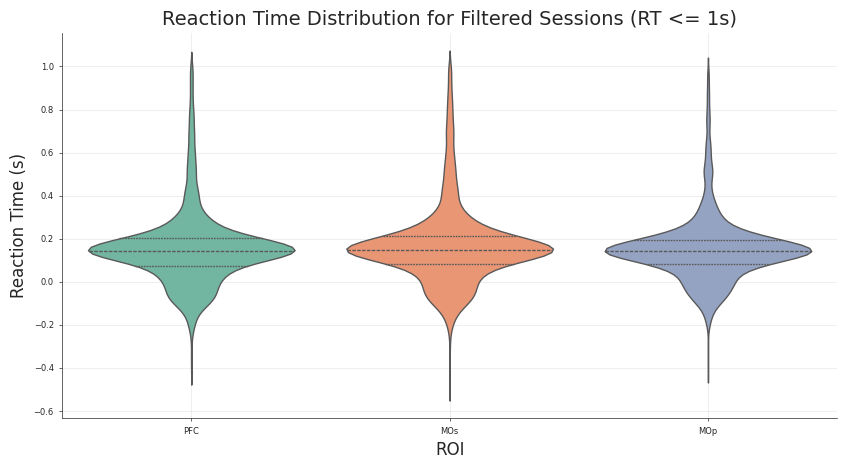

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot RT Distributions for the successfully filtered sessions
df_rt = pd.DataFrame(rt_data_list)
df_rt_filtered = df_rt[df_rt['RT (s)'] <= 1.0]

plt.figure(figsize=(10, 5))
sns.violinplot(data=df_rt_filtered, x='ROI', y='RT (s)', hue='ROI', palette='Set2', inner='quartile', legend=False)
plt.title('Reaction Time Distribution for Filtered Sessions (RT <= 1s)', fontsize=14)
plt.xlabel('ROI', fontsize=12)
plt.ylabel('Reaction Time (s)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()


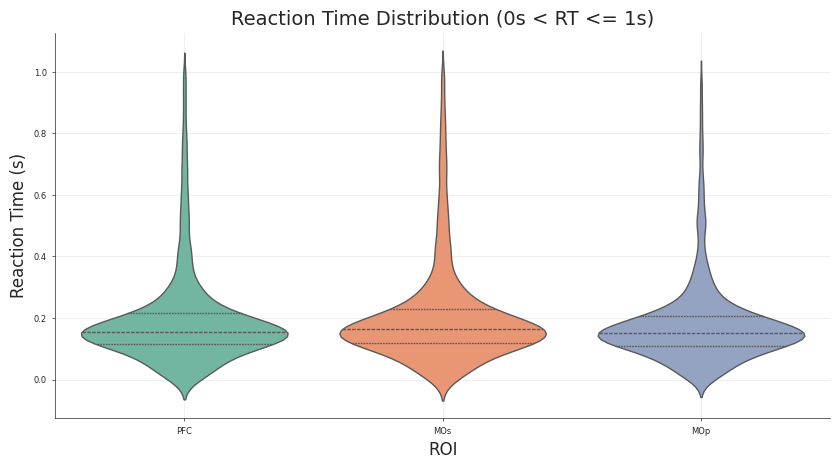

Removed 1275 trials with RT <= 0s. Remaining valid trials: 8327


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 进一步过滤数据：保留 0 < RT <= 1.0 秒的 trials
df_rt_strictly_filtered = df_rt[(df_rt['RT (s)'] > 0) & (df_rt['RT (s)'] <= 1.0)]

# 重新绘制小提琴图
plt.figure(figsize=(10, 5))
sns.violinplot(data=df_rt_strictly_filtered, x='ROI', y='RT (s)', hue='ROI', palette='Set2', inner='quartile', legend=False)
plt.title('Reaction Time Distribution (0s < RT <= 1s)', fontsize=14)
plt.xlabel('ROI', fontsize=12)
plt.ylabel('Reaction Time (s)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# 打印被移除的 trial 数量
prev_trials_count = len(df_rt[df_rt['RT (s)'] <= 1.0])
valid_trials_count = len(df_rt_strictly_filtered)
removed_trials = prev_trials_count - valid_trials_count
print(f"Removed {removed_trials} trials with RT <= 0s. Remaining valid trials: {valid_trials_count}")


In [ ]:
# Prepare variables required for downstream analysis
session1_clusters = meta_stimOn.clusters[meta_stimOn.clusters['acronym'].isin(PFC)]
session2_clusters = meta_stimOn.clusters[meta_stimOn.clusters['acronym'].isin(MOs_region)]
session3_clusters = meta_stimOn.clusters[meta_stimOn.clusters['acronym'].isin(MOp_region)]

session1_eids = df_top10_filtered[df_top10_filtered['ROI'] == 'PFC']['Session EID'].values
session2_eids = df_top10_filtered[df_top10_filtered['ROI'] == 'MOs']['Session EID'].values
session3_eids = df_top10_filtered[df_top10_filtered['ROI'] == 'MOp']['Session EID'].values

print(f"Prepared clusters and EIDs for downstream analysis.")


Prepared clusters and EIDs for downstream analysis.


In [ ]:
import pandas as pd

# Filter the RT data to get only the strictly good trials (0 < RT <= 1.0s)
valid_trials_df = pd.DataFrame(rt_data_list)
valid_trials_df = valid_trials_df[(valid_trials_df['RT (s)'] > 0) & (valid_trials_df['RT (s)'] <= 1.0)]

print("=== Summary of ROI Sessions, Units, and Trials ===\n")

for roi in ['PFC', 'MOs', 'MOp']:
    roi_sessions = df_top10_filtered[df_top10_filtered['ROI'] == roi]

    total_units = 0
    total_trials = 0

    print(f"[{roi} ROI]")
    for _, row in roi_sessions.iterrows():
        eid = row['Session EID']
        units = row['Good Units']

        # Count valid trials for this specific session and ROI to avoid duplicates
        trials = len(valid_trials_df[(valid_trials_df['Session EID'] == eid) & (valid_trials_df['ROI'] == roi)])

        total_units += units
        total_trials += trials

        print(f"  - Session {eid[:8]}... : {units} good units, {trials} good trials")

    print(f"  -> {roi} Total: {total_units} good units, {total_trials} good trials\n")


=== Summary of ROI Sessions, Units, and Trials ===

[PFC ROI]
  - Session dd4da095... : 291 good units, 290 good trials
  - Session dfbe628d... : 229 good units, 388 good trials
  - Session 1191f865... : 179 good units, 522 good trials
  - Session d33baf74... : 151 good units, 287 good trials
  - Session f99ac31f... : 142 good units, 293 good trials
  - Session fb70ebf7... : 98 good units, 398 good trials
  - Session 5ec72172... : 87 good units, 578 good trials
  -> PFC Total: 1177 good units, 2756 good trials

[MOs ROI]
  - Session d33baf74... : 72 good units, 287 good trials
  - Session fb70ebf7... : 70 good units, 398 good trials
  - Session ff4187b5... : 69 good units, 435 good trials
  - Session d2918f52... : 54 good units, 482 good trials
  - Session 2e6e179c... : 50 good units, 384 good trials
  - Session dfbe628d... : 48 good units, 388 good trials
  - Session ae8787b1... : 44 good units, 427 good trials
  -> MOs Total: 407 good units, 2801 good trials

[MOp ROI]
  - Session 8d

## **Comparasion**

### **StimOn-Latency**

Analyzing filtered sessions to calculate per-session averages for StimOn (Strict RT Filtered)...
- PFC: Found 1177 units across 7 sessions.


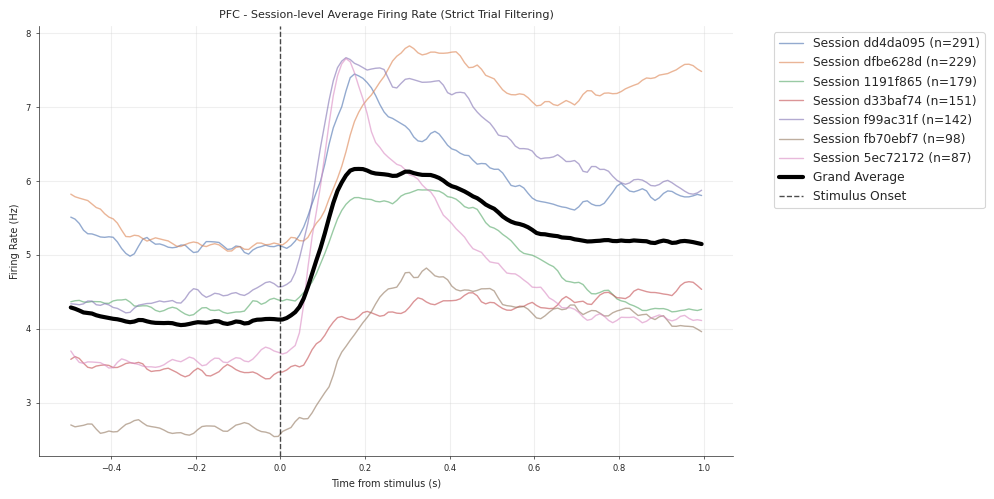

- MOs: Found 407 units across 7 sessions.


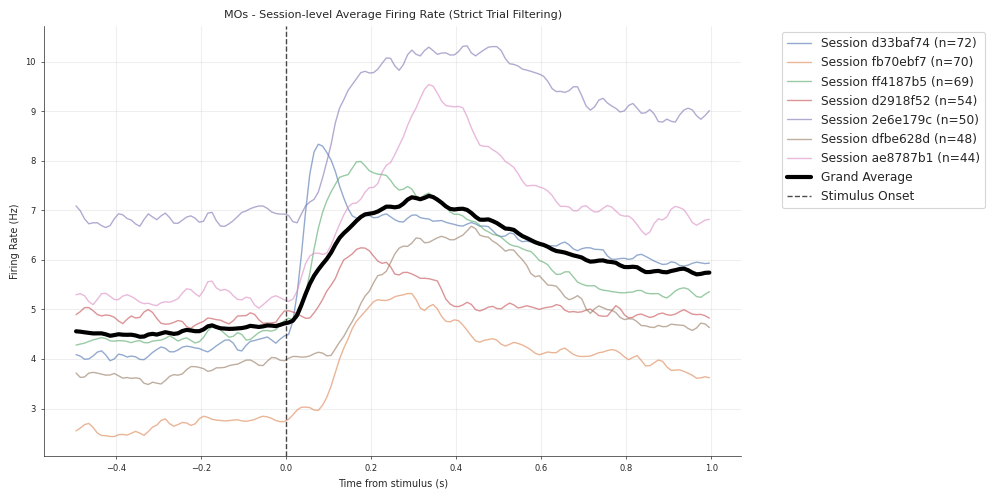

- MOp: Found 723 units across 7 sessions.


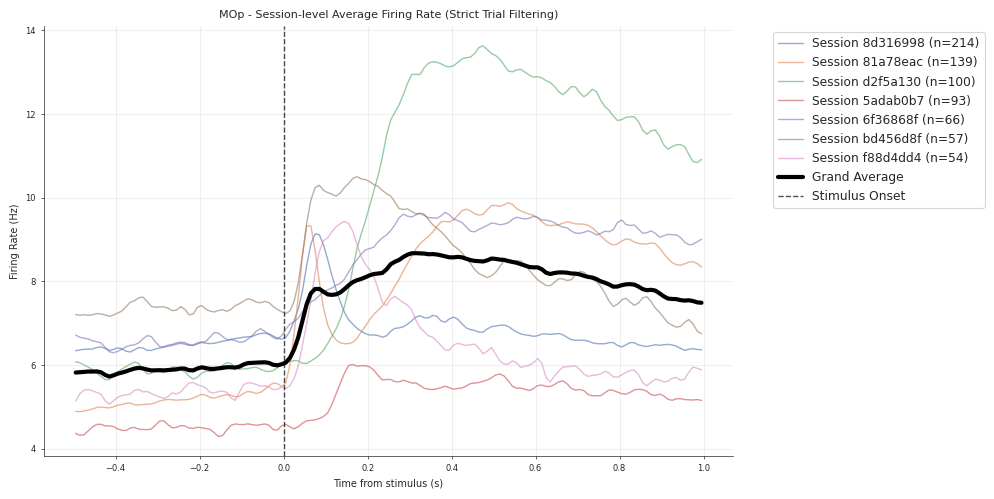

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.ndimage import gaussian_filter1d
import scipy.stats as stats

# 1. Setup metadata and ROI definitions
meta_stim = load_metadata('stimOn')
roi_defs = {
    'PFC': PFC,
    'MOs': MOs_region,
    'MOp': MOp_region
}

print("Analyzing filtered sessions to calculate per-session averages for StimOn (Strict RT Filtered)...")

for roi_name, acronyms in roi_defs.items():
    fig, ax = plt.subplots(figsize=(10, 5))

    valid_eids = df_top10_filtered[df_top10_filtered['ROI'] == roi_name]['Session EID'].values

    if roi_name == 'PFC':
        valid_pids = session1_clusters['pid'].unique()
    elif roi_name == 'MOs':
        valid_pids = session2_clusters['pid'].unique()
    elif roi_name == 'MOp':
        valid_pids = session3_clusters['pid'].unique()
    else:
        valid_pids = []

    session_psths = []
    total_units = 0

    for eid in valid_eids:
        # 获取行为数据用于严格过滤
        trials_data = one.load_object(eid, 'trials', collection='alf')
        rts = trials_data.get('firstMovement_times', np.array([])) - trials_data.get('stimOn_times', np.array([]))

        pids_in_session = meta_stim.sessions[meta_stim.sessions['eid'] == eid]['pid'].unique()
        session_units_psth = []

        for pid in pids_in_session:
            if pid not in valid_pids:
                continue

            psth_ins, df_ins, trials_df = get_psth_for_insertion(pid, meta_stim, reg=None)
            mask = df_ins['acronym'].isin(acronyms)
            if mask.sum() == 0:
                continue

            session_choices = trials_df['choice'].values

            # 对齐 RT 长度
            if len(rts) >= len(session_choices):
                session_rts = rts[:len(session_choices)]
            else:
                session_rts = np.pad(rts, (0, len(session_choices) - len(rts)), constant_values=np.nan)

            # 严格过滤逻辑：0 < RT <= 1.0s 且 choice 不为 NaN
            valid_rt_mask = (session_rts > 0) & (session_rts <= 1.0)
            valid_choice_mask = ~np.isnan(session_choices)
            strict_valid_mask = valid_rt_mask & valid_choice_mask

            # 应用过滤掩码，并在 trial 维度(axis=0)求平均
            valid_psth = psth_ins[strict_valid_mask][:, mask.values, :]
            if len(valid_psth) > 0:
                session_units_psth.append(valid_psth.mean(axis=0))

        if session_units_psth:
            session_concat = np.concatenate(session_units_psth, axis=0)
            total_units += session_concat.shape[0]
            session_mean = np.mean(session_concat, axis=0)
            session_psths.append(session_mean)

            session_concat = np.concatenate(session_units_psth, axis=0)
            session_mean = np.mean(session_concat, axis=0)
            smoothed_mean = gaussian_filter1d(session_mean, sigma=1)
            ax.plot(meta_stim['times'], smoothed_mean, alpha=0.6, label=f'Session {eid[:8]} (n={session_concat.shape[0]})')

    if session_psths:
        # Grand average for this ROI
        roi_session_stacked = np.vstack(session_psths)
        grand_mean = np.mean(roi_session_stacked, axis=0)
        smoothed_grand = gaussian_filter1d(grand_mean, sigma=1)
        ax.plot(meta_stim['times'], smoothed_grand, color='black', lw=3, label='Grand Average')
        print(f"- {roi_name}: Found {total_units} units across {len(session_psths)} sessions.")

    ax.axvline(0, color='black', linestyle='--', alpha=0.7, label='Stimulus Onset')
    ax.set_xlabel('Time from stimulus (s)')
    ax.set_ylabel('Firing Rate (Hz)')
    ax.set_title(f'{roi_name} - Session-level Average Firing Rate (Strict Trial Filtering)')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Calculating grand averages for comparison plot (Strict RT Filtered)...


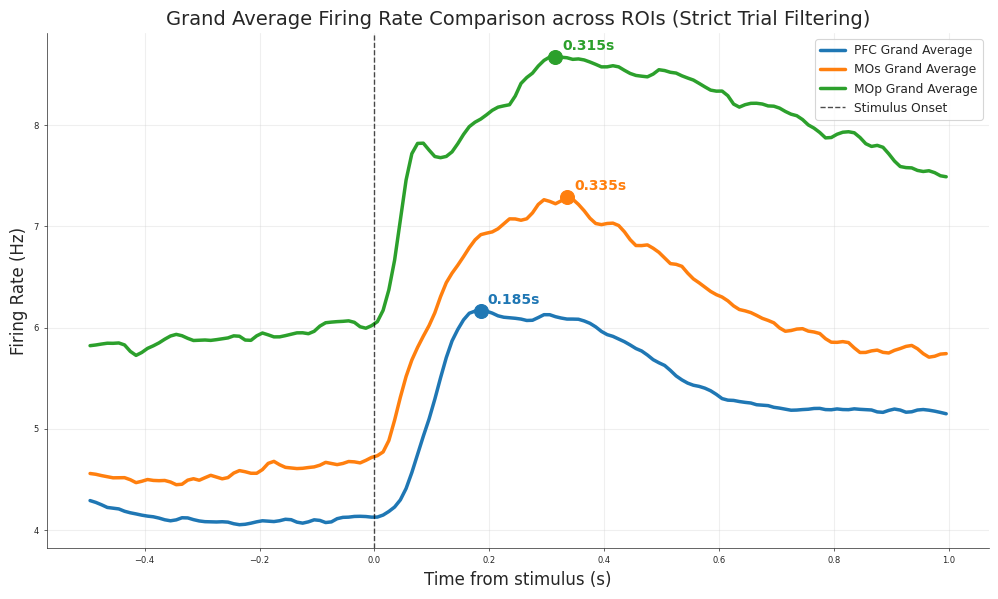

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# 重新获取 meta 数据，确保时间轴正确
meta_stim = load_metadata('stimOn')
time_mask = (meta_stim.times > 0) & (meta_stim.times <= 1.0)
t_vec_post = meta_stim.times[time_mask]

fig, ax = plt.subplots(figsize=(10, 6))
colors = {'PFC': 'tab:blue', 'MOs': 'tab:orange', 'MOp': 'tab:green'}

print("Calculating grand averages for comparison plot (Strict RT Filtered)...")

for roi_name, acronyms in roi_defs.items():
    valid_eids = df_top10_filtered[df_top10_filtered['ROI'] == roi_name]['Session EID'].values

    if roi_name == 'PFC':
        valid_pids = session1_clusters['pid'].unique()
    elif roi_name == 'MOs':
        valid_pids = session2_clusters['pid'].unique()
    elif roi_name == 'MOp':
        valid_pids = session3_clusters['pid'].unique()
    else:
        valid_pids = []

    session_psths = []
    for eid in valid_eids:
        # 获取行为数据用于严格过滤
        trials_data = one.load_object(eid, 'trials', collection='alf')
        rts = trials_data.get('firstMovement_times', np.array([])) - trials_data.get('stimOn_times', np.array([]))

        pids_in_session = meta_stim.sessions[meta_stim.sessions['eid'] == eid]['pid'].unique()
        session_units_psth = []
        for pid in pids_in_session:
            if pid not in valid_pids:
                continue

            psth_ins, df_ins, trials_df = get_psth_for_insertion(pid, meta_stim, reg=None)
            mask = df_ins['acronym'].isin(acronyms)
            if mask.sum() == 0:
                continue

            session_choices = trials_df['choice'].values

            # 对齐 RT 长度
            if len(rts) >= len(session_choices):
                session_rts = rts[:len(session_choices)]
            else:
                session_rts = np.pad(rts, (0, len(session_choices) - len(rts)), constant_values=np.nan)

            # 严格过滤逻辑：0 < RT <= 1.0s 且 choice 不为 NaN
            valid_rt_mask = (session_rts > 0) & (session_rts <= 1.0)
            valid_choice_mask = ~np.isnan(session_choices)
            strict_valid_mask = valid_rt_mask & valid_choice_mask

            # 应用过滤掩码，并在 trial 维度(axis=0)求平均
            valid_psth = psth_ins[strict_valid_mask][:, mask.values, :]
            if len(valid_psth) > 0:
                session_units_psth.append(valid_psth.mean(axis=0))

        if session_units_psth:
            session_concat = np.concatenate(session_units_psth, axis=0)
            session_psths.append(np.mean(session_concat, axis=0))

    if session_psths:
        # 计算 Grand Average 并平滑
        roi_session_stacked = np.vstack(session_psths)
        grand_mean = np.mean(roi_session_stacked, axis=0)
        smoothed_grand = gaussian_filter1d(grand_mean, sigma=1)

        # 绘制曲线
        c = colors[roi_name]
        ax.plot(meta_stim['times'], smoothed_grand, label=f'{roi_name} Grand Average', color=c, lw=2.5)

        # 寻找刺激后的峰值并标注
        peak_idx_post = np.argmax(smoothed_grand[time_mask])
        peak_time = t_vec_post[peak_idx_post]
        peak_val = smoothed_grand[time_mask][peak_idx_post]

        ax.scatter(peak_time, peak_val, color=c, s=100, zorder=5)
        ax.annotate(f'{peak_time:.3f}s', (peak_time, peak_val),
                    xytext=(5, 5), textcoords='offset points',
                    color=c, weight='bold', fontsize=10)

ax.axvline(0, color='black', linestyle='--', alpha=0.7, label='Stimulus Onset')
ax.set_xlabel('Time from stimulus (s)', fontsize=12)
ax.set_ylabel('Firing Rate (Hz)', fontsize=12)
ax.set_title('Grand Average Firing Rate Comparison across ROIs (Strict Trial Filtering)', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### **PCA-stimOn**
This section visualizes the 2D neural state-space trajectories for each ROI. The trajectories are calculated using PCA on trial-averaged PSTHs (pre-movement window) from sessions with high cluster counts.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.decomposition import PCA
import plotly.io as pio
pio.renderers.default = 'colab'

# 1. 定义分析的区域和时间窗 (-0.5s 到 1.0s)
regions = {'PFC': PFC, 'MOs': MOs_region, 'MOp': MOp_region}
time_mask = (meta_stimOn.times >= -0.5) & (meta_stimOn.times <= 1.0)
t_vec = meta_stimOn.times[time_mask]

# 2. 设置绘图布局 (1行3列的3D子图)
fig_3d = make_subplots(
    rows=1, cols=3,
    specs=[[{'type': 'scene'}, {'type': 'scene'}, {'type': 'scene'}]],
    subplot_titles=list(regions.keys())
)

for i, (roi_name, acronyms) in enumerate(regions.items()):
    valid_eids = df_top10_filtered[df_top10_filtered['ROI'] == roi_name]['Session EID'].values
    col = i + 1
    all_psths = {1.0: [], -1.0: []}

    for eid in valid_eids:
        # 获取行为数据用于严格过滤
        trials_data = one.load_object(eid, 'trials', collection='alf')
        rts = trials_data.get('firstMovement_times', np.array([])) - trials_data.get('stimOn_times', np.array([]))

        pids = meta_stimOn.sessions[meta_stimOn.sessions['eid'] == eid]['pid'].unique()
        for pid in pids:
            psth, clust_df, trials_df = get_psth_for_insertion(pid, meta_stimOn)

            in_roi = clust_df['acronym'].isin(acronyms)
            if not in_roi.any():
                continue

            session_choices = trials_df['choice'].values

            # 对齐 RT 长度
            if len(rts) >= len(session_choices):
                session_rts = rts[:len(session_choices)]
            else:
                session_rts = np.pad(rts, (0, len(session_choices) - len(rts)), constant_values=np.nan)

            # 严格过滤逻辑：0 < RT <= 1.0s 且 choice 不为 NaN
            valid_rt_mask = (session_rts > 0) & (session_rts <= 1.0)
            valid_choice_mask = ~np.isnan(session_choices)
            strict_valid_mask = valid_rt_mask & valid_choice_mask

            # 分别提取左右选择的有效试次
            idx_right = strict_valid_mask & (session_choices == 1.0)
            idx_left = strict_valid_mask & (session_choices == -1.0)

            if idx_right.sum() > 0:
                all_psths[1.0].append(psth[idx_right][:, in_roi.values, :].mean(axis=0))
            if idx_left.sum() > 0:
                all_psths[-1.0].append(psth[idx_left][:, in_roi.values, :].mean(axis=0))

    if not all_psths[1.0] or not all_psths[-1.0]:
        print(f"Insufficient data for {roi_name}")
        continue

    # 合并神经元
    psth_right = np.concatenate(all_psths[1.0], axis=0)
    psth_left = np.concatenate(all_psths[-1.0], axis=0)

    # 准备 PCA 输入: 拼接左右轨迹的时间点 (Neurons, Time*2)
    X_pca = np.concatenate([psth_right[:, time_mask], psth_left[:, time_mask]], axis=1)

    # 3. 执行 3D PCA
    pca = PCA(n_components=3)
    trajs = pca.fit_transform(X_pca.T).T  # (3, Time*2)
    var_exp = pca.explained_variance_ratio_ * 100

    n_bins = time_mask.sum()
    traj_right_3d = trajs[:, :n_bins]
    traj_left_3d = trajs[:, n_bins:]

    # 4. 绘制轨迹
    fig_3d.add_trace(go.Scatter3d(
        x=traj_left_3d[0, :], y=traj_left_3d[1, :], z=traj_left_3d[2, :],
        mode='lines+markers', marker=dict(size=3, color='blue', opacity=0.7), line=dict(color='blue', width=4),
        name='Left Choice', showlegend=(col==1)
    ), row=1, col=col)

    fig_3d.add_trace(go.Scatter3d(
        x=traj_right_3d[0, :], y=traj_right_3d[1, :], z=traj_right_3d[2, :],
        mode='lines+markers', marker=dict(size=3, color='red', opacity=0.7), line=dict(color='red', width=4),
        name='Right Choice', showlegend=(col==1)
    ), row=1, col=col)

    fig_3d.add_trace(go.Scatter3d(
        x=[traj_left_3d[0, 0]], y=[traj_left_3d[1, 0]], z=[traj_left_3d[2, 0]],
        mode='markers', marker=dict(size=6, color='blue', symbol='diamond'), showlegend=False
    ), row=1, col=col)
    fig_3d.add_trace(go.Scatter3d(
        x=[traj_right_3d[0, 0]], y=[traj_right_3d[1, 0]], z=[traj_right_3d[2, 0]],
        mode='markers', marker=dict(size=6, color='red', symbol='diamond'), showlegend=False
    ), row=1, col=col)

    scene_name = f'scene{col}' if col > 1 else 'scene'
    fig_3d.layout[scene_name].xaxis.title = f'PC1 ({var_exp[0]:.1f}%)'
    fig_3d.layout[scene_name].yaxis.title = f'PC2 ({var_exp[1]:.1f}%)'
    fig_3d.layout[scene_name].zaxis.title = f'PC3 ({var_exp[2]:.1f}%)'

fig_3d.update_layout(
    title_text='3D Neural Trajectories for PFC, MOs, and MOp (-0.5s to 1.0s) [Strict RT Filtered]',
    width=1200, height=500,
    margin=dict(l=0, r=0, b=0, t=50)
)
fig_3d.show()


Calculating Precise 80% threshold crossings for all regions...


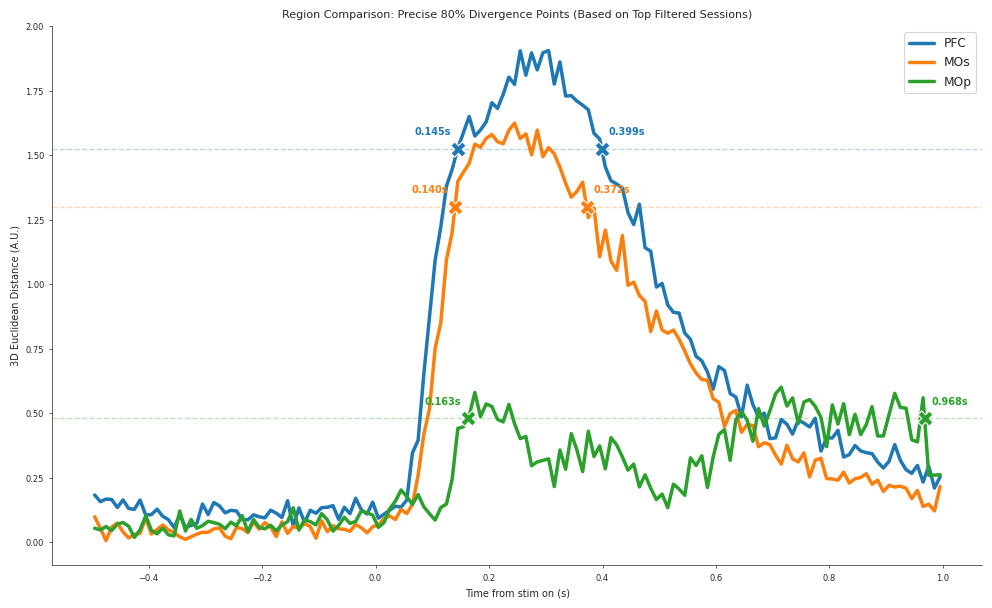

,ROI,Onset,Offset,Peak
0,PFC,0.145,0.399,0.305
1,MOs,0.140,0.372,0.245
2,MOp,0.163,0.968,0.715


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Precise Intersection Function
def find_intersections(t, d, thresh):
    crossings = []
    for i in range(len(d) - 1):
        if (d[i] <= thresh < d[i+1]) or (d[i] >= thresh > d[i+1]):
            t_interp = t[i] + (thresh - d[i]) * (t[i+1] - t[i]) / (d[i+1] - d[i])
            crossings.append(t_interp)
    return crossings

regions = {'PFC': PFC, 'MOs': MOs_region, 'MOp': MOp_region}
time_mask = (meta_stimOn.times >= -0.5) & (meta_stimOn.times <= 1.0)
t_vec = meta_stimOn.times[time_mask]

results = []
dist_data = {}

print("Calculating Precise 80% threshold crossings for all regions...")

for roi_name, acronyms in regions.items():
    # 使用最新过滤好的 session
    valid_eids = df_top10_filtered[df_top10_filtered['ROI'] == roi_name]['Session EID'].values

    all_psths = {1.0: [], -1.0: []}
    for acr in acronyms:
        clusters = meta_stimOn.clusters[meta_stimOn.clusters['acronym'] == acr]
        pids = clusters['pid'].unique()
        for pid in pids:
            eid = meta_stimOn.sessions[meta_stimOn.sessions['pid'] == pid].iloc[0]['eid']
            if eid not in valid_eids: continue
            p_ins, _ = get_avg_psth_for_insertion(pid, meta_stimOn, reg=acr, split='choice')
            if 1.0 in p_ins: all_psths[1.0].append(p_ins[1.0])
            if -1.0 in p_ins: all_psths[-1.0].append(p_ins[-1.0])

    if not all_psths[1.0] or not all_psths[-1.0]: continue

    psth_right = np.concatenate(all_psths[1.0], axis=0)
    psth_left = np.concatenate(all_psths[-1.0], axis=0)
    X_win = np.concatenate([psth_right[:, time_mask], psth_left[:, time_mask]], axis=1)

    pca = PCA(n_components=3)
    trajs = pca.fit_transform(X_win.T).T
    n_bins = time_mask.sum()
    dist_3d = np.sqrt(np.sum((trajs[:, :n_bins] - trajs[:, n_bins:])**2, axis=0))

    max_idx = np.argmax(dist_3d)
    threshold = np.max(dist_3d) * 0.8

    # Precise Crossing Calculation
    crossings = find_intersections(t_vec, dist_3d, threshold)
    t_start = crossings[0] if crossings else np.nan
    t_end = crossings[-1] if len(crossings) > 1 else np.nan

    dist_data[roi_name] = (dist_3d, threshold, t_start, t_end)
    results.append({'ROI': roi_name, 'Onset': np.round(t_start, 3), 'Offset': np.round(t_end, 3), 'Peak': np.round(t_vec[max_idx], 3)})

fig, ax = plt.subplots(figsize=(12, 7))
colors = {'PFC': 'tab:blue', 'MOs': 'tab:orange', 'MOp': 'tab:green'}

for roi_name, (dist, thresh, ts, te) in dist_data.items():
    c = colors[roi_name]
    ax.plot(t_vec, dist, label=roi_name, color=c, lw=2.5)
    ax.axhline(thresh, color=c, ls='--', alpha=0.3)
    if not np.isnan(ts):
        ax.scatter([ts, te], [thresh, thresh], color=c, s=120, marker='X', edgecolors='white', zorder=10)
        ax.annotate(f'{ts:.3f}s', (ts, thresh), xytext=(-5, 10), textcoords='offset points', color=c, weight='bold', ha='right')
        ax.annotate(f'{te:.3f}s', (te, thresh), xytext=(5, 10), textcoords='offset points', color=c, weight='bold', ha='left')

ax.set_title('Region Comparison: Precise 80% Divergence Points (Based on Top Filtered Sessions)')
ax.set_xlabel('Time from stim on (s)')
ax.set_ylabel('3D Euclidean Distance (A.U.)')
ax.legend()
plt.show()
display(pd.DataFrame(results))


### **Sliding Window Decoding Analysis**
In this section, we implement a sliding window decoder to track how choice-related information emerges across the cortical hierarchy (PFC, MOs, MOp). This helps us identify the temporal lead-lag relationships between these regions.

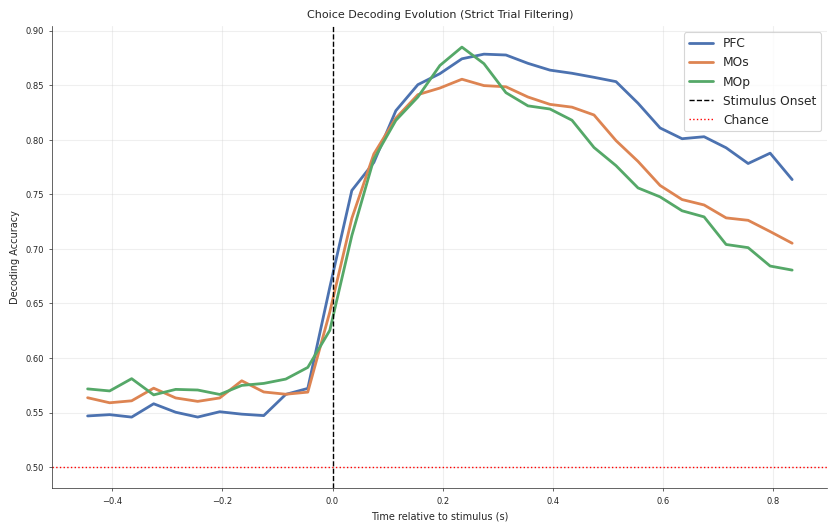

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold

def run_sliding_window_decoding(target_rois, meta, window_size=0.2, step=0.04):
    times = meta.times
    start_times = np.arange(times[0], times[-1] - window_size, step)
    results = {roi: {t: [] for t in start_times} for roi in target_rois}
    scaler = StandardScaler()

    for roi_name, acronyms in target_rois.items():
        valid_eids = df_top10_filtered[df_top10_filtered['ROI'] == roi_name]['Session EID'].values

        for eid in valid_eids:
            trials_data = one.load_object(eid, 'trials', collection='alf')
            rts = trials_data.get('firstMovement_times', np.array([])) - trials_data.get('stimOn_times', np.array([]))

            pids = meta.sessions[meta.sessions['eid'] == eid]['pid'].unique()
            session_X_full = []
            session_y = None

            for pid in pids:
                psth, clust_df, trials_df = get_psth_for_insertion(pid, meta)
                in_roi = clust_df['acronym'].isin(acronyms)
                if not in_roi.any():
                    continue

                session_X_full.append(psth[:, in_roi, :])
                session_y = trials_df['choice'].values

            if not session_X_full or session_y is None:
                continue

            if len(rts) >= len(session_y):
                session_rts = rts[:len(session_y)]
            else:
                session_rts = np.pad(rts, (0, len(session_y) - len(rts)), constant_values=np.nan)

            valid_rt_mask = (session_rts > 0) & (session_rts <= 1.0)
            valid_choice_mask = ~np.isnan(session_y)
            strict_valid_mask = valid_rt_mask & valid_choice_mask

            X_data = np.concatenate(session_X_full, axis=1)
            X_data, y = X_data[strict_valid_mask], session_y[strict_valid_mask]

            if X_data.shape[1] < 5 or len(y) < 40:
                continue

            for t_start in start_times:
                t_end = t_start + window_size
                t_mask = (times >= t_start) & (times <= t_end)
                X_bin = X_data[:, :, t_mask].mean(axis=2)

                kf = KFold(n_splits=5, shuffle=True, random_state=42)
                fold_scores = []
                for train_idx, test_idx in kf.split(X_bin):
                    X_tr, X_te = X_bin[train_idx], X_bin[test_idx]
                    y_tr, y_te = y[train_idx], y[test_idx]

                    X_tr = scaler.fit_transform(X_tr)
                    X_te = scaler.transform(X_te)

                    model = LogisticRegression(max_iter=500, solver='lbfgs')
                    model.fit(X_tr, y_tr)
                    fold_scores.append(model.score(X_te, y_te))

                results[roi_name][t_start].append(np.mean(fold_scores))

    return start_times, results

roi_targets = {'PFC': PFC, 'MOs': MOs_region, 'MOp': MOp_region}
start_times, window_results = run_sliding_window_decoding(roi_targets, meta_stimOn)

plt.figure(figsize=(10, 6))
for roi_name, scores_dict in window_results.items():
    avg_scores = [np.mean(scores_dict[t]) for t in start_times if len(scores_dict[t]) > 0]
    valid_t = [t + 0.05 for t in start_times if len(scores_dict[t]) > 0]
    plt.plot(valid_t, avg_scores, label=roi_name, lw=2)

plt.axvline(0, color='black', linestyle='--', label='Stimulus Onset')
plt.axhline(0.5, color='red', linestyle=':', label='Chance')
plt.xlabel('Time relative to stimulus (s)')
plt.ylabel('Decoding Accuracy')
plt.title('Choice Decoding Evolution (Strict Trial Filtering)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


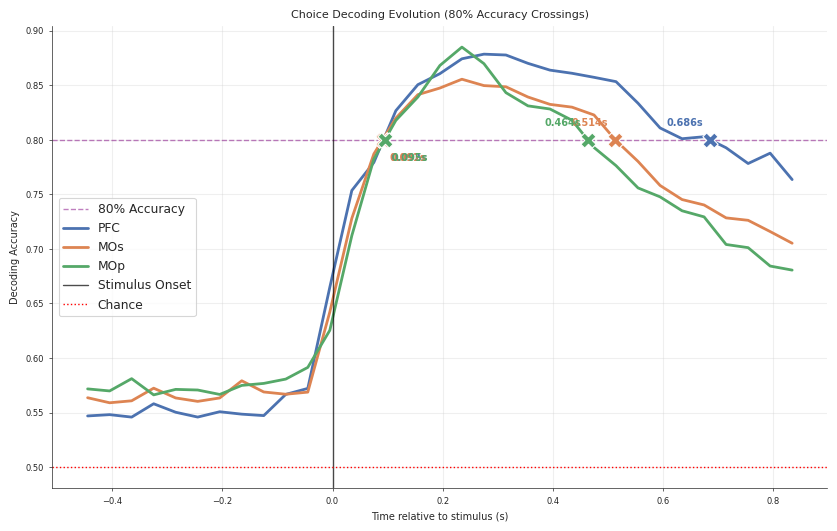

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

if 'window_results' in globals():
    plt.figure(figsize=(10, 6))

    # Target threshold
    threshold = 0.80

    # Plot horizontal line for 80% accuracy
    plt.axhline(threshold, color='purple', linestyle='--', alpha=0.5, label=f'{threshold*100:.0f}% Accuracy')

    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

    for i, (roi_name, scores_dict) in enumerate(window_results.items()):
        avg_scores = [np.mean(scores_dict[t]) for t in start_times if len(scores_dict[t]) > 0]
        valid_t = [t + 0.05 for t in start_times if len(scores_dict[t]) > 0]

        if len(avg_scores) > 0:
            color = colors[i % len(colors)]
            plt.plot(valid_t, avg_scores, label=roi_name, lw=2, color=color)

            # Find all crossing points
            avg_scores = np.array(avg_scores)
            valid_t = np.array(valid_t)

            crossings = []
            for j in range(len(avg_scores) - 1):
                # Check if the line segment crosses the threshold
                if (avg_scores[j] <= threshold < avg_scores[j+1]) or (avg_scores[j] >= threshold > avg_scores[j+1]):
                    x1, y1 = valid_t[j], avg_scores[j]
                    x2, y2 = valid_t[j+1], avg_scores[j+1]
                    t_cross = x1 + (threshold - y1) * (x2 - x1) / (y2 - y1)
                    crossings.append(t_cross)

            for k, t_cross in enumerate(crossings):
                plt.scatter([t_cross], [threshold], color=color, s=120, zorder=5, edgecolors='white', marker='X')
                # Adjust text position based on whether it's an onset or offset crossing
                xytext = (5, -15) if k % 2 == 0 else (-5, 10)
                ha = 'left' if k % 2 == 0 else 'right'
                plt.annotate(f'{t_cross:.3f}s', (t_cross, threshold),
                             xytext=xytext, textcoords='offset points',
                             color=color, weight='bold', ha=ha)

    plt.axvline(0, color='black', linestyle='-', alpha=0.7, label='Stimulus Onset')
    plt.axhline(0.5, color='red', linestyle=':', label='Chance')
    plt.xlabel('Time relative to stimulus (s)')
    plt.ylabel('Decoding Accuracy')
    plt.title('Choice Decoding Evolution (80% Accuracy Crossings)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("Error: 'window_results' not found. Please run the sliding window decoding cell first.")

# **SPARKS**

## **pip**

In [ ]:
print("Python Version:")
!python --version

print("\nPyTorch Version (if installed):")
!pip show torch

Python Version:
Python 3.12.13

PyTorch Version (if installed):
Name: torch
Version: 2.11.0+cu128
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org
Author: 
Author-email: PyTorch Team <packages@pytorch.org>
License: BSD-3-Clause
Location: /usr/local/lib/python3.12/dist-packages
Requires: cuda-bindings, cuda-toolkit, filelock, fsspec, jinja2, networkx, nvidia-cudnn-cu12, nvidia-cusparselt-cu12, nvidia-nccl-cu12, nvidia-nvshmem-cu12, setuptools, sympy, triton, typing-extensions
Required-by: accelerate, fastai, peft, sentence-transformers, timm, torchdata, torchvision


In [ ]:
!pip install sparks-ai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 77.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.3/362.3 kB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 13.6 MB/s eta 0:00:00


# **Multisession**

In [ ]:
import torch
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sparks.models.sparks import SPARKS
from sparks.models.dataclasses import HebbianAttentionConfig, AttentionConfig

# === 0. Setup SPARKS Hyperparameters & Device ===
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
latent_dim = 64
embed_dim = 128
tau_p = 40
tau_f = 1
hebbian_config = HebbianAttentionConfig(tau_s=1.0, dt=meta_stimOn.dt)
attention_config = AttentionConfig(n_heads=8)

# 1. 获取目标 Sessions (PFC, 从按照 RT 筛选的 session 中获取)
target_roi = 'PFC'
roi_sessions = df_top10_filtered[df_top10_filtered['ROI'] == target_roi]
target_eids = roi_sessions['Session EID'].tolist()

print(f"Target EIDs for Multi-session Learning ({target_roi}): {target_eids}")

# 2. 提取数据
rois = {target_roi: PFC}
time_mask = (meta_stimOn.times >= -0.5) & (meta_stimOn.times <= 1.0)

multi_dl_dict = {}  # 存储每个 session 的 dataloaders 和 n_neurons
batch_size = 128

print("\n=== Multisession Dataloader Trial Counts ===")
for sess_id, eid in enumerate(target_eids):
    pids = meta_stimOn.sessions[meta_stimOn.sessions['eid'] == eid]['pid'].unique()
    session_psths = []
    session_choices = None

    for pid in pids:
        psth, clust_df, trials_df = get_psth_for_insertion(pid, meta_stimOn)
        in_roi = clust_df['acronym'].isin(PFC)
        if not in_roi.any():
            continue

        session_psths.append(psth[:, in_roi.values, :][:, :, time_mask])
        if session_choices is None:
            session_choices = trials_df['choice'].values

    if session_psths:
        X_full = np.concatenate(session_psths, axis=1)

        # 剔除 choice 为 NaN 的 trials
        valid_choice_mask = ~np.isnan(session_choices)

        # 从 ONE API 获取行为数据以正确计算 RT
        try:
            trials_data = one.load_object(eid, 'trials', collection='alf')
            rts = trials_data.get('firstMovement_times', np.array([])) - trials_data.get('stimOn_times', np.array([]))

            # 确保 rts 长度与 session_choices 一致
            if len(rts) >= len(session_choices):
                rts = rts[:len(session_choices)]
            else:
                rts = np.pad(rts, (0, len(session_choices) - len(rts)), constant_values=np.nan)

            valid_rt_mask = (rts > 0) & (rts <= 1.0)
        except Exception as e:
            print(f"Warning: Failed to load trials from ONE for {eid}: {e}")
            valid_rt_mask = np.ones(len(session_choices), dtype=bool)

        valid_trials = valid_choice_mask & valid_rt_mask

        X_valid = X_full[valid_trials]
        y_valid = session_choices[valid_trials]

        if X_valid.shape[1] > 0:
            # Log1p 处理
            X_norm = np.log1p(X_valid)

            X_tensor = torch.tensor(X_norm, dtype=torch.float32)
            y_tensor = torch.tensor(y_valid, dtype=torch.float32)

            dataset = TensorDataset(X_tensor, y_tensor)

            train_size = int(0.8 * len(dataset))
            test_size = len(dataset) - train_size
            generator = torch.Generator().manual_seed(42)
            train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size], generator=generator)

            train_dl = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
            test_dl = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

            multi_dl_dict[sess_id] = {
                'train': train_dl,
                'test': test_dl,
                'n_neurons': X_valid.shape[1],
                'eid': eid
            }
            print(f"Session {sess_id} (EID: {eid[:8]}...) - Neurons: {X_valid.shape[1]}, Total Valid Trials: {len(dataset)} (Train: {train_size}, Test: {test_size})")
        else:
            print(f"Session {sess_id} has 0 valid neurons.")
    else:
        print(f"Session {sess_id} has no valid clusters.")


# 3. 初始化多 Session SPARKS 模型
if not multi_dl_dict:
    print("No valid data extracted. Aborting model initialization.")
else:
    # 提取所有 session 的输入/输出大小
    valid_sess_ids = list(multi_dl_dict.keys())
    input_sizes = [multi_dl_dict[sid]['n_neurons'] for sid in valid_sess_ids]

    print(f"\nInitializing SPARKS with input sizes: {input_sizes}")

    multi_model = SPARKS(
        n_neurons_per_session=input_sizes,
        embed_dim=embed_dim,
        latent_dim=latent_dim,
        tau_p=tau_p,
        tau_f=tau_f,
        hebbian_config=hebbian_config,
        attention_config=attention_config,
        output_dim_per_session=input_sizes,
        joint_decoder=False,
        device=device
    )

    # 为多 session 设置优化器
    lr = 1e-3
    beta = 1e-6
    multi_optimizer = torch.optim.Adam(multi_model.parameters(), lr=lr)
    loss_fn = torch.nn.MSELoss()

    print("Multi-session SPARKS model initialized successfully.")


Target EIDs for Multi-session Learning (PFC): ['dd4da095-4a99-4bf3-9727-f735077dba66', 'dfbe628d-365b-461c-a07f-8b9911ba83aa', '1191f865-b10a-45c8-9c48-24a980fd9402', 'd33baf74-263c-4b37-a0d0-b79dcb80a764', 'f99ac31f-171b-4208-a55d-5644c0ad51c3', 'fb70ebf7-8175-42b0-9b7a-7c6e8612226e', '5ec72172-3901-4771-8777-6e9490ca51fc']

=== Multisession Dataloader Trial Counts ===
Session 0 (EID: dd4da095...) - Neurons: 291, Total Valid Trials: 290 (Train: 232, Test: 58)
Session 1 (EID: dfbe628d...) - Neurons: 229, Total Valid Trials: 388 (Train: 310, Test: 78)
Session 2 (EID: 1191f865...) - Neurons: 179, Total Valid Trials: 522 (Train: 417, Test: 105)
Session 3 (EID: d33baf74...) - Neurons: 151, Total Valid Trials: 287 (Train: 229, Test: 58)
Session 4 (EID: f99ac31f...) - Neurons: 142, Total Valid Trials: 293 (Train: 234, Test: 59)
Session 5 (EID: fb70ebf7...) - Neurons: 98, Total Valid Trials: 398 (Train: 318, Test: 80)
Session 6 (EID: 5ec72172...) - Neurons: 87, Total Valid Trials: 578 (Train:

In [ ]:
import torch.nn.utils as nn_utils
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Set up a scheduler for the multi-session optimizer
multi_scheduler = ReduceLROnPlateau(multi_optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-5)

n_epochs = 300
test_period = 1
patience = 8
min_delta = 1e-4

best_loss = float('inf')
patience_counter = 0

# --- NEW: Track both global and per-session losses ---
train_losses_global = []
test_losses_global = []

sess_ids = list(multi_dl_dict.keys())
train_losses_per_sess = {sid: [] for sid in sess_ids}
test_losses_per_sess = {sid: [] for sid in sess_ids}

print("\n--- Starting Multi-Session Training ---")

for epoch in range(n_epochs):
    # --- Training Phase ---
    multi_model.train()
    epoch_train_loss_global = 0.0
    num_batches_global = 0

    # Iterate through each session sequentially
    for sid in sess_ids:
        train_dl = multi_dl_dict[sid]['train']
        sess_train_loss = 0.0
        sess_num_batches = 0

        for inputs, _ in train_dl:
            inputs = inputs.float().to(device)
            inputs = torch.nan_to_num(inputs, nan=0.0)

            T = inputs.shape[-1]
            multi_model.encoder.zero_()  # Reset trace

            encoder_outputs = torch.zeros([len(inputs), latent_dim, tau_p]).to(device)
            loss = 0

            for t in range(T - tau_f + 1):
                # Pass the input along with its corresponding session_id
                encoder_outputs, decoder_outputs, mu, logvar = multi_model(
                    inputs[..., t],
                    encoder_outputs=encoder_outputs,
                    session_id=sid
                )

                logvar = torch.clamp(logvar, min=-20, max=20)

                target = inputs[..., t:t + tau_f].reshape(inputs.shape[0], -1).to(device)
                recon_loss = loss_fn(decoder_outputs, target)
                kdl_loss = - 0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
                loss += recon_loss + beta * kdl_loss

            loss = loss / (T - tau_f + 1)

            multi_optimizer.zero_grad()
            loss.backward()
            nn_utils.clip_grad_norm_(multi_model.parameters(), max_norm=1.0)
            multi_optimizer.step()

            sess_train_loss += loss.item()
            sess_num_batches += 1

        # Record per-session train loss
        train_losses_per_sess[sid].append(sess_train_loss / sess_num_batches)
        epoch_train_loss_global += sess_train_loss
        num_batches_global += sess_num_batches

    avg_train_loss = epoch_train_loss_global / num_batches_global

    # --- Testing Phase ---
    if (epoch + 1) % test_period == 0:
        multi_model.eval()
        epoch_test_loss_global = 0.0
        num_test_batches_global = 0

        with torch.no_grad():
            for sid in sess_ids:
                test_dl = multi_dl_dict[sid]['test']
                sess_test_loss = 0.0
                sess_num_test_batches = 0

                for inputs, _ in test_dl:
                    inputs = inputs.float().to(device)
                    inputs = torch.nan_to_num(inputs, nan=0.0)
                    T = inputs.shape[-1]
                    multi_model.encoder.zero_()

                    encoder_outputs = torch.zeros([len(inputs), latent_dim, tau_p]).to(device)
                    loss = 0

                    for t in range(T - tau_f + 1):
                        encoder_outputs, decoder_outputs, mu, logvar = multi_model(
                            inputs[..., t],
                            encoder_outputs=encoder_outputs,
                            session_id=sid
                        )

                        logvar = torch.clamp(logvar, min=-20, max=20)

                        target = inputs[..., t:t + tau_f].reshape(inputs.shape[0], -1).to(device)
                        recon_loss = loss_fn(decoder_outputs, target)
                        kdl_loss = - 0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
                        loss += recon_loss + beta * kdl_loss

                    loss = loss / (T - tau_f + 1)
                    sess_test_loss += loss.item()
                    sess_num_test_batches += 1

                # Record per-session test loss
                test_losses_per_sess[sid].append(sess_test_loss / sess_num_test_batches)
                epoch_test_loss_global += sess_test_loss
                num_test_batches_global += sess_num_test_batches

        avg_test_loss = epoch_test_loss_global / num_test_batches_global

        # Step the scheduler
        multi_scheduler.step(avg_test_loss)

        train_losses_global.append(avg_train_loss)
        test_losses_global.append(avg_test_loss)

        current_lr = multi_optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch + 1}/{n_epochs} | Global Test Loss: {avg_test_loss:.4f} | Global Train Loss: {avg_train_loss:.4f} | LR: {current_lr:.1e}")

        # Early Stopping Logic based on global convergence
        if avg_test_loss < best_loss - min_delta:
            best_loss = avg_test_loss
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Convergence reached! Early stopping at epoch {epoch + 1} with best Global Test Loss: {best_loss:.4f}")
            break


--- Starting Multi-Session Training ---
Epoch 1/300 | Global Test Loss: 0.4154 | Global Train Loss: 0.3144 | LR: 6.3e-05
Epoch 2/300 | Global Test Loss: 0.4160 | Global Train Loss: 0.3152 | LR: 6.3e-05
Epoch 3/300 | Global Test Loss: 0.4131 | Global Train Loss: 0.3146 | LR: 6.3e-05
Epoch 4/300 | Global Test Loss: 0.4136 | Global Train Loss: 0.3142 | LR: 6.3e-05
Epoch 5/300 | Global Test Loss: 0.4116 | Global Train Loss: 0.3125 | LR: 6.3e-05
Epoch 6/300 | Global Test Loss: 0.4124 | Global Train Loss: 0.3123 | LR: 6.3e-05
Epoch 7/300 | Global Test Loss: 0.4111 | Global Train Loss: 0.3109 | LR: 6.3e-05
Epoch 8/300 | Global Test Loss: 0.4124 | Global Train Loss: 0.3110 | LR: 6.3e-05
Epoch 9/300 | Global Test Loss: 0.4102 | Global Train Loss: 0.3108 | LR: 6.3e-05
Epoch 10/300 | Global Test Loss: 0.4099 | Global Train Loss: 0.3104 | LR: 6.3e-05
Epoch 11/300 | Global Test Loss: 0.4090 | Global Train Loss: 0.3088 | LR: 6.3e-05
Epoch 12/300 | Global Test Loss: 0.4086 | Global Train Loss: 0.308

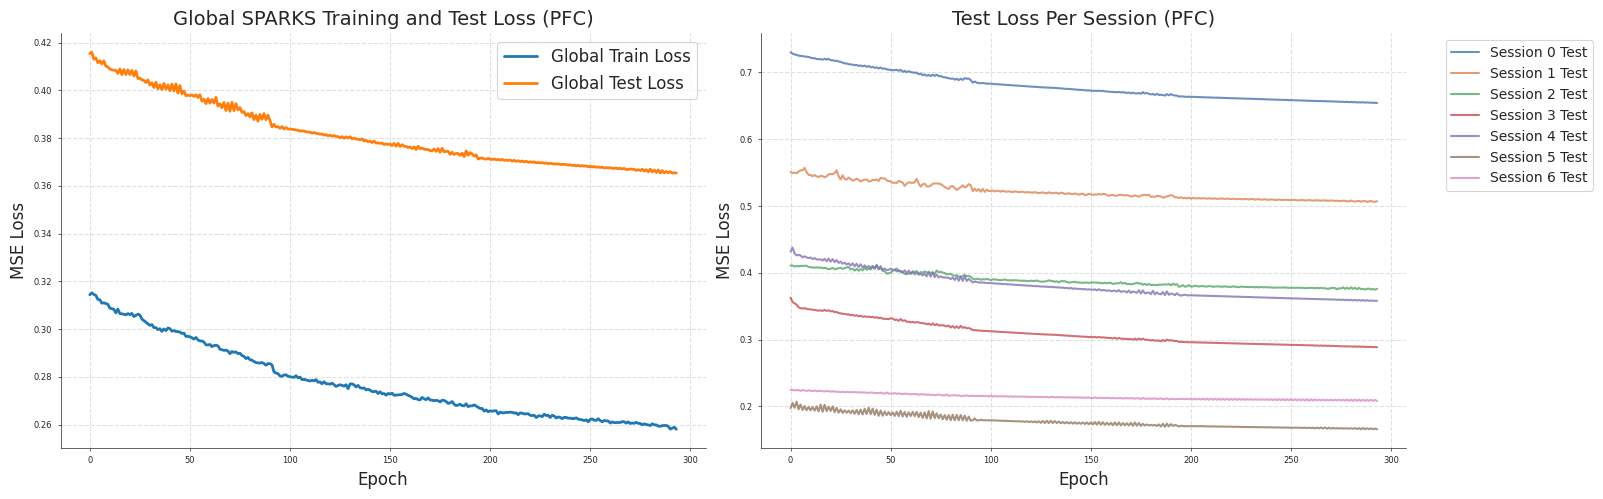

In [ ]:
import matplotlib.pyplot as plt

# Plot the multi-session learning curves
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Global Averaged Loss
axes[0].plot(train_losses_global, label='Global Train Loss', lw=2, color='tab:blue')
axes[0].plot(test_losses_global, label='Global Test Loss', lw=2, color='tab:orange')
axes[0].set_title('Global SPARKS Training and Test Loss (PFC)', fontsize=14)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('MSE Loss', fontsize=12)
axes[0].legend(fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.6)

# 2. Per-Session Test Loss
for sid in sess_ids:
    axes[1].plot(test_losses_per_sess[sid], label=f'Session {sid} Test', lw=1.5, alpha=0.8)

axes[1].set_title('Test Loss Per Session (PFC)', fontsize=14)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('MSE Loss', fontsize=12)
axes[1].legend(fontsize=10, bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

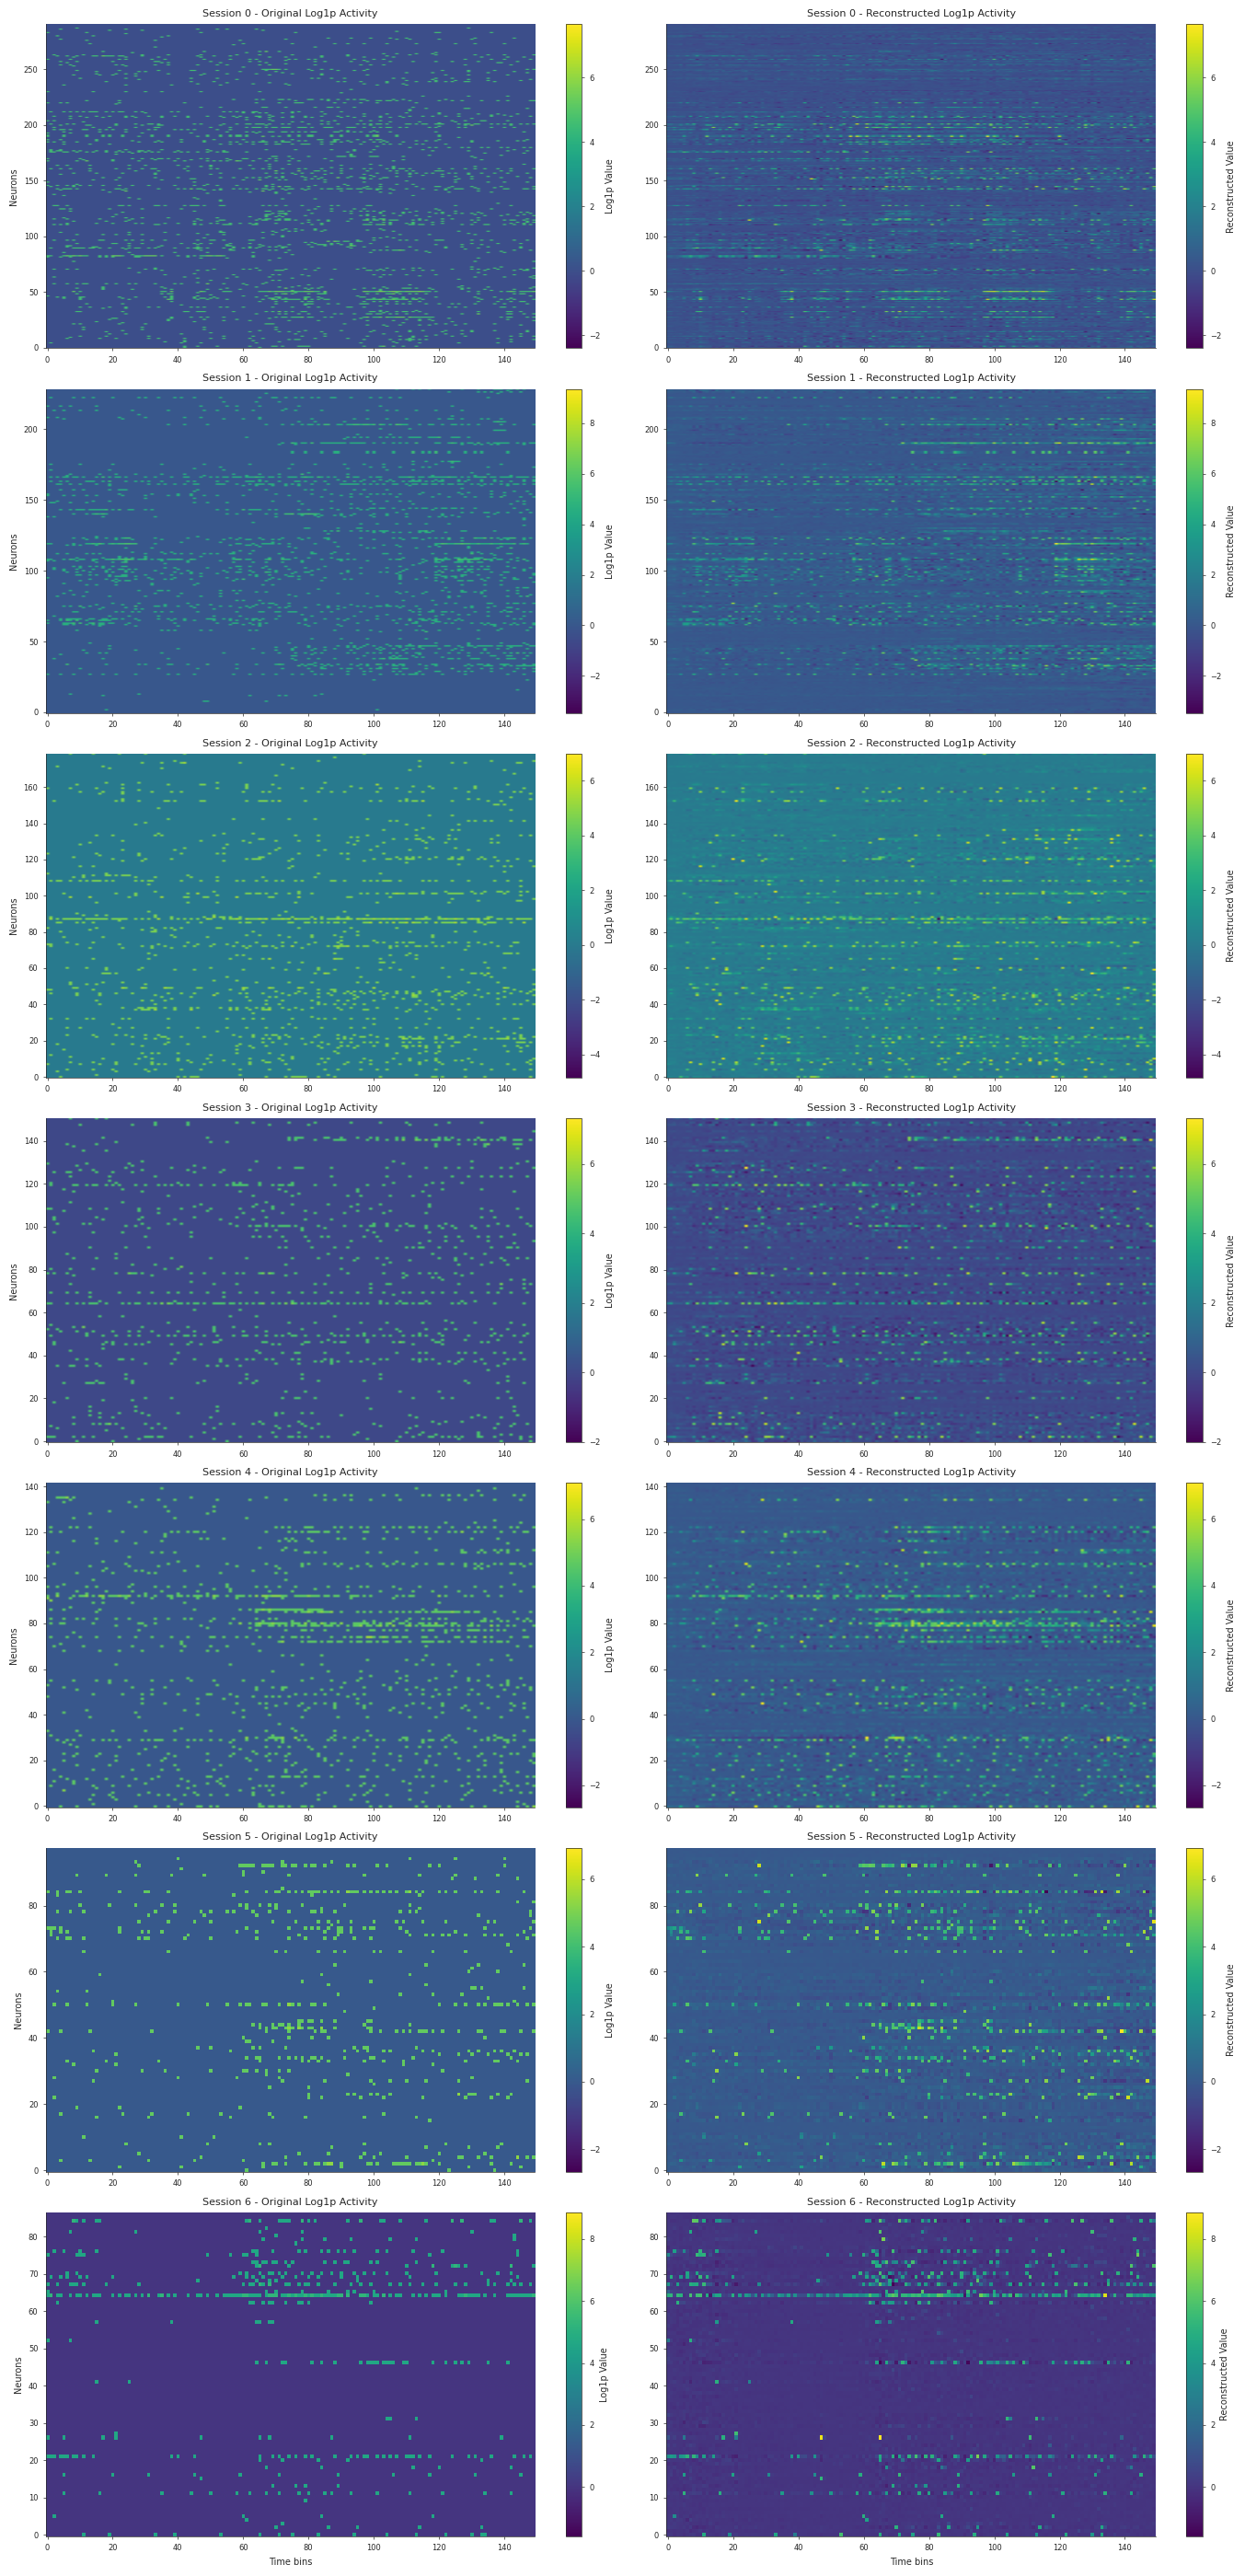

In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np

multi_model.eval()
num_sessions = len(sess_ids)
fig, axes = plt.subplots(num_sessions, 2, figsize=(14, 4 * num_sessions))

# Ensure axes is 2D even if there's only 1 session
if num_sessions == 1:
    axes = np.expand_dims(axes, axis=0)

trial_idx = 0

with torch.no_grad():
    for idx, sid in enumerate(sess_ids):
        test_dl = multi_dl_dict[sid]['test']
        inputs, _ = next(iter(test_dl))

        # Take only one trial to speed up inference for visualization
        inputs = inputs[trial_idx:trial_idx+1].float().to(device)
        inputs = torch.nan_to_num(inputs, nan=0.0)
        T = inputs.shape[-1]

        multi_model.encoder.zero_()
        encoder_outputs = torch.zeros([1, latent_dim, tau_p]).to(device)

        reconstructions = []
        for t in range(T - tau_f + 1):
            encoder_outputs, decoder_outputs, mu, logvar = multi_model(
                inputs[..., t],
                encoder_outputs=encoder_outputs,
                session_id=sid
            )
            reconstructions.append(decoder_outputs.unsqueeze(-1))

        reconstructions = torch.cat(reconstructions, dim=-1)

        orig_trial = inputs[0].cpu().numpy()
        recon_trial = reconstructions[0].cpu().numpy()

        vmin = min(orig_trial.min(), recon_trial.min())
        vmax = max(orig_trial.max(), recon_trial.max())

        im1 = axes[idx, 0].imshow(orig_trial, aspect='auto', cmap='viridis', origin='lower', vmin=vmin, vmax=vmax)
        axes[idx, 0].set_title(f'Session {sid} - Original Log1p Activity')
        axes[idx, 0].set_ylabel('Neurons')
        if idx == num_sessions - 1:
            axes[idx, 0].set_xlabel('Time bins')
        fig.colorbar(im1, ax=axes[idx, 0], label='Log1p Value')

        im2 = axes[idx, 1].imshow(recon_trial, aspect='auto', cmap='viridis', origin='lower', vmin=vmin, vmax=vmax)
        axes[idx, 1].set_title(f'Session {sid} - Reconstructed Log1p Activity')
        if idx == num_sessions - 1:
            axes[idx, 1].set_xlabel('Time bins')
        fig.colorbar(im2, ax=axes[idx, 1], label='Reconstructed Value')

plt.tight_layout()
plt.show()

## **Result**

In [ ]:
import os
import torch
import pickle

save_dir = 'pfc_multisession_results'
os.makedirs(save_dir, exist_ok=True)

# 1. 保存模型权重 (包含网络参数、潜变量映射矩阵、Hebbian注意力状态等)
torch.save(multi_model.state_dict(), os.path.join(save_dir, 'multi_model_pfc.pth'))
print(f"Model weights saved to {save_dir}/multi_model_pfc.pth")

# 2. 保存提取的潜变量轨迹字典
latent_results = {
    'sess_left_dict': sess_left_dict,
    'sess_right_dict': sess_right_dict,
    'overall_left': overall_left,
    'overall_right': overall_right
}
with open(os.path.join(save_dir, 'latent_trajectories.pkl'), 'wb') as f:
    pickle.dump(latent_results, f)
print(f"Latent trajectories saved to {save_dir}/latent_trajectories.pkl")

# 3. 保存带有行为学信息和发散度指标的分析数据框
if 'combined_df' in globals():
    combined_df.to_csv(os.path.join(save_dir, 'combined_analysis_df.csv'), index=False)
    print(f"Combined analysis DataFrame saved to {save_dir}/combined_analysis_df.csv")

if 'session_stats_df' in globals():
    session_stats_df.to_csv(os.path.join(save_dir, 'session_stats_df.csv'), index=False)
    print(f"Session stats DataFrame saved to {save_dir}/session_stats_df.csv")

print("\nAll requested results have been successfully saved!")

Model weights saved to pfc_multisession_results/multi_model_pfc.pth
Latent trajectories saved to pfc_multisession_results/latent_trajectories.pkl

All requested results have been successfully saved!


In [ ]:
from google.colab import drive
import shutil
import os

# 挂载 Google Drive
drive.mount('/content/drive')

# 设置源文件夹和目标文件夹路径
source_dir = '/content/pfc_multisession_results'
dest_dir = '/content/drive/MyDrive/pfc_multisession_results_backup'

# 将文件夹复制到 Google Drive
if os.path.exists(source_dir):
    shutil.copytree(source_dir, dest_dir, dirs_exist_ok=True)
    print(f"成功将 {source_dir} 备份到 {dest_dir}")
else:
    print(f"找不到源文件夹 {source_dir}，请确保已经运行了之前的保存代码。")

Mounted at /content/drive
成功将 /content/pfc_multisession_results 备份到 /content/drive/MyDrive/pfc_multisession_results_backup


Extracting latent states and running sliding window decoding...


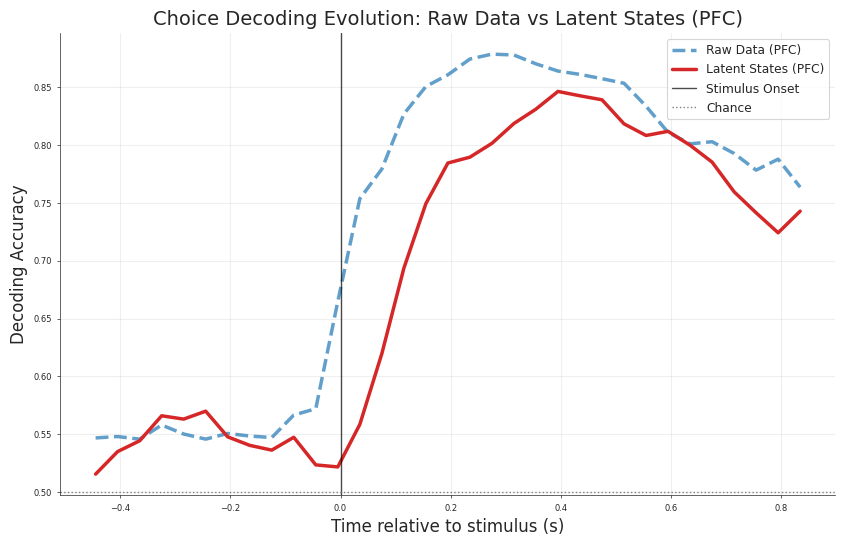

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
import torch

# Parameters for sliding window (same as before)
window_size = 0.2
step = 0.04
times = meta_stimOn.times
start_times = np.arange(times[0], times[-1] - window_size, step)

latent_decoding_results = {t: [] for t in start_times}
scaler = StandardScaler()

print("Extracting latent states and running sliding window decoding...")

multi_model.eval()
with torch.no_grad():
    for sid in sess_ids:
        test_dl = multi_dl_dict[sid]['test']
        latent_states = []
        choices = []

        for inputs, y in test_dl:
            inputs = inputs.float().to(device)
            inputs = torch.nan_to_num(inputs, nan=0.0)
            T = inputs.shape[-1]
            multi_model.encoder.zero_()
            encoder_outputs = torch.zeros([len(inputs), latent_dim, tau_p]).to(device)

            batch_latents = []
            for t in range(T - tau_f + 1):
                encoder_outputs, decoder_outputs, mu, logvar = multi_model(
                    inputs[..., t],
                    encoder_outputs=encoder_outputs,
                    session_id=sid
                )
                batch_latents.append(mu.unsqueeze(-1))

            batch_latents = torch.cat(batch_latents, dim=-1)
            latent_states.append(batch_latents.cpu().numpy())
            choices.append(y.numpy())

        latent_states = np.concatenate(latent_states, axis=0) # (Trials, latent_dim, Time)
        choices = np.concatenate(choices, axis=0)

        # Mask valid trials (not NaN choices)
        valid_mask = ~np.isnan(choices)
        latent_states = latent_states[valid_mask]
        choices = choices[valid_mask]

        if len(choices) < 40:
            continue

        for t_start in start_times:
            t_end = t_start + window_size
            t_mask = (times >= t_start) & (times <= t_end)

            if t_mask.sum() == 0:
                continue

            X_bin = latent_states[:, :, t_mask].mean(axis=2)

            kf = KFold(n_splits=5, shuffle=True, random_state=42)
            fold_scores = []
            for train_idx, test_idx in kf.split(X_bin):
                X_tr, X_te = X_bin[train_idx], X_bin[test_idx]
                y_tr, y_te = choices[train_idx], choices[test_idx]

                X_tr = scaler.fit_transform(X_tr)
                X_te = scaler.transform(X_te)

                model = LogisticRegression(max_iter=500, solver='lbfgs')
                model.fit(X_tr, y_tr)
                fold_scores.append(model.score(X_te, y_te))

            latent_decoding_results[t_start].append(np.mean(fold_scores))

# Calculate average across sessions
avg_latent_scores = [np.mean(latent_decoding_results[t]) for t in start_times if len(latent_decoding_results[t]) > 0]
# Offset by window_size / 2 to align with the center of the window (same as before: t + 0.05 + ... wait, the previous code used t + 0.05, we use the same)
valid_t_latent = [t + 0.05 for t in start_times if len(latent_decoding_results[t]) > 0]

# Extract previous raw data PFC decoding results
if 'window_results' in globals() and 'PFC' in window_results:
    raw_pfc_scores_dict = window_results['PFC']
    avg_raw_scores = [np.mean(raw_pfc_scores_dict[t]) for t in start_times if len(raw_pfc_scores_dict[t]) > 0]
    valid_t_raw = [t + 0.05 for t in start_times if len(raw_pfc_scores_dict[t]) > 0]
else:
    avg_raw_scores = []
    valid_t_raw = []

# Plot
plt.figure(figsize=(10, 6))

if len(avg_raw_scores) > 0:
    plt.plot(valid_t_raw, avg_raw_scores, label='Raw Data (PFC)', lw=2.5, linestyle='--', color='tab:blue', alpha=0.7)

plt.plot(valid_t_latent, avg_latent_scores, label='Latent States (PFC)', lw=2.5, color='tab:red')

plt.axvline(0, color='black', linestyle='-', alpha=0.7, label='Stimulus Onset')
plt.axhline(0.5, color='gray', linestyle=':', label='Chance')

plt.xlabel('Time relative to stimulus (s)', fontsize=12)
plt.ylabel('Decoding Accuracy', fontsize=12)
plt.title('Choice Decoding Evolution: Raw Data vs Latent States (PFC)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Extracting Hebbian attention matrix for Session 2 (PFC)


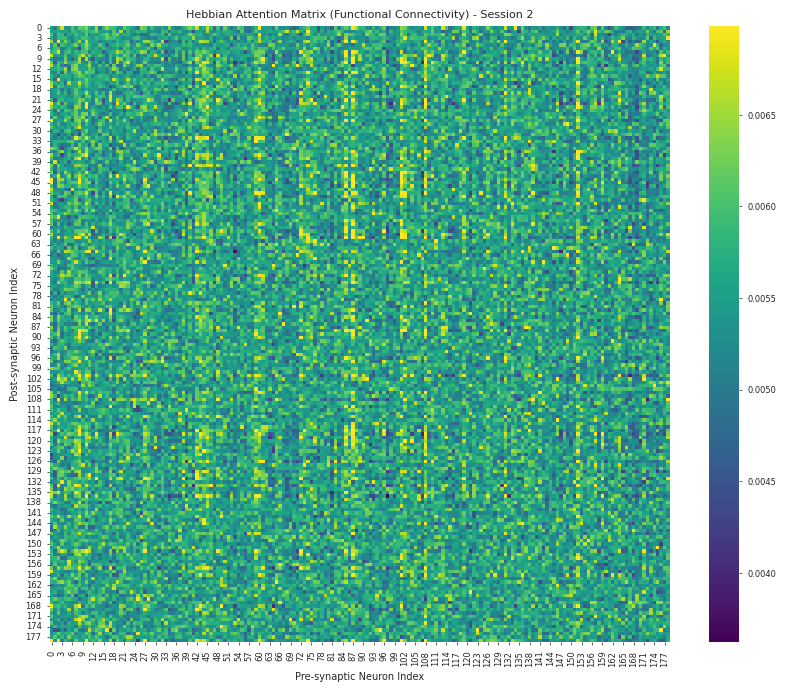

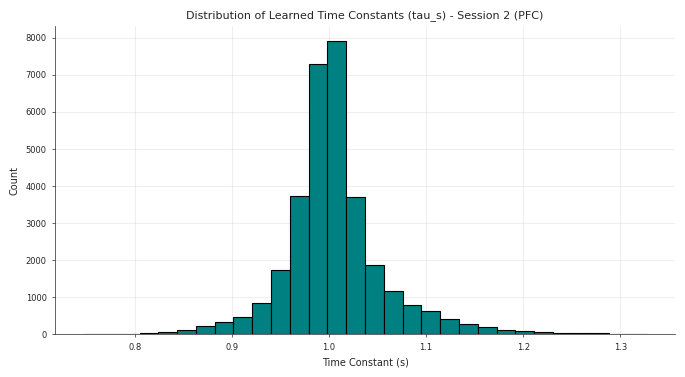

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# Let's look at the Hebbian attention weights for the first session (Session 0)
sid = 2
print(f"Extracting Hebbian attention matrix for Session {sid} (PFC)")

# Get the specific attention head for this session using the correct path
attention_head = multi_model.encoder.hebbian_blocks[str(sid)].attention_layer.heads[0]

# Extract the learned weights (post-synaptic to pre-synaptic functional connections)
# We squeeze to remove the extra batch/head dimension if present
weights = attention_head.latent_post_weight.detach().cpu().squeeze().numpy()

plt.figure(figsize=(10, 8))
# We take the exponential because the weights are learned in log-space
exp_weights = np.exp(weights)

# Normalize them by row to see the relative attention of each post-synaptic neuron
normalized_weights = exp_weights / np.sum(exp_weights, axis=1, keepdims=True)

sns.heatmap(normalized_weights, cmap='viridis', vmax=np.percentile(normalized_weights, 99))
plt.title(f'Hebbian Attention Matrix (Functional Connectivity) - Session {sid}')
plt.xlabel('Pre-synaptic Neuron Index')
plt.ylabel('Post-synaptic Neuron Index')
plt.show()

# We can also look at the learned time constants (tau_s)
tau = attention_head.latent_post_tau_s.detach().cpu().exp().numpy().flatten()
plt.figure(figsize=(8, 4))
plt.hist(tau, bins=30, color='teal', edgecolor='black')
plt.title(f'Distribution of Learned Time Constants (tau_s) - Session {sid} (PFC)')
plt.xlabel('Time Constant (s)')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)
plt.show()


### **Multi-session Latent Space & PCA**
We extract the latent states (`mu`) from the encoder for the test sets of all sessions. Because the model maps all sessions to a shared latent space, we can compute an **Overall Average Trajectory** across all sessions and fit our PCA on it. This reveals the universal decision manifold, while individual sessions show specific neural realizations around this manifold.

In [ ]:
import torch
import numpy as np
import plotly.graph_objects as go
from sklearn.decomposition import PCA
import plotly.io as pio
pio.renderers.default = 'colab'

multi_model.eval()

all_latent_left = []
all_latent_right = []
sess_left_dict = {}
sess_right_dict = {}

print("Extracting latent trajectories for each session's test set...")
with torch.no_grad():
    for sid in sess_ids:
        test_dl = multi_dl_dict[sid]['test']
        latent_states = []
        choices = []

        for inputs, y in test_dl:
            inputs = inputs.float().to(device)
            inputs = torch.nan_to_num(inputs, nan=0.0)
            T = inputs.shape[-1]
            multi_model.encoder.zero_()
            encoder_outputs = torch.zeros([len(inputs), latent_dim, tau_p]).to(device)

            batch_latents = []
            for t in range(T - tau_f + 1):
                encoder_outputs, decoder_outputs, mu, logvar = multi_model(
                    inputs[..., t],
                    encoder_outputs=encoder_outputs,
                    session_id=sid
                )
                batch_latents.append(mu.unsqueeze(-1))

            batch_latents = torch.cat(batch_latents, dim=-1)
            latent_states.append(batch_latents.cpu().numpy())
            choices.append(y.numpy())

        # Concatenate across batches for this session
        latent_states = np.concatenate(latent_states, axis=0)
        choices = np.concatenate(choices, axis=0)

        # Separate choices
        idx_right = (choices == 1.0)
        idx_left = (choices == -1.0)

        # Average across trials
        if idx_right.sum() > 0 and idx_left.sum() > 0:
            latent_right_avg = latent_states[idx_right].mean(axis=0)
            latent_left_avg = latent_states[idx_left].mean(axis=0)

            sess_left_dict[sid] = latent_left_avg
            sess_right_dict[sid] = latent_right_avg

            all_latent_left.append(latent_left_avg)
            all_latent_right.append(latent_right_avg)
        else:
            print(f"Session {sid} lacks sufficient left/right trials in the test set.")

# 1. Calculate Overall Average Trajectories across all sessions
overall_left = np.mean(all_latent_left, axis=0)
overall_right = np.mean(all_latent_right, axis=0)

# 2. Fit PCA on the Overall Trajectories (to establish a universal basis)
combined_overall = np.concatenate([overall_left, overall_right], axis=1) # (latent_dim, T*2)
pca = PCA(n_components=3)
pca.fit(combined_overall.T)
var_exp = pca.explained_variance_ratio_ * 100

# Transform the overall trajectories
T_bins = overall_left.shape[1]
combined_pca = pca.transform(combined_overall.T).T
overall_left_pca = combined_pca[:, :T_bins]
overall_right_pca = combined_pca[:, T_bins:]

# 3. Plotting
fig_3d = go.Figure()

# Plot individual session trajectories (thin, slightly transparent lines)
for sid in sess_left_dict.keys():
    sess_left_pca = pca.transform(sess_left_dict[sid].T).T
    sess_right_pca = pca.transform(sess_right_dict[sid].T).T

    fig_3d.add_trace(go.Scatter3d(
        x=sess_left_pca[0, :], y=sess_left_pca[1, :], z=sess_left_pca[2, :],
        mode='lines',
        line=dict(color='cornflowerblue', width=2),
        opacity=0.3,
        name=f'Sess {sid} Left',
        showlegend=False
    ))
    fig_3d.add_trace(go.Scatter3d(
        x=sess_right_pca[0, :], y=sess_right_pca[1, :], z=sess_right_pca[2, :],
        mode='lines',
        line=dict(color='lightcoral', width=2),
        opacity=0.3,
        name=f'Sess {sid} Right',
        showlegend=False
    ))

# Plot the Overall Average trajectories (thick, prominent lines)
fig_3d.add_trace(go.Scatter3d(
    x=overall_left_pca[0, :], y=overall_left_pca[1, :], z=overall_left_pca[2, :],
    mode='lines+markers',
    marker=dict(size=4, color='darkblue'),
    line=dict(color='blue', width=6),
    name='Overall Left Choice'
))

fig_3d.add_trace(go.Scatter3d(
    x=overall_right_pca[0, :], y=overall_right_pca[1, :], z=overall_right_pca[2, :],
    mode='lines+markers',
    marker=dict(size=4, color='darkred'),
    line=dict(color='red', width=6),
    name='Overall Right Choice'
))

# Mark the start points for the overall trajectories
fig_3d.add_trace(go.Scatter3d(
    x=[overall_left_pca[0, 0]], y=[overall_left_pca[1, 0]], z=[overall_left_pca[2, 0]],
    mode='markers', marker=dict(size=8, color='blue', symbol='diamond'),
    name='Start (Left)'
))
fig_3d.add_trace(go.Scatter3d(
    x=[overall_right_pca[0, 0]], y=[overall_right_pca[1, 0]], z=[overall_right_pca[2, 0]],
    mode='markers', marker=dict(size=8, color='red', symbol='diamond'),
    name='Start (Right)'
))

fig_3d.update_layout(
    title='Universal 3D Latent PCA Trajectories (Multi-Session PFC)',
    scene=dict(
        xaxis_title=f'PC1 ({var_exp[0]:.1f}%)',
        yaxis_title=f'PC2 ({var_exp[1]:.1f}%)',
        zaxis_title=f'PC3 ({var_exp[2]:.1f}%)'
    ),
    width=900, height=700,
    margin=dict(l=0, r=0, b=0, t=50)
)

fig_3d.show()


Extracting latent trajectories for each session's test set...


### **Multi-session Latent Trajectory Divergence**
We can also compute the Euclidean distance between the "Left" and "Right" choice latent trajectories over time for each session and the overall average. This highlights when the decision-related information is most discriminable.

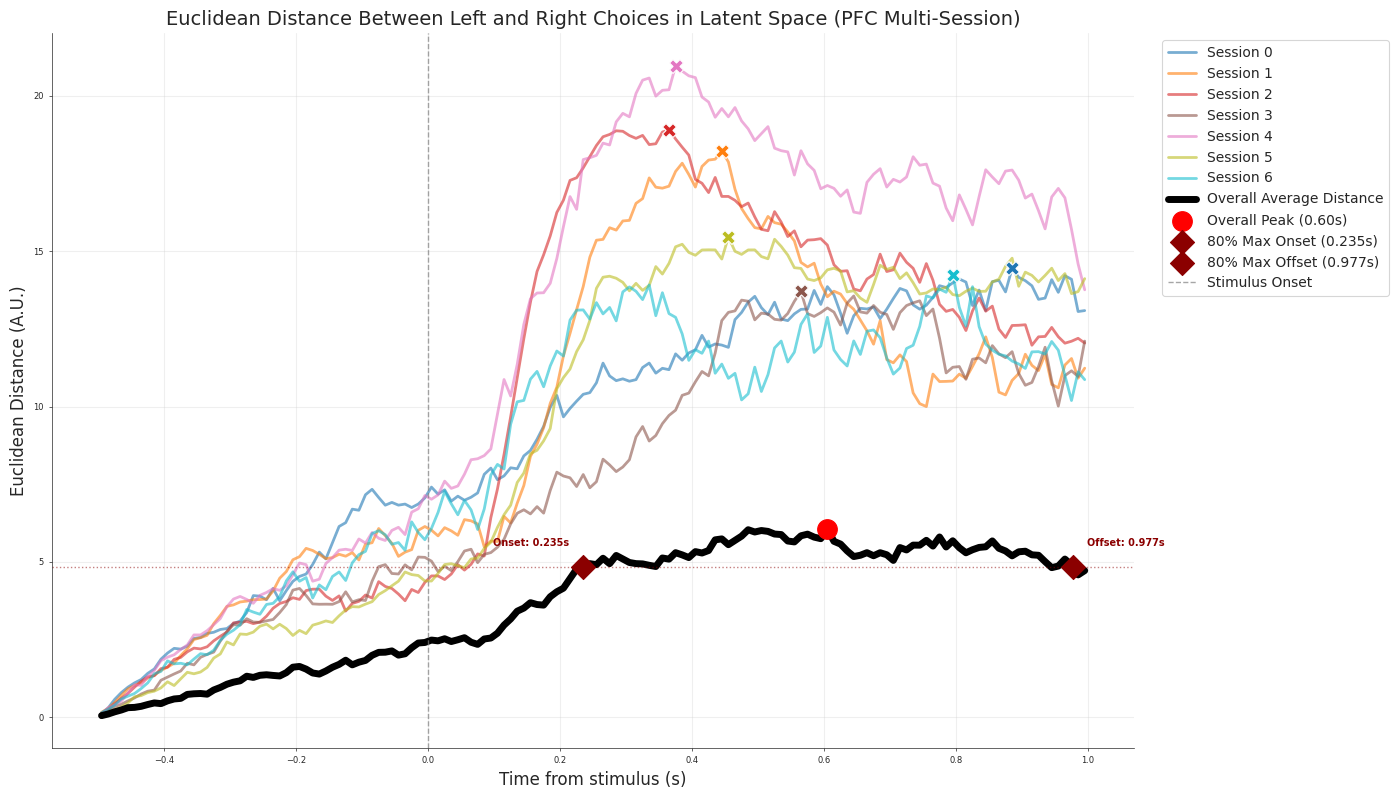

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Ensure time vector aligns with the mask
time_mask = (meta_stimOn.times >= -0.5) & (meta_stimOn.times <= 1.0)
t_vec = meta_stimOn.times[time_mask]

fig, ax = plt.subplots(figsize=(14, 8))

# Generate distinct colors for each session
num_sessions = len(sess_left_dict)
colors = plt.get_cmap('tab10', num_sessions)

# 1. Plot distances for each individual session and mark their peaks
for i, sid in enumerate(sess_left_dict.keys()):
    # Calculate Euclidean distance over time for this session
    sess_dist = np.sqrt(np.sum((sess_left_dict[sid] - sess_right_dict[sid])**2, axis=0))

    # Find peak for this session
    sess_max_idx = np.argmax(sess_dist)
    sess_max_time = t_vec[sess_max_idx]
    sess_max_dist = sess_dist[sess_max_idx]

    c = colors(i)

    # Plot curve
    ax.plot(t_vec, sess_dist, lw=2, alpha=0.6, color=c, label=f'Session {sid}')

    # Plot peak
    ax.scatter(sess_max_time, sess_max_dist, color=c, s=100, marker='X', edgecolors='white', zorder=4)

# 2. Calculate and plot the overall average distance
overall_dist = np.sqrt(np.sum((overall_left - overall_right)**2, axis=0))
ax.plot(t_vec, overall_dist, lw=5, color='black', label='Overall Average Distance')

# 3. Mark the peak distance for the overall average
max_idx = np.argmax(overall_dist)
max_time = t_vec[max_idx]
max_dist = overall_dist[max_idx]
ax.scatter(max_time, max_dist, color='red', s=200, zorder=5, label=f'Overall Peak ({max_time:.2f}s)')

# Calculate and mark the 80% maximum divergence points
threshold_80 = 0.8 * max_dist
crossings_80 = []
for j in range(len(overall_dist) - 1):
    if (overall_dist[j] <= threshold_80 < overall_dist[j+1]) or (overall_dist[j] >= threshold_80 > overall_dist[j+1]):
        x1, y1 = t_vec[j], overall_dist[j]
        x2, y2 = t_vec[j+1], overall_dist[j+1]
        t_cross = x1 + (threshold_80 - y1) * (x2 - x1) / (y2 - y1)
        crossings_80.append(t_cross)

if crossings_80:
    # Mark the first intersection (Onset)
    t_80_start = crossings_80[0]
    ax.scatter(t_80_start, threshold_80, color='darkred', s=150, marker='D', zorder=6, label=f'80% Max Onset ({t_80_start:.3f}s)')
    ax.annotate(f'Onset: {t_80_start:.3f}s', (t_80_start, threshold_80), xytext=(-10, 15), textcoords='offset points', color='darkred', weight='bold', ha='right')

    # Mark the last intersection (Offset) if it exists
    if len(crossings_80) > 1:
        t_80_end = crossings_80[-1]
        ax.scatter(t_80_end, threshold_80, color='darkred', s=150, marker='D', zorder=6, label=f'80% Max Offset ({t_80_end:.3f}s)')
        ax.annotate(f'Offset: {t_80_end:.3f}s', (t_80_end, threshold_80), xytext=(10, 15), textcoords='offset points', color='darkred', weight='bold', ha='left')

    ax.axhline(threshold_80, color='darkred', linestyle=':', alpha=0.5)

# 4. Add stimulus onset reference line
ax.axvline(0, color='gray', linestyle='--', alpha=0.7, label='Stimulus Onset')

# 5. Formatting
ax.set_title('Euclidean Distance Between Left and Right Choices in Latent Space (PFC Multi-Session)', fontsize=14)
ax.set_xlabel('Time from stimulus (s)', fontsize=12)
ax.set_ylabel('Euclidean Distance (A.U.)', fontsize=12)

# Put the legend outside the plot area since there are many items
ax.legend(fontsize=10, bbox_to_anchor=(1.02, 1), loc='upper left')

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
import os
import torch
import pickle
import pandas as pd
from google.colab import drive

# 1. 挂载 Google Drive (如果尚未挂载)
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')

backup_dir = '/content/drive/MyDrive/pfc_multisession_results_backup'

# 2. 重新定义丢失的 target_eids (提取 PFC ROI 的 Session EID)
if 'df_top10_filtered' in globals():
    target_eids = df_top10_filtered[df_top10_filtered['ROI'] == 'PFC']['Session EID'].tolist()
    print(f"Reconstructed target_eids for {len(target_eids)} sessions.")
else:
    print("Error: df_top10_filtered not found. Please re-run the filtering cells.")

# 3. 加载模型权重
model_path = os.path.join(backup_dir, 'multi_model_pfc.pth')
if os.path.exists(model_path) and 'multi_model' in globals():
    multi_model.load_state_dict(torch.load(model_path, map_location=device))
    multi_model.eval()
    print(f"Successfully loaded SPARKS model weights from {model_path}")
elif not os.path.exists(model_path):
    print(f"Model weights not found at {model_path}")

# 4. 加载潜变量轨迹
traj_path = os.path.join(backup_dir, 'latent_trajectories.pkl')
if os.path.exists(traj_path):
    with open(traj_path, 'rb') as f:
        latent_results = pickle.load(f)

    sess_left_dict = latent_results.get('sess_left_dict', {})
    sess_right_dict = latent_results.get('sess_right_dict', {})
    overall_left = latent_results.get('overall_left', None)
    overall_right = latent_results.get('overall_right', None)
    print(f"Successfully loaded latent trajectories from {traj_path}")
else:
    print(f"Latent trajectories not found at {traj_path}")

Mounted at /content/drive
Reconstructed target_eids for 7 sessions.
Successfully loaded SPARKS model weights from /content/drive/MyDrive/pfc_multisession_results_backup/multi_model_pfc.pth
Successfully loaded latent trajectories from /content/drive/MyDrive/pfc_multisession_results_backup/latent_trajectories.pkl


Remaining trials for analysis: 58


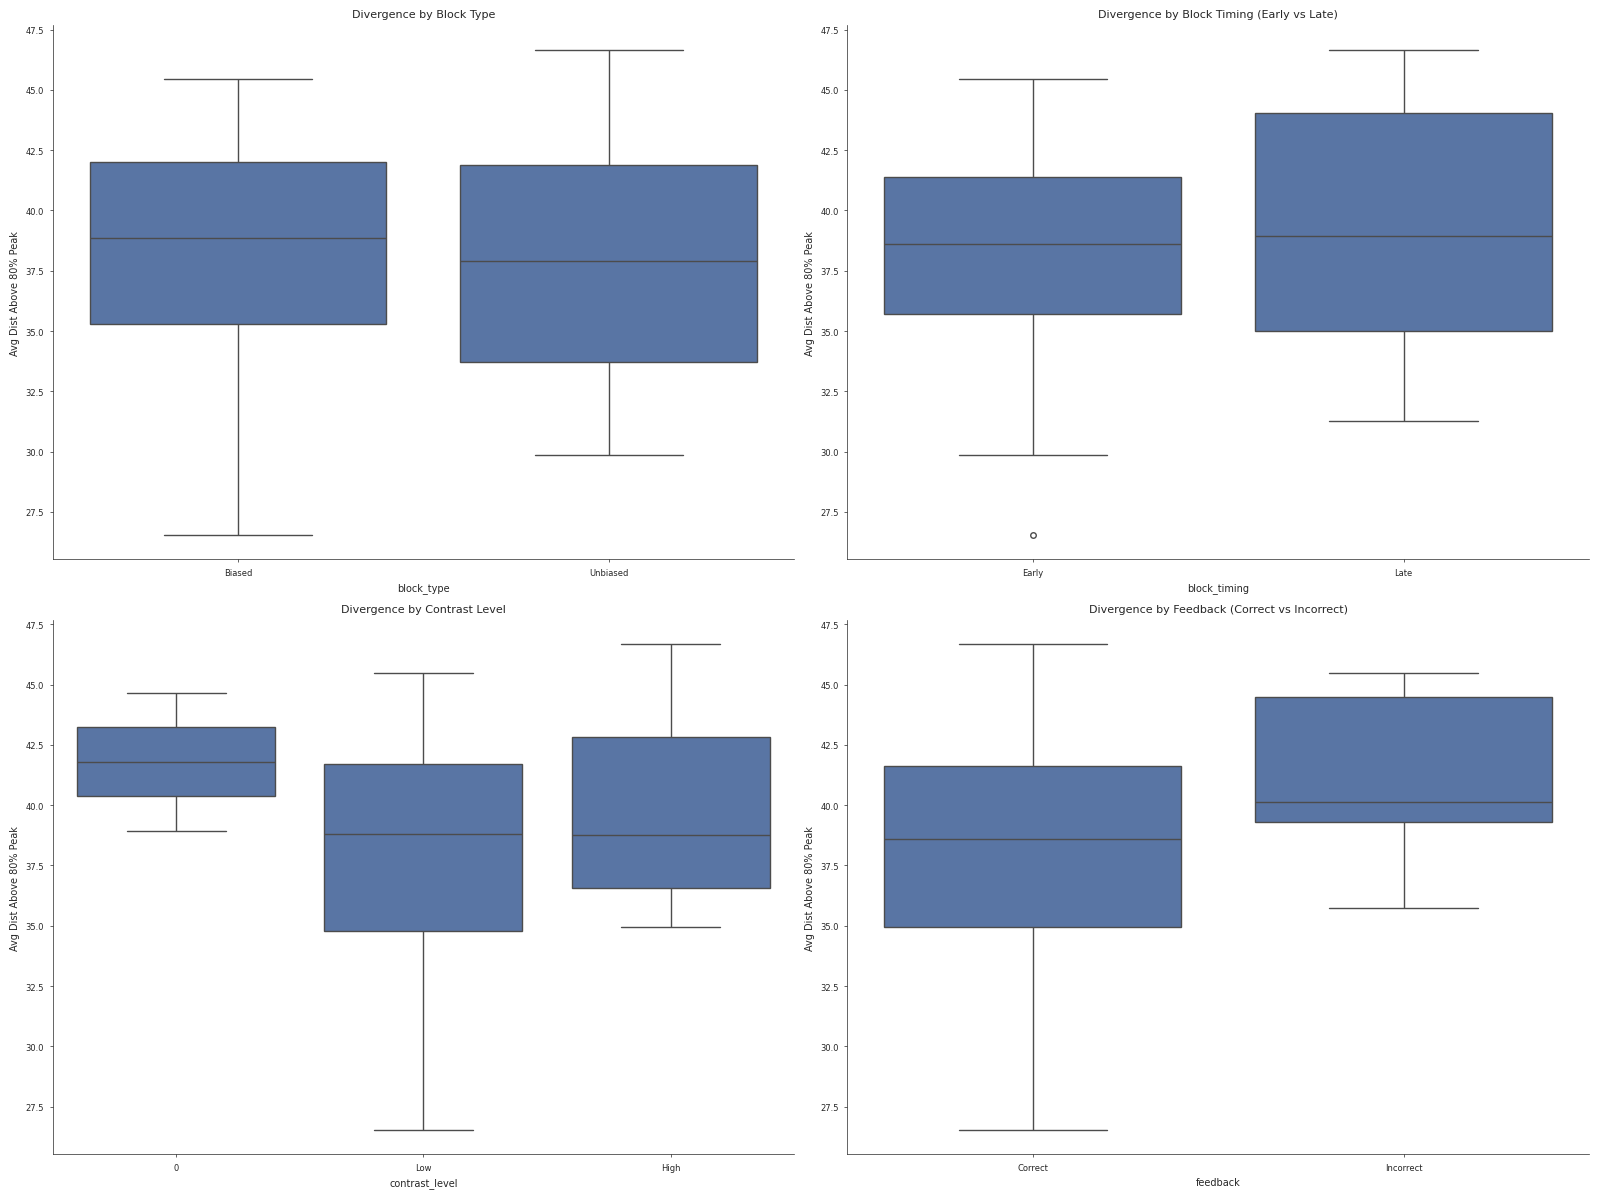

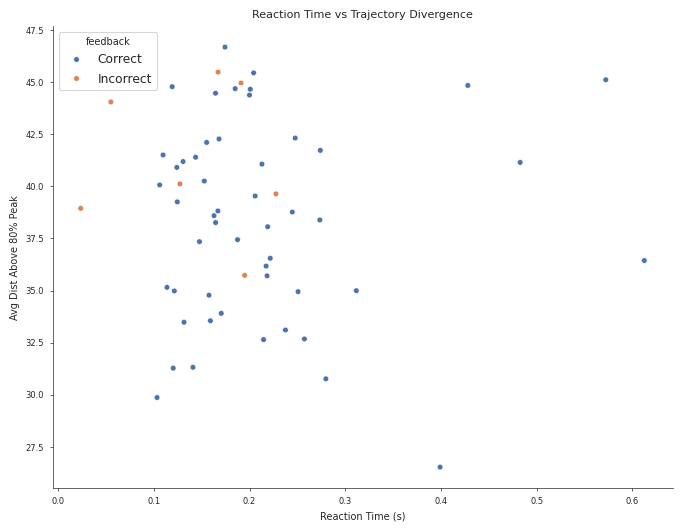

Divergence metrics and trial conditions extracted and stored in 'session0_divergence_df'.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import torch

# 1. Get Session 0 data
sid = 0
eid = target_eids[sid]
test_dl = multi_dl_dict[sid]['test']
multi_model.eval()

# Extract latent states for all trials in session 0 test set
latent_states = []
choices = []

with torch.no_grad():
    for inputs, y in test_dl:
        inputs = inputs.float().to(device)
        inputs = torch.nan_to_num(inputs, nan=0.0)
        T = inputs.shape[-1]
        multi_model.encoder.zero_()
        encoder_outputs = torch.zeros([len(inputs), latent_dim, tau_p]).to(device)

        batch_latents = []
        for t in range(T - tau_f + 1):
            encoder_outputs, decoder_outputs, mu, logvar = multi_model(
                inputs[..., t],
                encoder_outputs=encoder_outputs,
                session_id=sid
            )
            batch_latents.append(mu.unsqueeze(-1))

        batch_latents = torch.cat(batch_latents, dim=-1)
        latent_states.append(batch_latents.cpu().numpy())
        choices.append(y.numpy())

latent_states = np.concatenate(latent_states, axis=0) # (Trials, latent_dim, Time)
choices = np.concatenate(choices, axis=0)

# 2. Calculate trial-by-trial divergence
# Calculate average left and right trajectories for session 0
idx_right = (choices == 1.0)
idx_left = (choices == -1.0)
latent_right_avg = latent_states[idx_right].mean(axis=0)
latent_left_avg = latent_states[idx_left].mean(axis=0)

# Calculate distance between average left and right to find the peak
avg_dist = np.sqrt(np.sum((latent_left_avg - latent_right_avg)**2, axis=0))
max_dist_val = np.max(avg_dist)
threshold = 0.8 * max_dist_val

time_mask_bins = (meta_stimOn.times >= -0.5) & (meta_stimOn.times <= 1.0)
t_vec = meta_stimOn.times[time_mask_bins]

trial_metrics = []

for i in range(latent_states.shape[0]):
    trial_latent = latent_states[i]
    trial_choice = choices[i]

    # Distance to the opposite choice average
    if trial_choice == 1.0:
        dist_to_opp = np.sqrt(np.sum((trial_latent - latent_left_avg)**2, axis=0))
    else:
        dist_to_opp = np.sqrt(np.sum((trial_latent - latent_right_avg)**2, axis=0))

    # Peak metrics for this trial
    trial_max_dist = np.max(dist_to_opp)
    trial_threshold = 0.8 * trial_max_dist

    # Time to first reach 80% of max peak
    above_thresh = np.where(dist_to_opp >= trial_threshold)[0]
    if len(above_thresh) > 0:
        first_cross_idx = above_thresh[0]
        time_to_80_peak = t_vec[first_cross_idx]
        avg_dist_above_80 = np.mean(dist_to_opp[above_thresh])
    else:
        time_to_80_peak = np.nan
        avg_dist_above_80 = np.nan

    trial_metrics.append({
        'time_to_80_peak': time_to_80_peak,
        'avg_dist_above_80': avg_dist_above_80
    })

metrics_df = pd.DataFrame(trial_metrics)

# 3. Get trial information using ONE
trials_full = meta_stimOn.trials[meta_stimOn.trials['eid'] == eid].reset_index(drop=True)

# Use ONE API to explicitly load trials object which contains the timing variables
try:
    trials_data = one.load_object(eid, 'trials', collection='alf')
    for key in ['firstMovement_times', 'stimOn_times', 'response_times']:
        if key in trials_data:
            arr = trials_data[key]
            if len(arr) == len(trials_full):
                trials_full[key] = arr
            elif len(arr) > len(trials_full):
                trials_full[key] = arr[:len(trials_full)]
            else:
                padded = np.pad(arr, (0, len(trials_full) - len(arr)), constant_values=np.nan)
                trials_full[key] = padded
except Exception as e:
    print(f"Could not map trials object via ONE due to error: {e}")

# Calculate RT for all trials first (strictly using firstMovement_times - stimOn_times)
if 'firstMovement_times' in trials_full.columns and 'stimOn_times' in trials_full.columns:
    trials_full['RT'] = trials_full['firstMovement_times'] - trials_full['stimOn_times']
else:
    trials_full['RT'] = np.nan

# Strictly apply EXACT same mask as dataloader initialization
valid_choice_mask = ~np.isnan(trials_full['choice'].values)
valid_rt_mask = (trials_full['RT'] > 0) & (trials_full['RT'] <= 1.0)
valid_trials_mask = valid_choice_mask & valid_rt_mask
valid_trials_df = trials_full[valid_trials_mask].reset_index(drop=True)

# Retrieve the test indices from the dataset generator
dataset_size = len(valid_trials_df)
train_size = int(0.8 * dataset_size)
test_size = dataset_size - train_size
generator = torch.Generator().manual_seed(42)
_, test_dataset_split = torch.utils.data.random_split(range(dataset_size), [train_size, test_size], generator=generator)
test_indices = test_dataset_split.indices

# Extract the test trials dataframe
test_trials_df = valid_trials_df.iloc[test_indices].reset_index(drop=True)

# Combine metrics with trial info
analysis_df = pd.concat([test_trials_df, metrics_df], axis=1)

# Any missing rows (should be aligned perfectly now)
analysis_df = analysis_df.dropna(subset=['RT']).reset_index(drop=True)
print(f"Remaining trials for analysis: {len(analysis_df)}")

if len(analysis_df) > 0:
    # 4. Define conditions
    analysis_df['block_type'] = 'Unbiased'
    analysis_df.loc[analysis_df['probabilityLeft'].isin([0.2, 0.8]), 'block_type'] = 'Biased'
    analysis_df.loc[analysis_df['probabilityLeft'] == 0.8, 'bias_direction'] = 'Left'
    analysis_df.loc[analysis_df['probabilityLeft'] == 0.2, 'bias_direction'] = 'Right'
    analysis_df.loc[analysis_df['probabilityLeft'] == 0.5, 'bias_direction'] = 'None'

    analysis_df['trial_number'] = analysis_df.index
    median_trial = analysis_df['trial_number'].median()
    analysis_df['block_timing'] = np.where(analysis_df['trial_number'] < median_trial, 'Early', 'Late')

    analysis_df['contrast'] = np.nansum([analysis_df['contrastLeft'], analysis_df['contrastRight']], axis=0)
    analysis_df['contrast_level'] = '0'
    analysis_df.loc[(analysis_df['contrast'] > 0) & (analysis_df['contrast'] < 0.5), 'contrast_level'] = 'Low'
    analysis_df.loc[analysis_df['contrast'] >= 0.5, 'contrast_level'] = 'High'

    analysis_df['feedback'] = np.where(analysis_df['feedbackType'] == 1.0, 'Correct', 'Incorrect')

    # 5. Analysis & Visualization
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # A. Block Type
    sns.boxplot(data=analysis_df, x='block_type', y='avg_dist_above_80', ax=axes[0, 0])
    axes[0, 0].set_title('Divergence by Block Type')
    axes[0, 0].set_ylabel('Avg Dist Above 80% Peak')

    # B. Block Timing
    sns.boxplot(data=analysis_df, x='block_timing', y='avg_dist_above_80', ax=axes[0, 1])
    axes[0, 1].set_title('Divergence by Block Timing (Early vs Late)')
    axes[0, 1].set_ylabel('Avg Dist Above 80% Peak')

    # C. Contrast Level
    sns.boxplot(data=analysis_df, x='contrast_level', y='avg_dist_above_80', order=['0', 'Low', 'High'], ax=axes[1, 0])
    axes[1, 0].set_title('Divergence by Contrast Level')
    axes[1, 0].set_ylabel('Avg Dist Above 80% Peak')

    # D. Feedback (Correct vs Incorrect)
    sns.boxplot(data=analysis_df, x='feedback', y='avg_dist_above_80', ax=axes[1, 1])
    axes[1, 1].set_title('Divergence by Feedback (Correct vs Incorrect)')
    axes[1, 1].set_ylabel('Avg Dist Above 80% Peak')

    plt.tight_layout()
    plt.show()

    # Correlation with RT
    if not analysis_df['RT'].isna().all():
        plt.figure(figsize=(8, 6))
        sns.scatterplot(data=analysis_df, x='RT', y='avg_dist_above_80', hue='feedback')
        plt.title('Reaction Time vs Trajectory Divergence')
        plt.xlabel('Reaction Time (s)')
        plt.ylabel('Avg Dist Above 80% Peak')
        plt.show()
    else:
        print("Reaction times are not available in this dataset to plot correlation.")

    # Store the analysis dataframe for later use
    session0_divergence_df = analysis_df
    print("Divergence metrics and trial conditions extracted and stored in 'session0_divergence_df'.")
else:
    print("No valid trials remaining after RT filtering. Skipping visualization.")


Analyzing Session 1 (EID: dfbe628d-365b-461c-a07f-8b9911ba83aa)
Remaining trials for analysis: 78


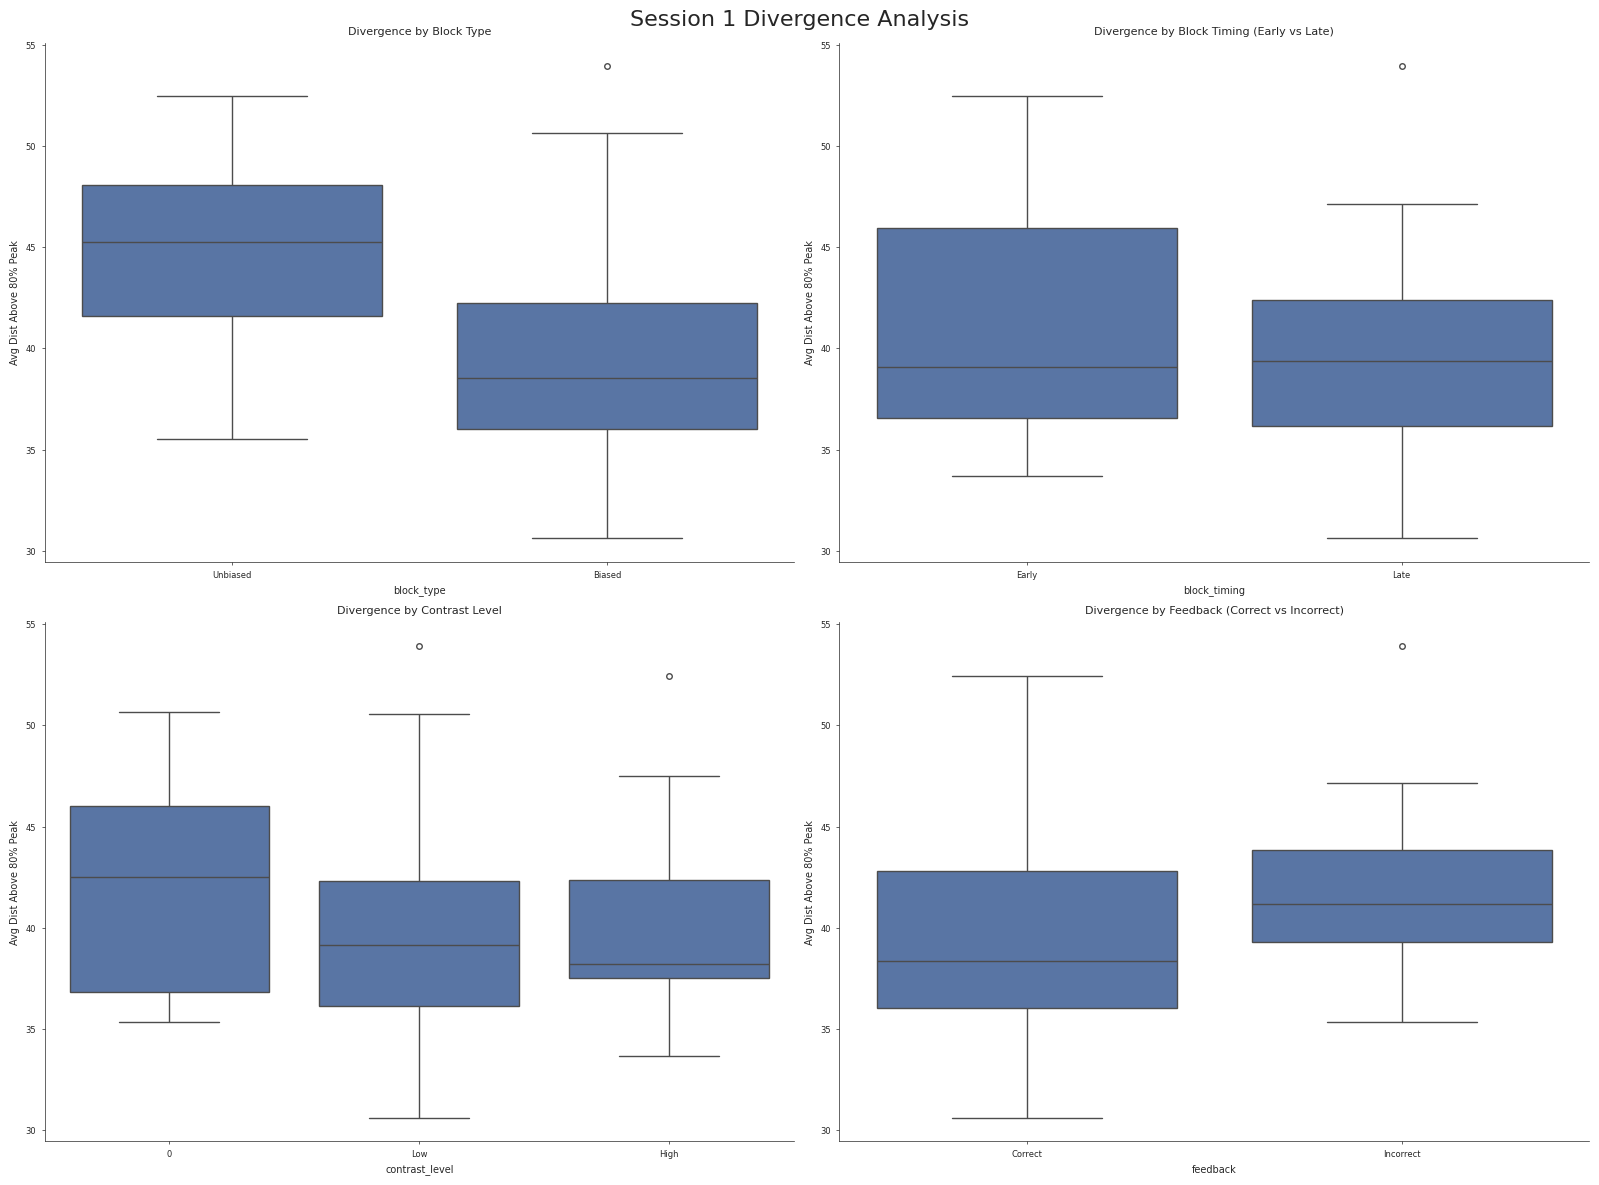

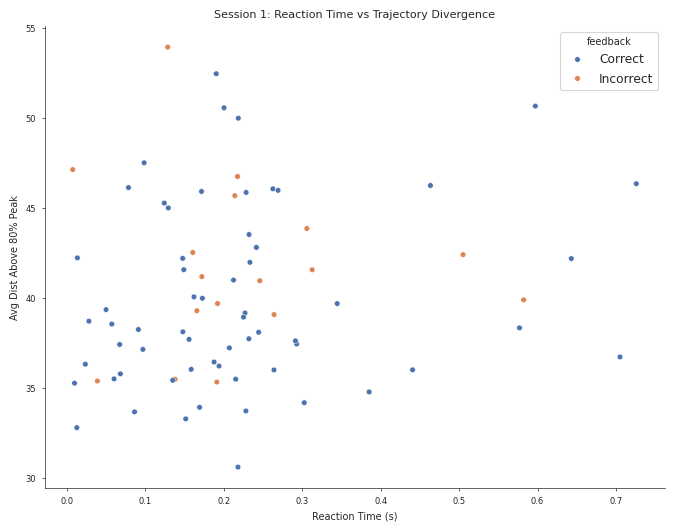


Analyzing Session 2 (EID: 1191f865-b10a-45c8-9c48-24a980fd9402)
Remaining trials for analysis: 105


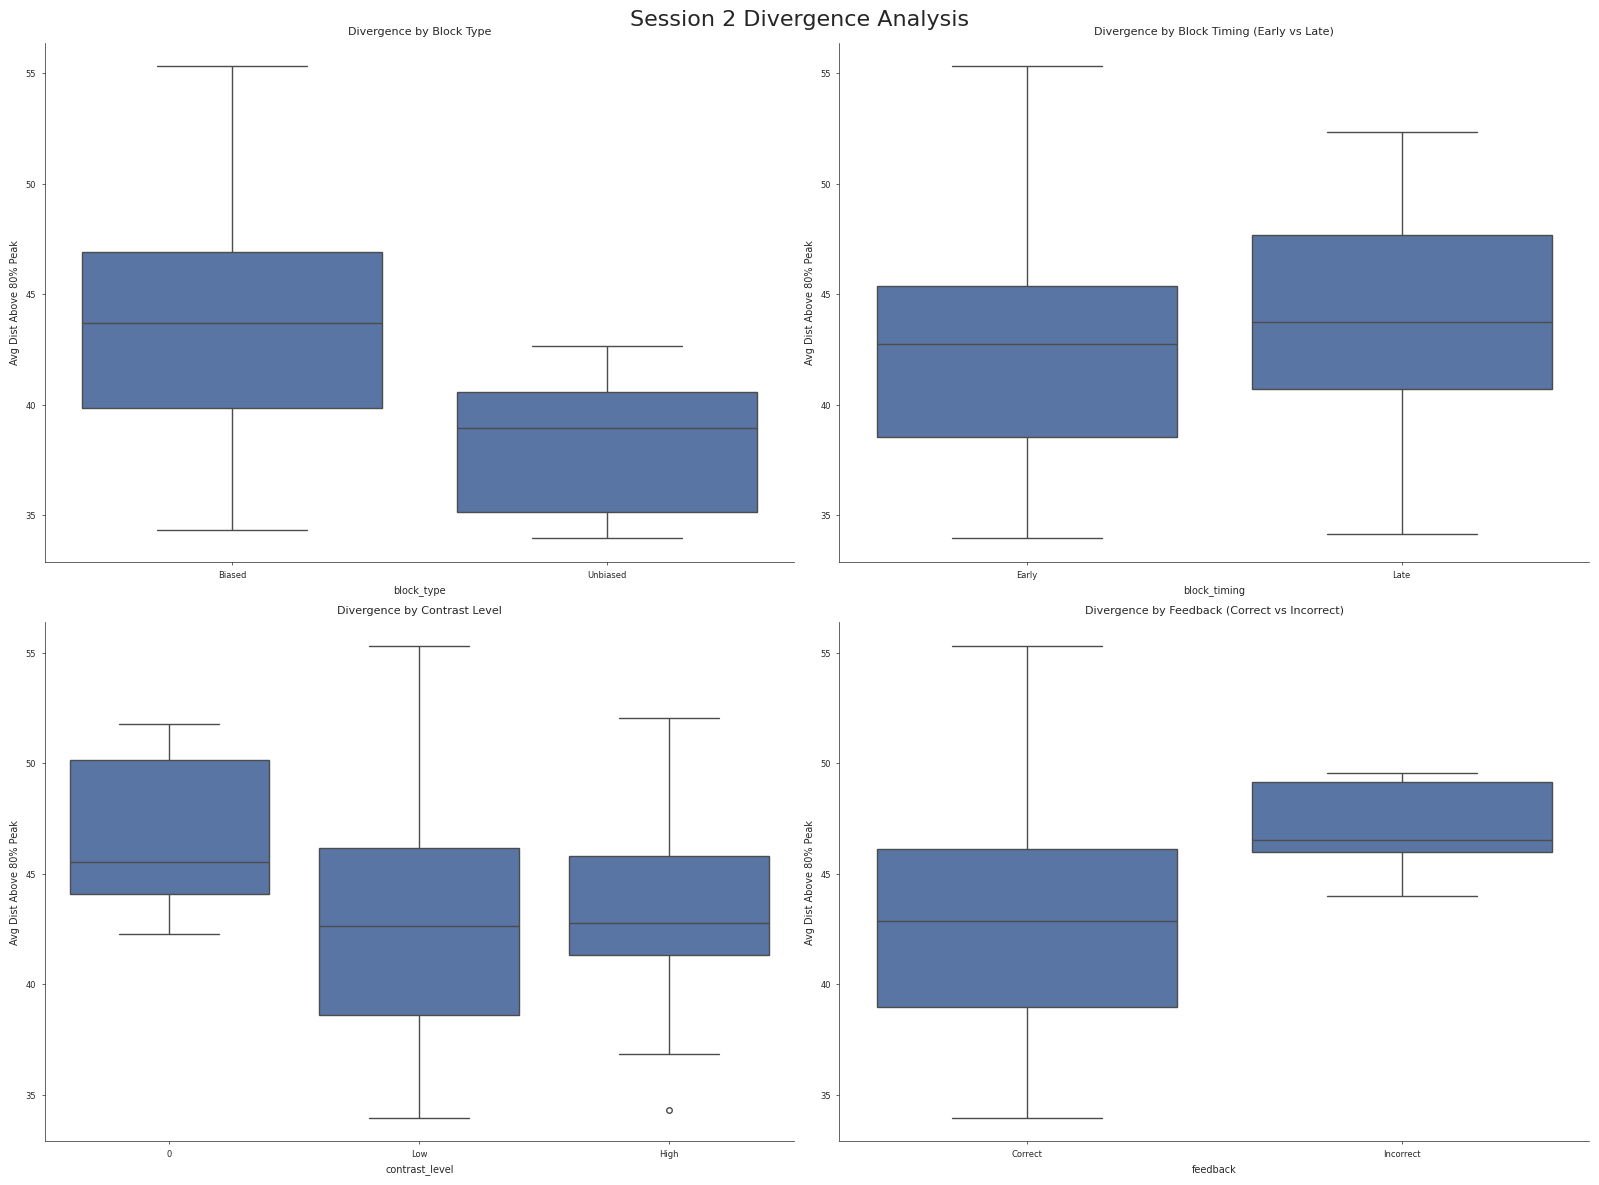

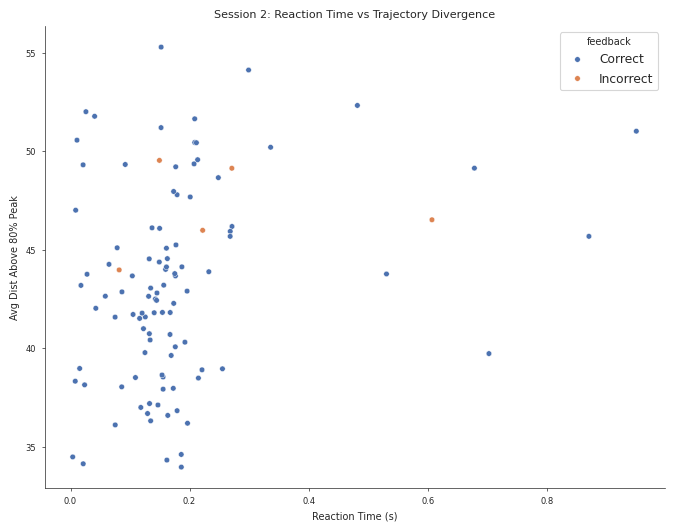


Analyzing Session 3 (EID: d33baf74-263c-4b37-a0d0-b79dcb80a764)
Remaining trials for analysis: 58


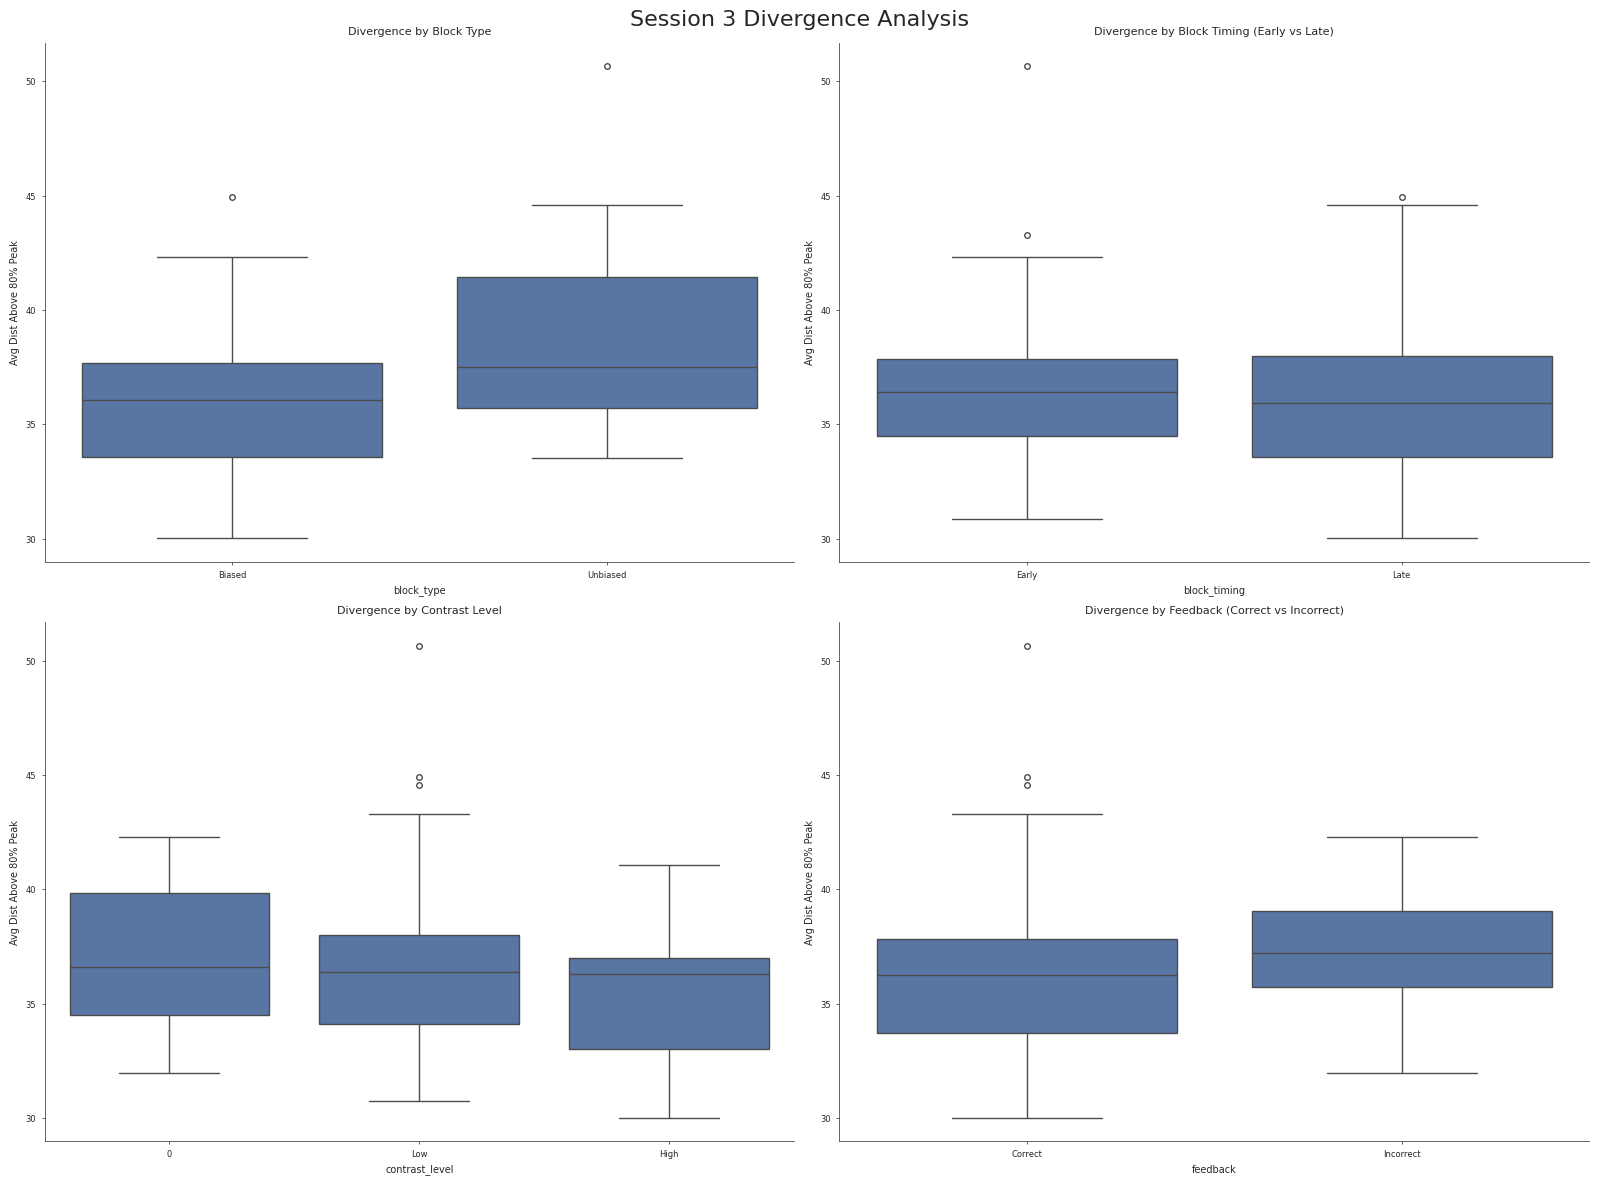

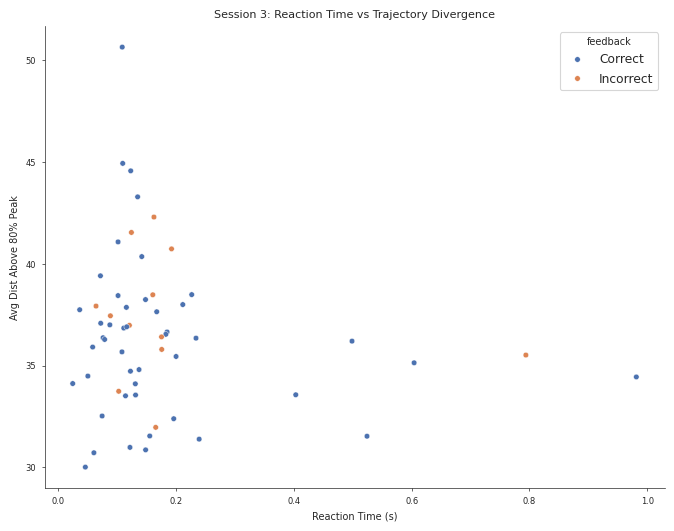


Analyzing Session 4 (EID: f99ac31f-171b-4208-a55d-5644c0ad51c3)
Remaining trials for analysis: 59


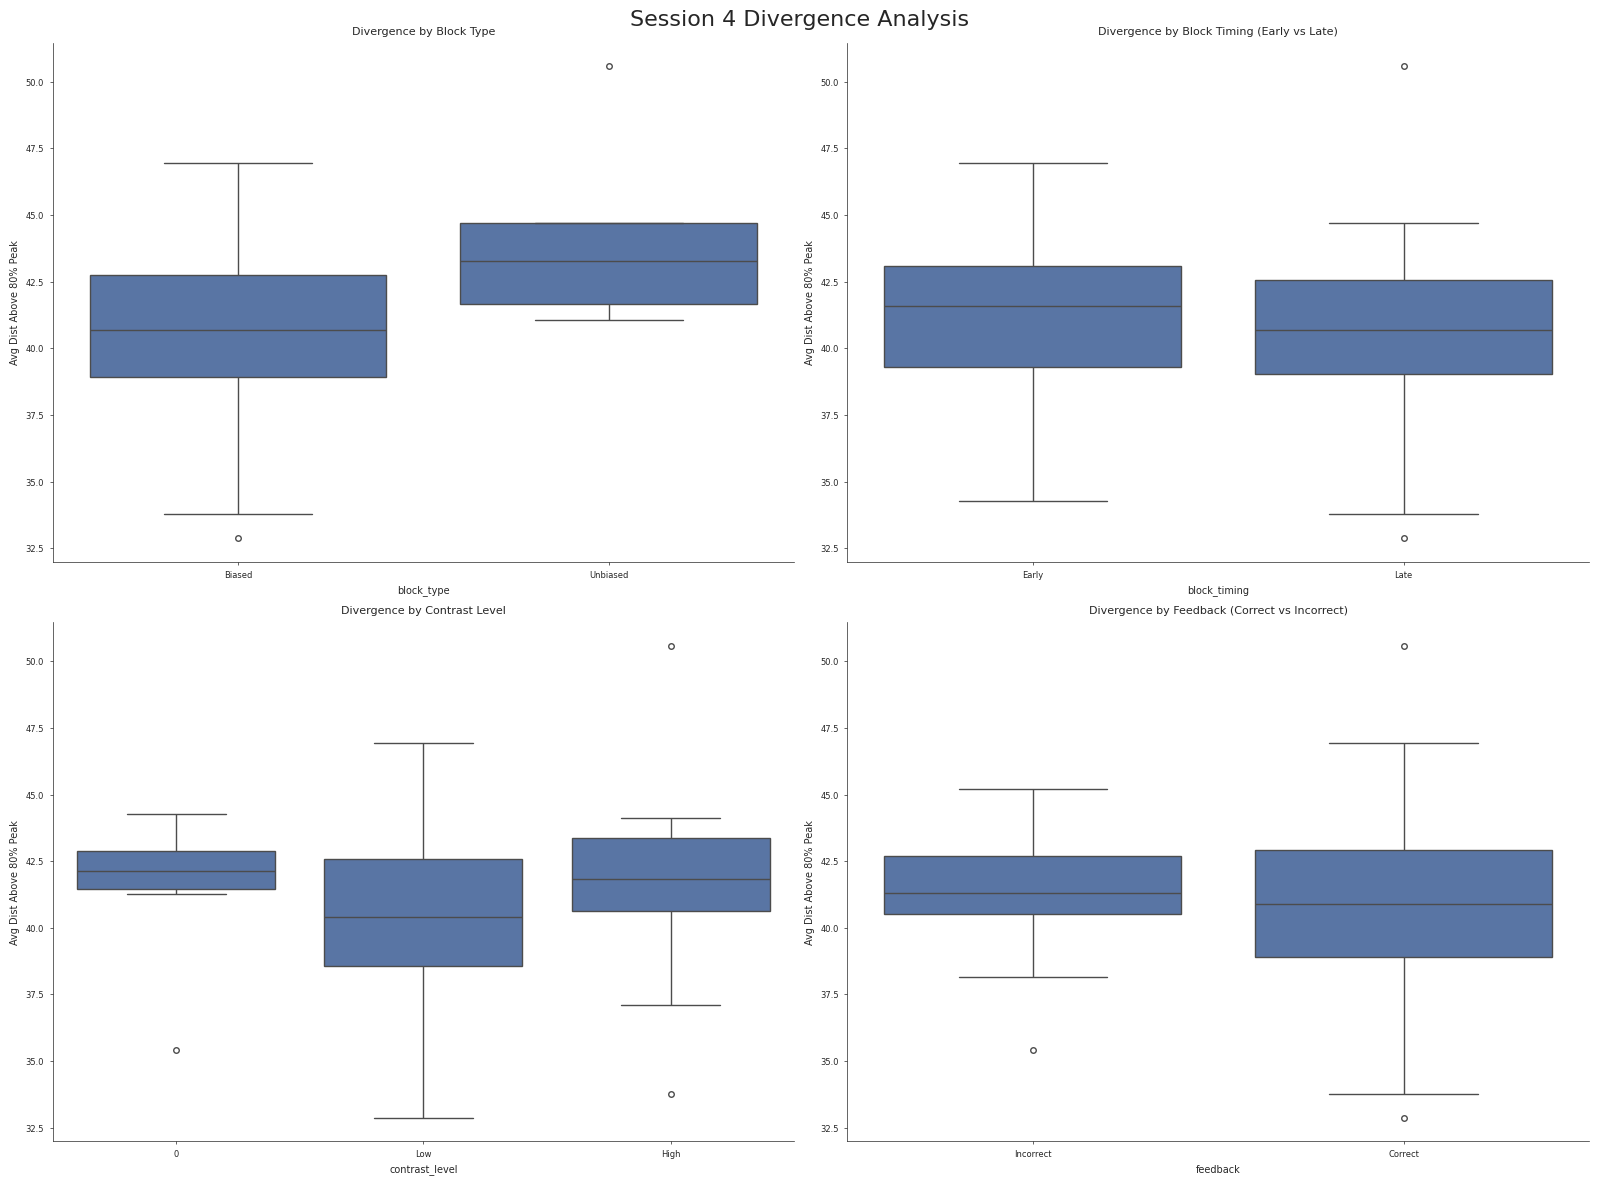

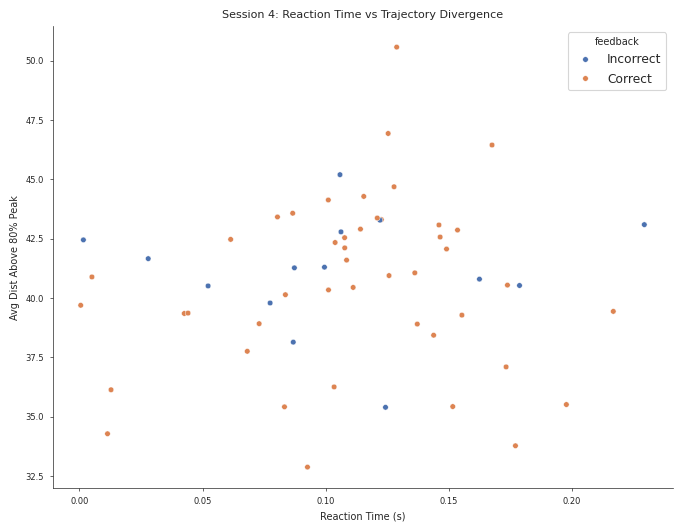


Analyzing Session 5 (EID: fb70ebf7-8175-42b0-9b7a-7c6e8612226e)
Remaining trials for analysis: 80


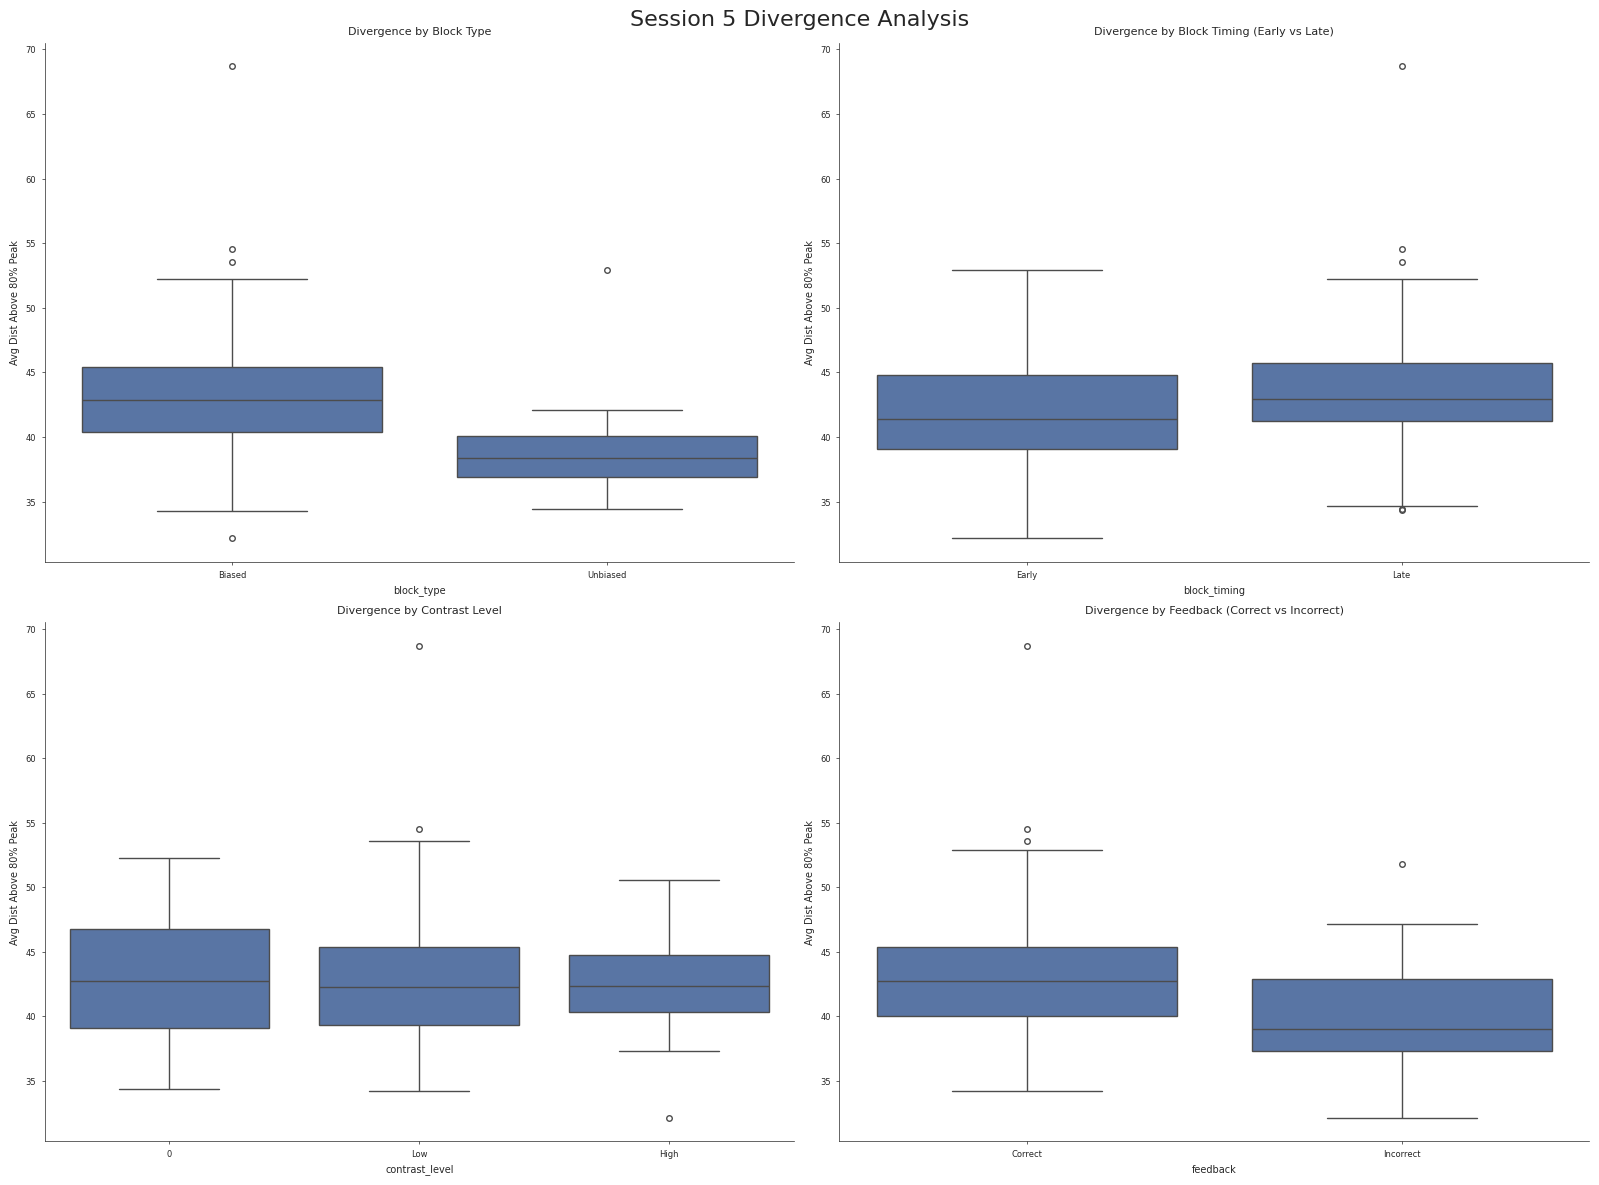

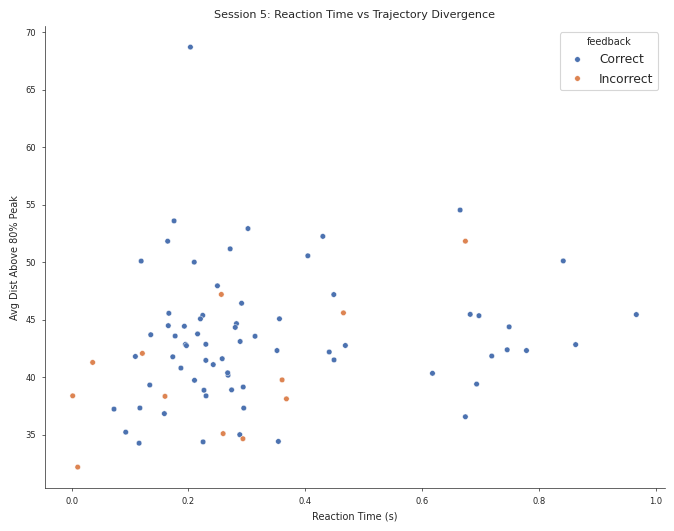


Analyzing Session 6 (EID: 5ec72172-3901-4771-8777-6e9490ca51fc)
Remaining trials for analysis: 116


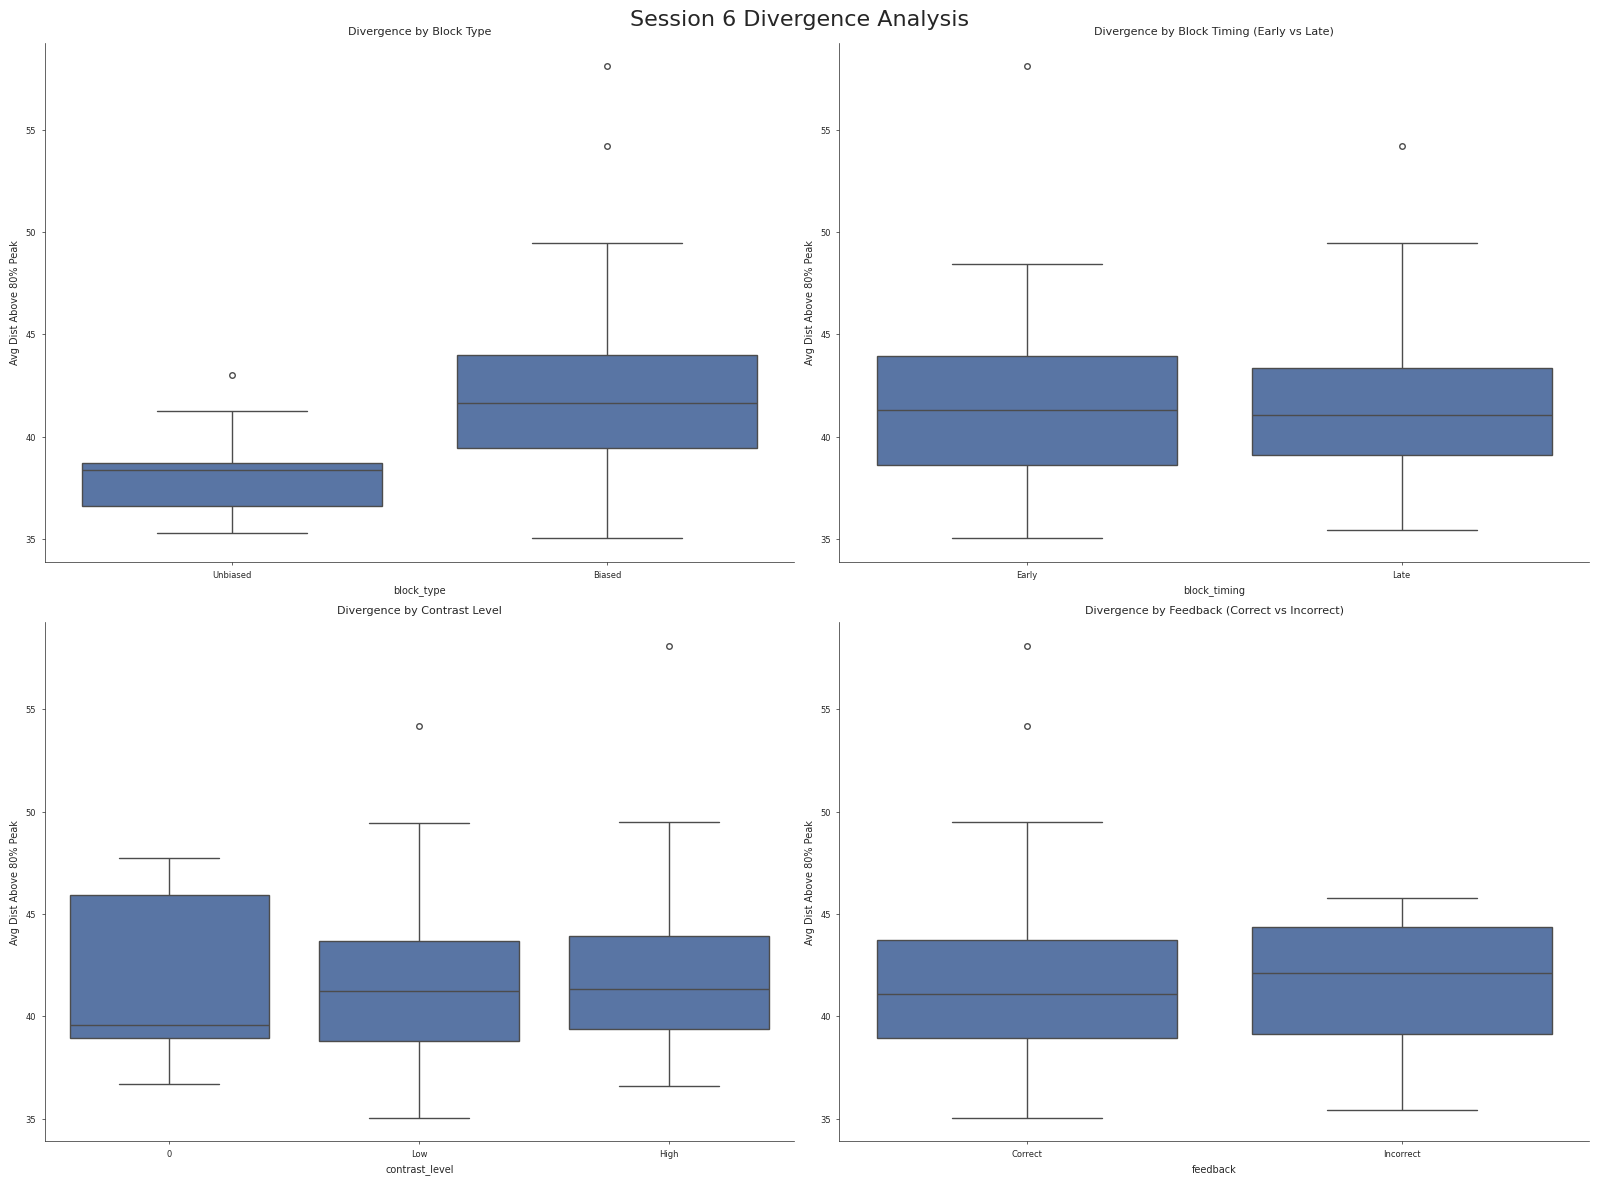

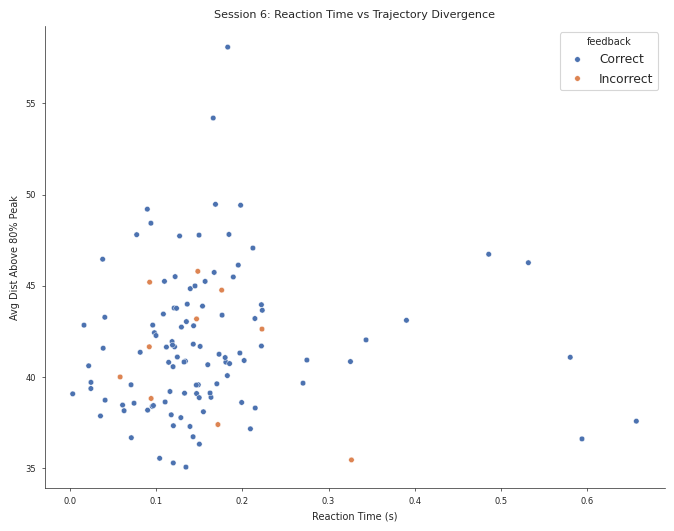

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# Create a dictionary to store the divergence dataframes for each session
all_session_divergence_dfs = {}
if 'session0_divergence_df' in globals():
    all_session_divergence_dfs[0] = session0_divergence_df

for sid in range(1, len(target_eids)):
    print(f"\n{'='*60}")
    print(f"Analyzing Session {sid} (EID: {target_eids[sid]})")
    print(f"{'='*60}")

    eid = target_eids[sid]
    test_dl = multi_dl_dict[sid]['test']
    multi_model.eval()

    # Extract latent states for all trials in this session's test set
    latent_states = []
    choices = []

    with torch.no_grad():
        for inputs, y in test_dl:
            inputs = inputs.float().to(device)
            inputs = torch.nan_to_num(inputs, nan=0.0)
            T = inputs.shape[-1]
            multi_model.encoder.zero_()
            encoder_outputs = torch.zeros([len(inputs), latent_dim, tau_p]).to(device)

            batch_latents = []
            for t in range(T - tau_f + 1):
                encoder_outputs, decoder_outputs, mu, logvar = multi_model(
                    inputs[..., t],
                    encoder_outputs=encoder_outputs,
                    session_id=sid
                )
                batch_latents.append(mu.unsqueeze(-1))

            batch_latents = torch.cat(batch_latents, dim=-1)
            latent_states.append(batch_latents.cpu().numpy())
            choices.append(y.numpy())

    latent_states = np.concatenate(latent_states, axis=0) # (Trials, latent_dim, Time)
    choices = np.concatenate(choices, axis=0)

    # Calculate average left and right trajectories
    idx_right = (choices == 1.0)
    idx_left = (choices == -1.0)

    if np.sum(idx_right) == 0 or np.sum(idx_left) == 0:
        print(f"Skipping session {sid} due to missing left/right choices in test set.")
        continue

    latent_right_avg = latent_states[idx_right].mean(axis=0)
    latent_left_avg = latent_states[idx_left].mean(axis=0)

    time_mask_bins = (meta_stimOn.times >= -0.5) & (meta_stimOn.times <= 1.0)
    t_vec = meta_stimOn.times[time_mask_bins]

    trial_metrics = []

    for i in range(latent_states.shape[0]):
        trial_latent = latent_states[i]
        trial_choice = choices[i]

        # Distance to the opposite choice average
        if trial_choice == 1.0:
            dist_to_opp = np.sqrt(np.sum((trial_latent - latent_left_avg)**2, axis=0))
        else:
            dist_to_opp = np.sqrt(np.sum((trial_latent - latent_right_avg)**2, axis=0))

        # Peak metrics for this trial
        trial_max_dist = np.max(dist_to_opp)
        trial_threshold = 0.8 * trial_max_dist

        # Time to first reach 80% of max peak
        above_thresh = np.where(dist_to_opp >= trial_threshold)[0]
        if len(above_thresh) > 0:
            first_cross_idx = above_thresh[0]
            time_to_80_peak = t_vec[first_cross_idx]
            avg_dist_above_80 = np.mean(dist_to_opp[above_thresh])
        else:
            time_to_80_peak = np.nan
            avg_dist_above_80 = np.nan

        trial_metrics.append({
            'time_to_80_peak': time_to_80_peak,
            'avg_dist_above_80': avg_dist_above_80
        })

    metrics_df = pd.DataFrame(trial_metrics)

    # Get trial information using ONE
    trials_full = meta_stimOn.trials[meta_stimOn.trials['eid'] == eid].reset_index(drop=True)

    try:
        trials_data = one.load_object(eid, 'trials', collection='alf')
        for key in ['firstMovement_times', 'stimOn_times', 'response_times']:
            if key in trials_data:
                arr = trials_data[key]
                if len(arr) == len(trials_full):
                    trials_full[key] = arr
                elif len(arr) > len(trials_full):
                    trials_full[key] = arr[:len(trials_full)]
                else:
                    padded = np.pad(arr, (0, len(trials_full) - len(arr)), constant_values=np.nan)
                    trials_full[key] = padded
    except Exception as e:
        print(f"Could not map trials object via ONE due to error: {e}")

    if 'firstMovement_times' in trials_full.columns and 'stimOn_times' in trials_full.columns:
        trials_full['RT'] = trials_full['firstMovement_times'] - trials_full['stimOn_times']
    else:
        trials_full['RT'] = np.nan

    # Strictly apply EXACT same mask as dataloader initialization
    valid_choice_mask = ~np.isnan(trials_full['choice'].values)
    valid_rt_mask = (trials_full['RT'] > 0) & (trials_full['RT'] <= 1.0)
    valid_trials_mask = valid_choice_mask & valid_rt_mask
    valid_trials_df = trials_full[valid_trials_mask].reset_index(drop=True)

    dataset_size = len(valid_trials_df)
    train_size = int(0.8 * dataset_size)
    test_size = dataset_size - train_size
    generator = torch.Generator().manual_seed(42)
    _, test_dataset_split = torch.utils.data.random_split(range(dataset_size), [train_size, test_size], generator=generator)
    test_indices = test_dataset_split.indices

    test_trials_df = valid_trials_df.iloc[test_indices].reset_index(drop=True)
    analysis_df = pd.concat([test_trials_df, metrics_df], axis=1)

    analysis_df = analysis_df.dropna(subset=['RT']).reset_index(drop=True)
    print(f"Remaining trials for analysis: {len(analysis_df)}")

    if len(analysis_df) > 0:
        analysis_df['block_type'] = 'Unbiased'
        analysis_df.loc[analysis_df['probabilityLeft'].isin([0.2, 0.8]), 'block_type'] = 'Biased'
        analysis_df.loc[analysis_df['probabilityLeft'] == 0.8, 'bias_direction'] = 'Left'
        analysis_df.loc[analysis_df['probabilityLeft'] == 0.2, 'bias_direction'] = 'Right'
        analysis_df.loc[analysis_df['probabilityLeft'] == 0.5, 'bias_direction'] = 'None'

        analysis_df['trial_number'] = analysis_df.index
        median_trial = analysis_df['trial_number'].median()
        analysis_df['block_timing'] = np.where(analysis_df['trial_number'] < median_trial, 'Early', 'Late')

        analysis_df['contrast'] = np.nansum([analysis_df['contrastLeft'], analysis_df['contrastRight']], axis=0)
        analysis_df['contrast_level'] = '0'
        analysis_df.loc[(analysis_df['contrast'] > 0) & (analysis_df['contrast'] < 0.5), 'contrast_level'] = 'Low'
        analysis_df.loc[analysis_df['contrast'] >= 0.5, 'contrast_level'] = 'High'

        analysis_df['feedback'] = np.where(analysis_df['feedbackType'] == 1.0, 'Correct', 'Incorrect')

        # Visualizations
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle(f"Session {sid} Divergence Analysis", fontsize=16)

        sns.boxplot(data=analysis_df, x='block_type', y='avg_dist_above_80', ax=axes[0, 0])
        axes[0, 0].set_title('Divergence by Block Type')
        axes[0, 0].set_ylabel('Avg Dist Above 80% Peak')

        sns.boxplot(data=analysis_df, x='block_timing', y='avg_dist_above_80', ax=axes[0, 1])
        axes[0, 1].set_title('Divergence by Block Timing (Early vs Late)')
        axes[0, 1].set_ylabel('Avg Dist Above 80% Peak')

        sns.boxplot(data=analysis_df, x='contrast_level', y='avg_dist_above_80', order=['0', 'Low', 'High'], ax=axes[1, 0])
        axes[1, 0].set_title('Divergence by Contrast Level')
        axes[1, 0].set_ylabel('Avg Dist Above 80% Peak')

        sns.boxplot(data=analysis_df, x='feedback', y='avg_dist_above_80', ax=axes[1, 1])
        axes[1, 1].set_title('Divergence by Feedback (Correct vs Incorrect)')
        axes[1, 1].set_ylabel('Avg Dist Above 80% Peak')

        plt.tight_layout()
        plt.show()

        if not analysis_df['RT'].isna().all():
            plt.figure(figsize=(8, 6))
            sns.scatterplot(data=analysis_df, x='RT', y='avg_dist_above_80', hue='feedback')
            plt.title(f'Session {sid}: Reaction Time vs Trajectory Divergence')
            plt.xlabel('Reaction Time (s)')
            plt.ylabel('Avg Dist Above 80% Peak')
            plt.show()

        all_session_divergence_dfs[sid] = analysis_df
        globals()[f'session{sid}_divergence_df'] = analysis_df
    else:
        print(f"No valid trials remaining after RT filtering for Session {sid}. Skipping visualization.")

### **Cross-Session Integrative Analysis in Shared Latent Space**
Here we pool the trial-by-trial divergence metrics across all 6 PFC sessions. Because SPARKS aligned their neural dynamics into a common geometric space, distances and times are directly comparable.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import numpy as np

# 1. Combine all session dataframes into a single global dataframe
dfs = []
for sid, df in all_session_divergence_dfs.items():
    df_copy = df.copy()
    df_copy['Session'] = f'Session {sid}'
    dfs.append(df_copy)

combined_df = pd.concat(dfs, ignore_index=True)
print(f"Successfully combined {len(dfs)} sessions.")
print(f"Total trials across all sessions for global analysis: {len(combined_df)}")

# Calculate Global Correlation for RT and Divergence
valid_rt_mask = ~combined_df['RT'].isna() & ~combined_df['avg_dist_above_80'].isna()
global_corr, global_pval = stats.pearsonr(
    combined_df.loc[valid_rt_mask, 'RT'],
    combined_df.loc[valid_rt_mask, 'avg_dist_above_80']
)
print(f"\nGlobal Pearson Correlation (RT vs Divergence): r = {global_corr:.3f}, p = {global_pval:.3e}")

Successfully combined 7 sessions.
Total trials across all sessions for global analysis: 554

Global Pearson Correlation (RT vs Divergence): r = 0.138, p = 1.132e-03


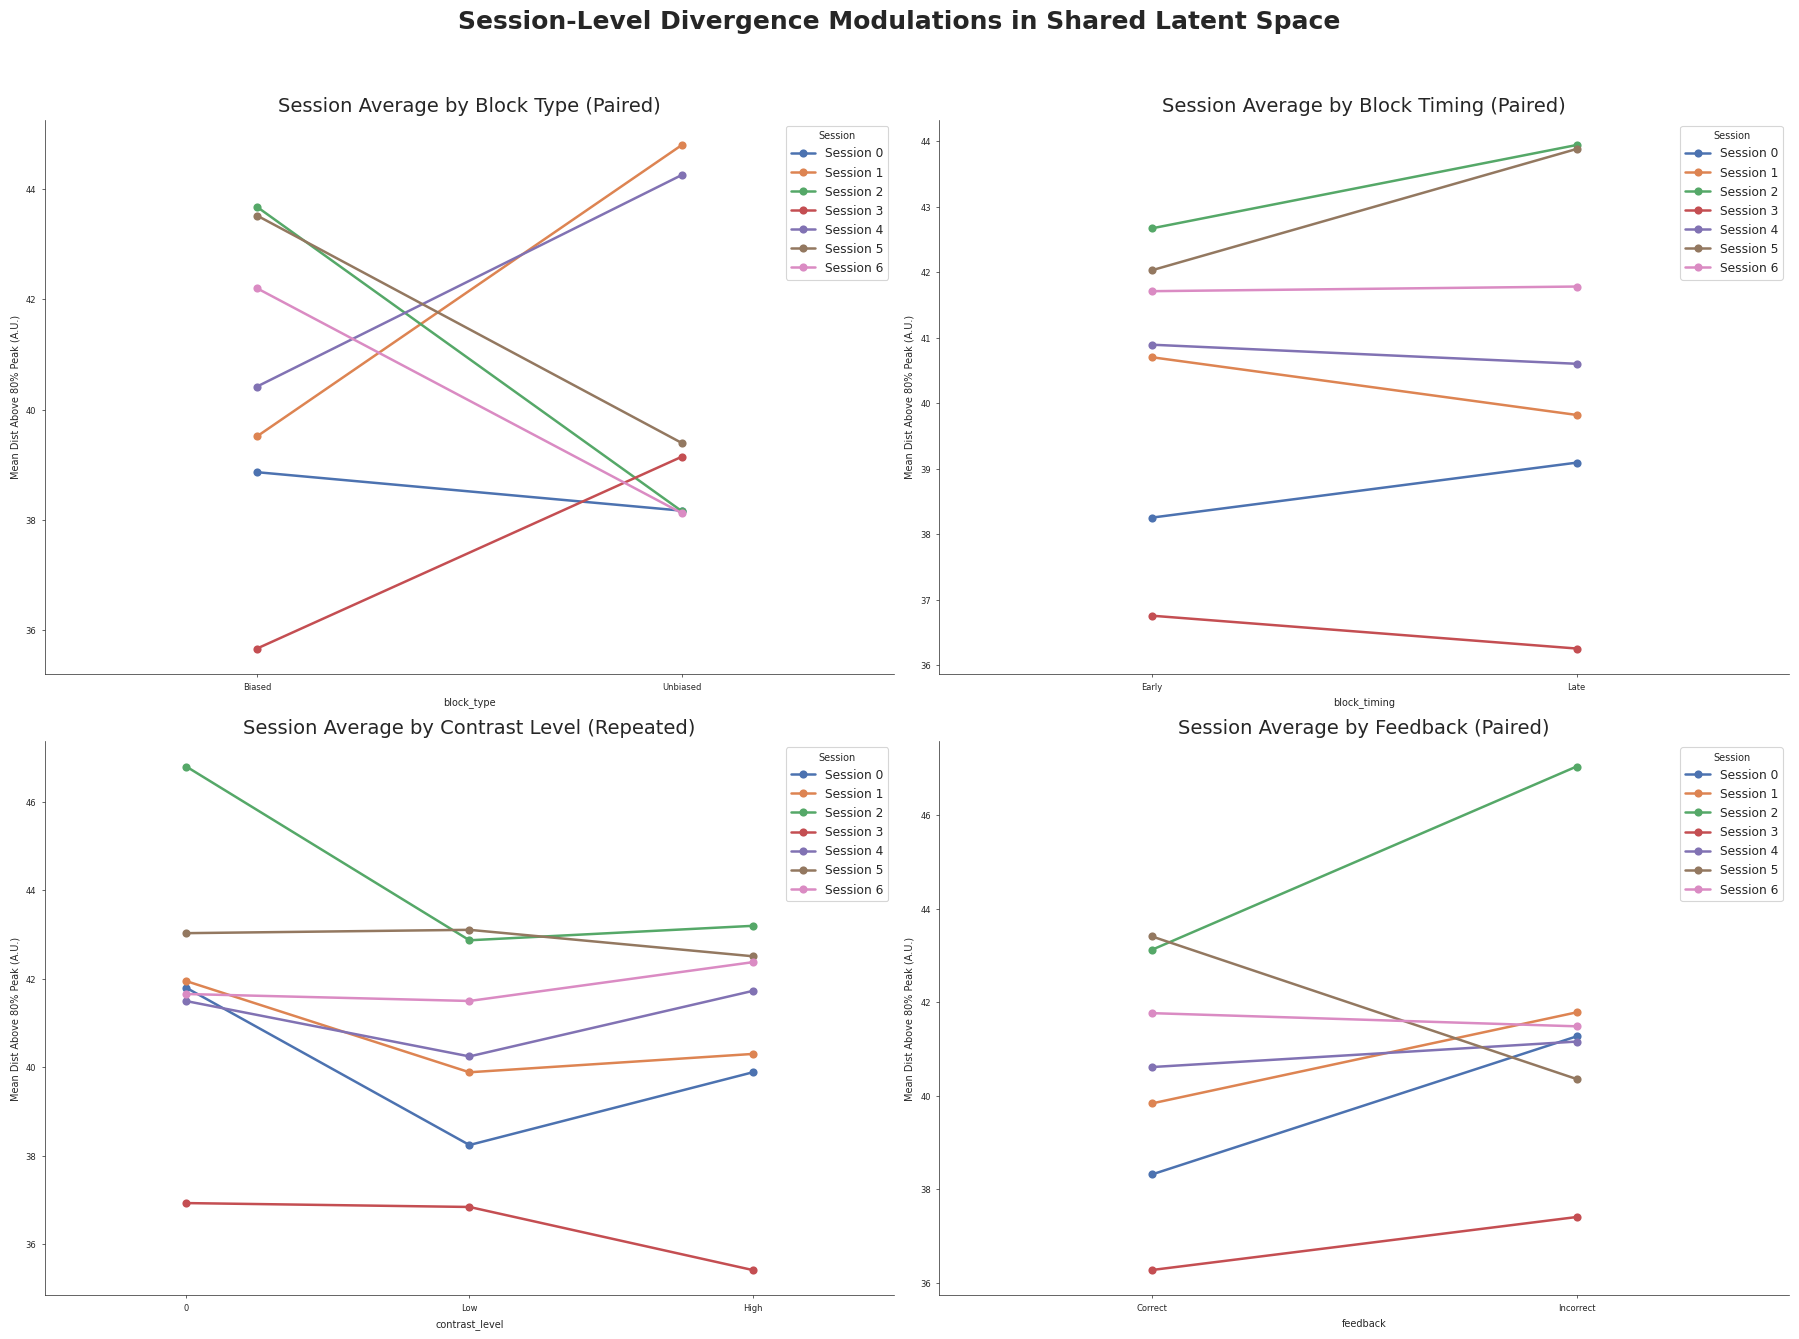

In [ ]:
# 2. Session-Level Behavioral Modulations (Matching Method 1: Paired/Repeated Measures)
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle("Session-Level Divergence Modulations in Shared Latent Space", fontsize=18, fontweight='bold')

# Block Type
sns.pointplot(data=combined_df, x='block_type', y='avg_dist_above_80', hue='Session', ax=axes[0, 0], markers='o', errorbar=None)
axes[0, 0].set_title('Session Average by Block Type (Paired)', fontsize=14)
axes[0, 0].set_ylabel('Mean Dist Above 80% Peak (A.U.)')

# Block Timing
sns.pointplot(data=combined_df, x='block_timing', y='avg_dist_above_80', hue='Session', ax=axes[0, 1], markers='o', errorbar=None)
axes[0, 1].set_title('Session Average by Block Timing (Paired)', fontsize=14)
axes[0, 1].set_ylabel('Mean Dist Above 80% Peak (A.U.)')

# Contrast Level
sns.pointplot(data=combined_df, x='contrast_level', y='avg_dist_above_80', hue='Session', order=['0', 'Low', 'High'], ax=axes[1, 0], markers='o', errorbar=None)
axes[1, 0].set_title('Session Average by Contrast Level (Repeated)', fontsize=14)
axes[1, 0].set_ylabel('Mean Dist Above 80% Peak (A.U.)')

# Feedback
sns.pointplot(data=combined_df, x='feedback', y='avg_dist_above_80', hue='Session', ax=axes[1, 1], markers='o', errorbar=None)
axes[1, 1].set_title('Session Average by Feedback (Paired)', fontsize=14)
axes[1, 1].set_ylabel('Mean Dist Above 80% Peak (A.U.)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


 统一分析：线性混合效应模型 (LMM)
 (控制Session的随机效应，在Trial级别进行统计检验)

--- 全模型 (Full Model) 结果 ---
               Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  avg_dist_above_80
No. Observations:    554      Method:              REML             
No. Groups:          7        Scale:               20.8723          
Min. group size:     58       Log-Likelihood:      -1633.5103       
Max. group size:     116      Converged:           Yes              
Mean group size:     79.1                                           
--------------------------------------------------------------------
                          Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------
Intercept                 41.427    1.123 36.882 0.000 39.226 43.629
C(feedback)[T.Incorrect]   0.662    0.600  1.103 0.270 -0.514  1.839
C(block_type)[T.Unbiased] -0.370    0.575 -0.643 0.520 -1.496  0.757
C(block_timing)[T.Late]    0.437    

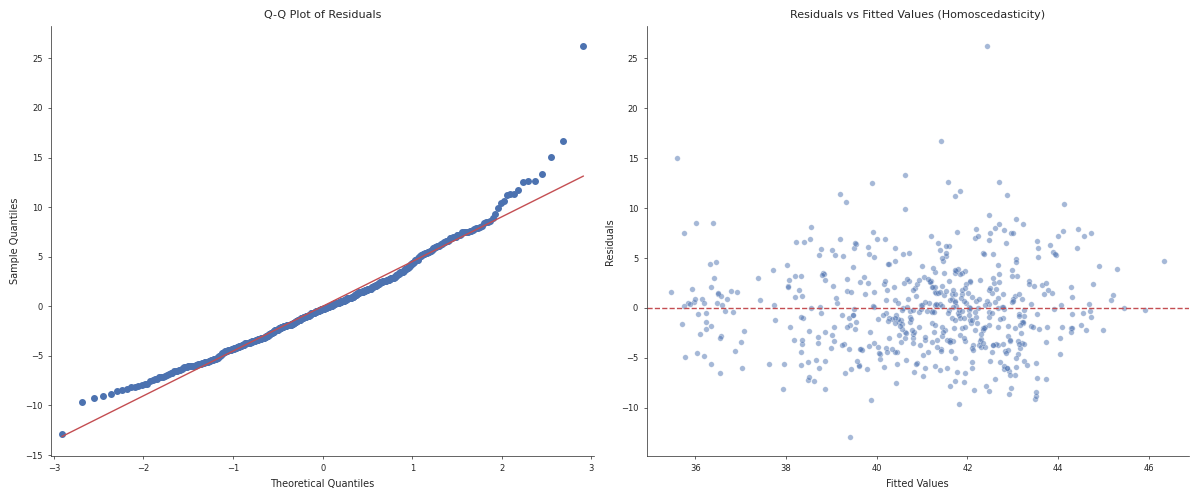


--- 各个效应的独立 LMM 检验 (单变量预测) ---

[Accuracy/Feedback (Correct/Incorrect)]
  C(feedback)[T.Incorrect]: p-value = 0.2357 

[Block Type (Biased/Unbiased)]
  C(block_type)[T.Unbiased]: p-value = 0.4266 

[Block Timing (Early/Late)]
  C(block_timing)[T.Late]: p-value = 0.3030 

[Contrast Level (0/Low/High)]
  C(contrast_level)[T.High]: p-value = 0.1441 
  C(contrast_level)[T.Low]: p-value = 0.0249 *

[Reaction Time (RT_z)]
  RT_z: p-value = 0.0041 **

[Wheel Speed (wheel_speed_z)]
  wheel_speed_z: p-value = 0.2995 


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

print("="*60)
print(" 统一分析：线性混合效应模型 (LMM)")
print(" (控制Session的随机效应，在Trial级别进行统计检验)")
print("="*60)

# 清理数据用于建模，确保新加入的 wheel_speed 也没有缺失值
df_clean = combined_df.dropna(subset=['avg_dist_above_80', 'feedback', 'block_type', 'block_timing', 'contrast_level', 'RT', 'wheel_speed']).copy()

# 为了模型收敛和解释，标准化连续变量 RT 和 wheel_speed
df_clean['RT_z'] = (df_clean['RT'] - df_clean['RT'].mean()) / df_clean['RT'].std()
df_clean['wheel_speed_z'] = (df_clean['wheel_speed'] - df_clean['wheel_speed'].mean()) / df_clean['wheel_speed'].std()
# 注：Trial级别的 Accuracy 其实就是 feedback (Correct vs Incorrect)

# 1. 构建全模型 (Full Model)
# 包含所有关心的固定效应，以及Session作为随机截距
formula_full = "avg_dist_above_80 ~ C(feedback) + C(block_type) + C(block_timing) + C(contrast_level) + RT_z + wheel_speed_z"

try:
    mdl_full = smf.mixedlm(formula_full, df_clean, groups=df_clean["Session"]).fit()
    print("\n--- 全模型 (Full Model) 结果 ---")
    print(mdl_full.summary())

    # 2. 假设检验 (Assumption Checks)
    print("\n--- 模型假设检验 ---")
    residuals = mdl_full.resid

    # 正态性检验 (D'Agostino's K-squared test)
    stat_norm, p_norm = stats.normaltest(residuals)
    print(f"残差正态性检验 (D'Agostino's K-squared): p-value = {p_norm:.4f}")
    if p_norm < 0.05:
        print(" -> 警告: 残差可能不严格服从正态分布。大样本下LMM对轻微偏离具有鲁棒性，但需结合QQ图判断。")
    else:
        print(" -> 通过: 残差服从正态分布。")

    # 可视化残差
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Q-Q Plot
    sm.qqplot(residuals, line='s', ax=axes[0])
    axes[0].set_title("Q-Q Plot of Residuals")

    # Residuals vs Fitted
    fitted_vals = mdl_full.fittedvalues
    sns.scatterplot(x=fitted_vals, y=residuals, ax=axes[1], alpha=0.5)
    axes[1].axhline(0, color='r', linestyle='--')
    axes[1].set_xlabel("Fitted Values")
    axes[1].set_ylabel("Residuals")
    axes[1].set_title("Residuals vs Fitted Values (Homoscedasticity)")

    plt.tight_layout()
    plt.show()

    # 3. 独立效应检验 (Single Models)
    # 考虑到不同变量可能存在共线性，我们也拟合单独的模型考察边缘效应
    print("\n--- 各个效应的独立 LMM 检验 (单变量预测) ---")

    variables = {
        'Accuracy/Feedback (Correct/Incorrect)': 'C(feedback)',
        'Block Type (Biased/Unbiased)': 'C(block_type)',
        'Block Timing (Early/Late)': 'C(block_timing)',
        'Contrast Level (0/Low/High)': 'C(contrast_level)',
        'Reaction Time (RT_z)': 'RT_z',
        'Wheel Speed (wheel_speed_z)': 'wheel_speed_z'
    }

    for name, var in variables.items():
        formula_single = f"avg_dist_above_80 ~ {var}"
        mdl_single = smf.mixedlm(formula_single, df_clean, groups=df_clean["Session"]).fit()

        # 提取固定效应的 p-value
        p_vals = mdl_single.pvalues.drop('Intercept')
        p_vals = p_vals[~p_vals.index.str.contains('Var')] # 忽略随机效应方差的p-value

        print(f"\n[{name}]")
        for idx, p in p_vals.items():
            significance = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
            print(f"  {idx}: p-value = {p:.4f} {significance}")

except Exception as e:
    print(f"LMM 模型拟合或检验失败: {e}")

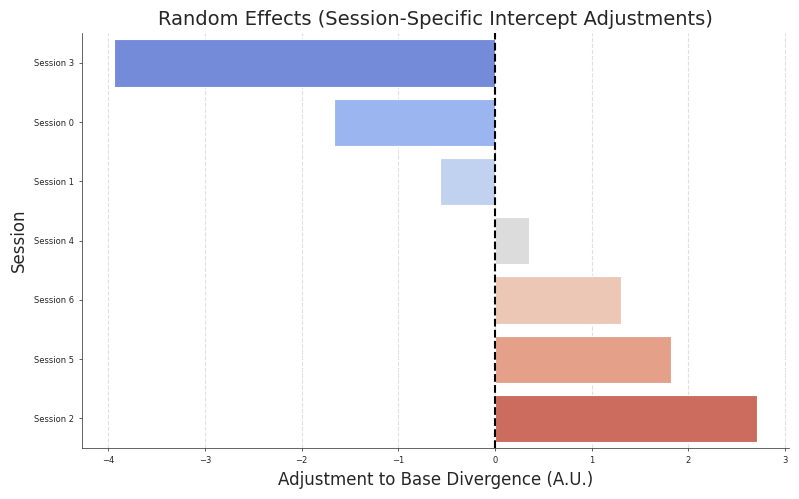

各个 Session 的随机效应截距偏移量：


,Session,Random_Intercept_Adjustment
0,Session 2,2.707207
1,Session 5,1.819431
2,Session 6,1.297502
3,Session 4,0.350137
4,Session 1,-0.570865
5,Session 0,-1.665125
6,Session 3,-3.938288


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- 1. 提取并可视化随机效应 (Random Effects: Session Intercepts) ---
random_effects = mdl_full.random_effects

# random_effects 是一个字典，键为 Session，值为包含随机截距的 Series
re_data = []
for session_name, effect in random_effects.items():
    re_data.append({
        'Session': session_name,
        'Random_Intercept_Adjustment': effect[0] # 提取 Group 的随机截距
    })

re_df = pd.DataFrame(re_data).sort_values('Random_Intercept_Adjustment')

plt.figure(figsize=(8, 5))
sns.barplot(data=re_df, x='Random_Intercept_Adjustment', y='Session', palette='coolwarm')
plt.axvline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Random Effects (Session-Specific Intercept Adjustments)', fontsize=14)
plt.xlabel('Adjustment to Base Divergence (A.U.)', fontsize=12)
plt.ylabel('Session', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("各个 Session 的随机效应截距偏移量：")
display(re_df.sort_values('Random_Intercept_Adjustment', ascending=False).reset_index(drop=True))

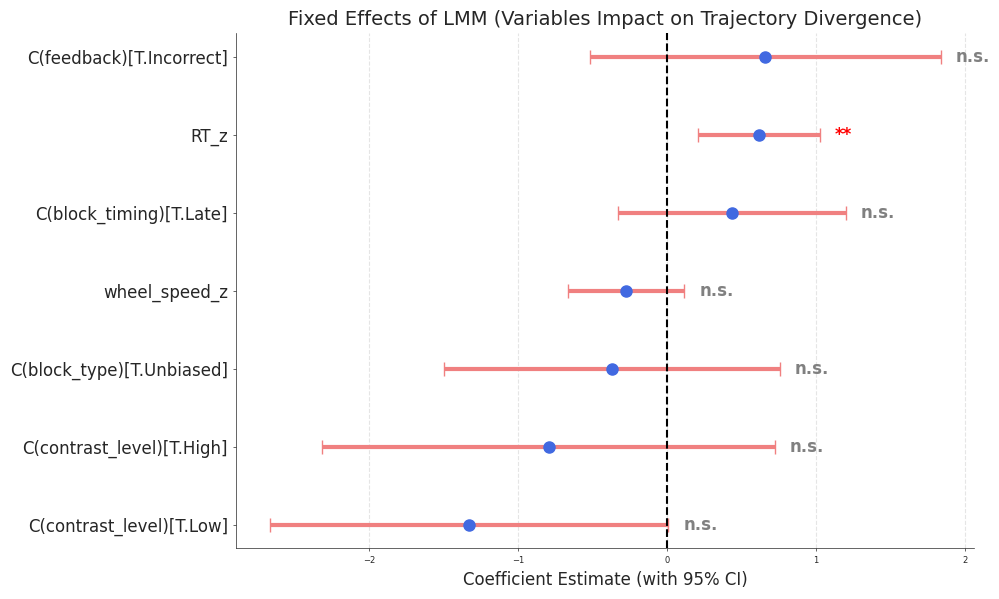

固定效应详细数据：


,Effect_Label,Coefficient,CI_Lower,CI_Upper,P-value
0,C(feedback)[T.Incorrect],0.662371,-0.514395,1.839136,0.269935
1,RT_z,0.618695,0.206944,1.030445,0.003229
2,C(block_timing)[T.Late],0.437311,-0.325464,1.200086,0.261150
3,wheel_speed_z,-0.272624,-0.662340,0.117092,0.170349
4,C(block_type)[T.Unbiased],-0.369555,-1.495734,0.756624,0.520120
5,C(contrast_level)[T.High],-0.794476,-2.315924,0.726972,0.306090
6,C(contrast_level)[T.Low],-1.328607,-2.666525,0.009311,0.051616


In [ ]:
# --- 2. 提取并可视化固定效应 (Fixed Effects: Forest Plot) ---
# 提取系数、标准误、P值和置信区间
fe_params = mdl_full.params.drop(['Intercept', 'Group Var'])
fe_pvals = mdl_full.pvalues.drop(['Intercept', 'Group Var'])
fe_conf_int = mdl_full.conf_int().drop(['Intercept', 'Group Var'])

fe_df = pd.DataFrame({
    'Effect': fe_params.index,
    'Coefficient': fe_params.values,
    'P-value': fe_pvals.values,
    'CI_Lower': fe_conf_int[0].values,
    'CI_Upper': fe_conf_int[1].values
})

# 美化标签名称以用于绘图
fe_df['Effect_Label'] = fe_df['Effect'].str.replace('C\\(', '', regex=False).str.replace('\\)', '', regex=False).str.replace('\\[T.', ' (', regex=False).str.replace('\\]', ')', regex=False)

# 按照系数大小排序
fe_df = fe_df.sort_values('Coefficient', ascending=True).reset_index(drop=True)

plt.figure(figsize=(10, 6))
# 绘制误差线 (置信区间)
plt.errorbar(x=fe_df['Coefficient'], y=range(len(fe_df)),
             xerr=[fe_df['Coefficient'] - fe_df['CI_Lower'], fe_df['CI_Upper'] - fe_df['Coefficient']],
             fmt='o', color='royalblue', ecolor='lightcoral', elinewidth=3, capsize=5, markersize=8)

plt.axvline(0, color='black', linestyle='--', linewidth=1.5)
plt.yticks(range(len(fe_df)), fe_df['Effect_Label'], fontsize=12)
plt.xlabel('Coefficient Estimate (with 95% CI)', fontsize=12)
plt.title('Fixed Effects of LMM (Variables Impact on Trajectory Divergence)', fontsize=14)

# 标注显著性星号
for i, p in enumerate(fe_df['P-value']):
    if p < 0.001:
        sig = '***'
        color = 'red'
    elif p < 0.01:
        sig = '**'
        color = 'red'
    elif p < 0.05:
        sig = '*'
        color = 'red'
    else:
        sig = 'n.s.'
        color = 'grey'
    plt.text(fe_df['CI_Upper'].iloc[i] + 0.1, i, sig, verticalalignment='center', color=color, fontsize=12, fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("固定效应详细数据：")
display(fe_df[['Effect_Label', 'Coefficient', 'CI_Lower', 'CI_Upper', 'P-value']].sort_values('Coefficient', ascending=False).reset_index(drop=True))

In [ ]:
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

print("="*50)
print(" 方法1：Session 级别聚合检验 (Paired t-tests / ANOVA)")
print("="*50)

# 1. Feedback (配对 t 检验)
sess_fb = combined_df.groupby(['Session', 'feedback'])['avg_dist_above_80'].mean().unstack()
if sess_fb.shape[1] == 2:
    stat, p = stats.ttest_rel(sess_fb['Correct'], sess_fb['Incorrect'], nan_policy='omit')
    print(f"[Feedback] Correct vs Incorrect : p-value = {p:.4f}")

# 2. Block Type (配对 t 检验)
sess_bt = combined_df.groupby(['Session', 'block_type'])['avg_dist_above_80'].mean().unstack()
if sess_bt.shape[1] == 2:
    stat, p = stats.ttest_rel(sess_bt['Biased'], sess_bt['Unbiased'], nan_policy='omit')
    print(f"[Block Type] Biased vs Unbiased : p-value = {p:.4f}")

# 3. Block Timing (配对 t 检验)
sess_tm = combined_df.groupby(['Session', 'block_timing'])['avg_dist_above_80'].mean().unstack()
if sess_tm.shape[1] == 2:
    stat, p = stats.ttest_rel(sess_tm['Early'], sess_tm['Late'], nan_policy='omit')
    print(f"[Block Timing] Early vs Late      : p-value = {p:.4f}")

# 4. Contrast Level (单因素方差分析)
sess_ct = combined_df.groupby(['Session', 'contrast_level'])['avg_dist_above_80'].mean().unstack()
if sess_ct.shape[1] == 3:
    stat, p = stats.f_oneway(sess_ct['0'].dropna(), sess_ct['Low'].dropna(), sess_ct['High'].dropna())
    print(f"[Contrast Level] 0 vs Low vs High : p-value = {p:.4f}")


print("\n" + "="*50)
print(" 方法2：线性混合效应模型 LMM (Trial 级别 + Session 随机效应)")
print("="*50)

# 清理 NaN 用于建模
df_clean = combined_df.dropna(subset=['avg_dist_above_80', 'feedback', 'block_type', 'block_timing', 'contrast_level']).copy()

try:
    # 拟合不同变量的模型并输出显著性
    mdl_fb = smf.mixedlm("avg_dist_above_80 ~ C(feedback)", df_clean, groups=df_clean["Session"]).fit()
    print(f"[Feedback] 显著性 p-value = {mdl_fb.pvalues['C(feedback)[T.Incorrect]']:.4f}")

    mdl_bt = smf.mixedlm("avg_dist_above_80 ~ C(block_type)", df_clean, groups=df_clean["Session"]).fit()
    print(f"[Block Type] 显著性 p-value = {mdl_bt.pvalues['C(block_type)[T.Unbiased]']:.4f}")

    mdl_tm = smf.mixedlm("avg_dist_above_80 ~ C(block_timing)", df_clean, groups=df_clean["Session"]).fit()
    print(f"[Block Timing] 显著性 p-value = {mdl_tm.pvalues['C(block_timing)[T.Late]']:.4f}")

except Exception as e:
    print(f"混合效应模型拟合失败，原因: {e}")


 方法1：Session 级别聚合检验 (Paired t-tests / ANOVA)
[Feedback] Correct vs Incorrect : p-value = 0.2818
[Block Type] Biased vs Unbiased : p-value = 0.8823
[Block Timing] Early vs Late      : p-value = 0.4093
[Contrast Level] 0 vs Low vs High : p-value = 0.5224

 方法2：线性混合效应模型 LMM (Trial 级别 + Session 随机效应)
[Feedback] 显著性 p-value = 0.2357
[Block Type] 显著性 p-value = 0.4266
[Block Timing] 显著性 p-value = 0.3030


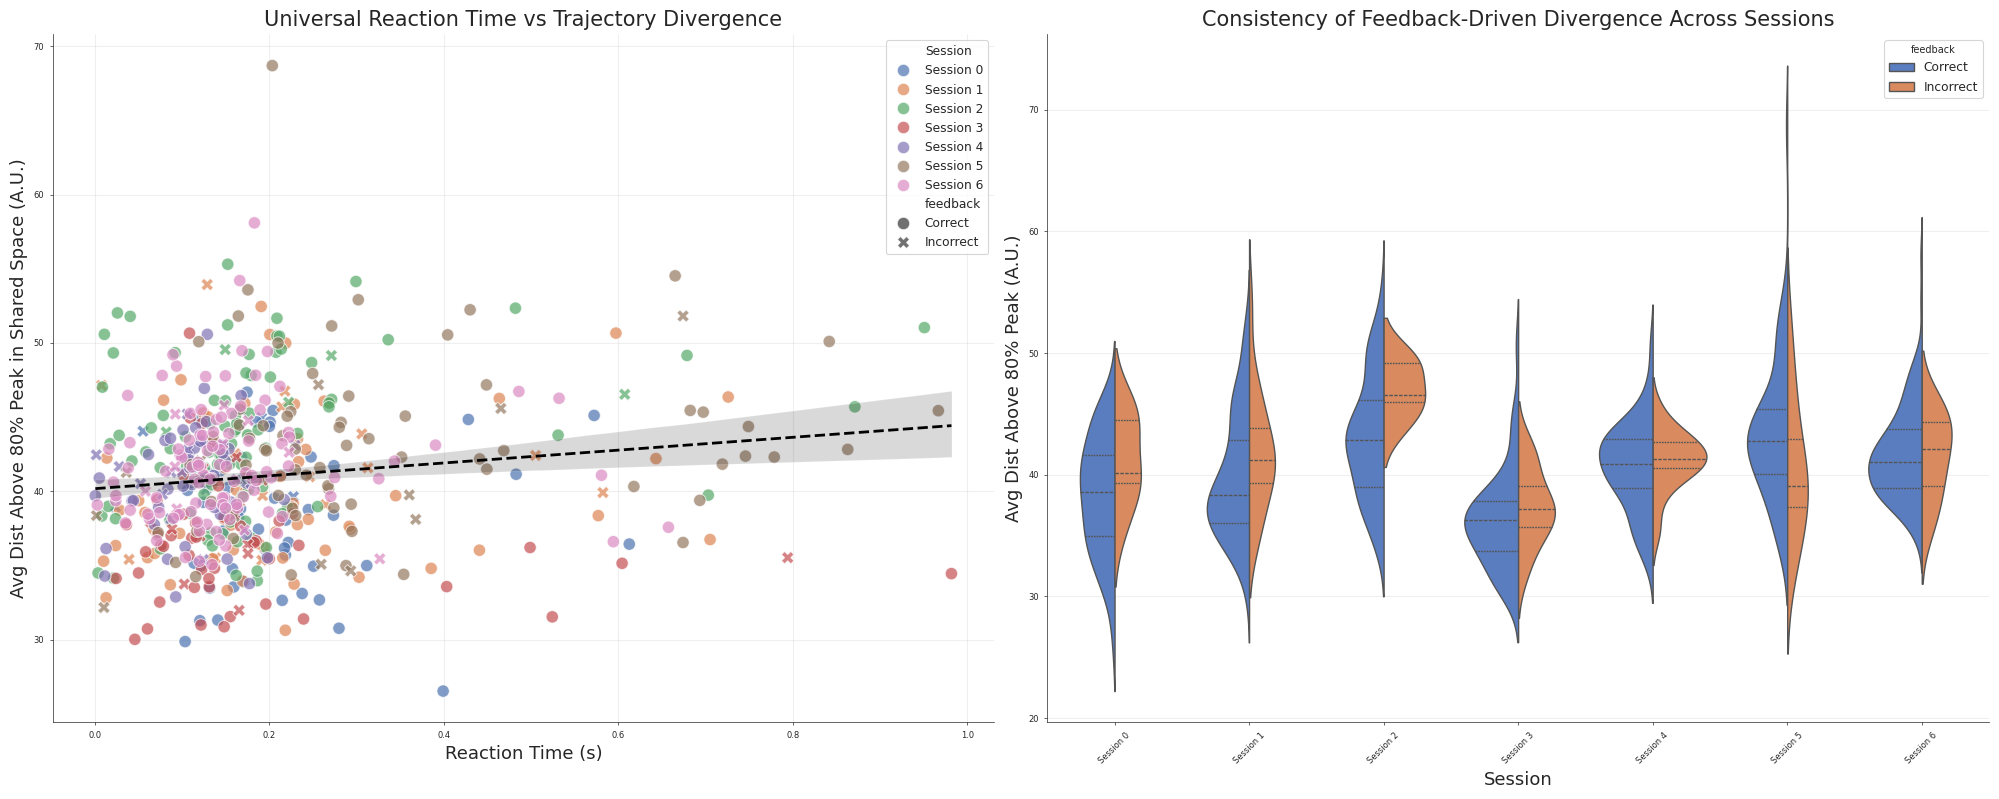

In [ ]:
# 3. Universal Reaction Time Correlation & Session Consistency
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Scatter plot with global trendline
sns.scatterplot(data=combined_df, x='RT', y='avg_dist_above_80', hue='Session', style='feedback', s=80, alpha=0.7, ax=axes[0])
sns.regplot(data=combined_df, x='RT', y='avg_dist_above_80', scatter=False, color='black', line_kws={'linestyle':'--', 'linewidth': 2}, ax=axes[0])
axes[0].set_title('Universal Reaction Time vs Trajectory Divergence', fontsize=15)
axes[0].set_xlabel('Reaction Time (s)', fontsize=13)
axes[0].set_ylabel('Avg Dist Above 80% Peak in Shared Space (A.U.)', fontsize=13)
axes[0].grid(True, alpha=0.3)

# Session-by-Session Consistency (Violin plot)
sns.violinplot(data=combined_df, x='Session', y='avg_dist_above_80', hue='feedback', split=True, inner="quart", palette='muted', ax=axes[1])
axes[1].set_title('Consistency of Feedback-Driven Divergence Across Sessions', fontsize=15)
axes[1].set_xlabel('Session', fontsize=13)
axes[1].set_ylabel('Avg Dist Above 80% Peak (A.U.)', fontsize=13)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

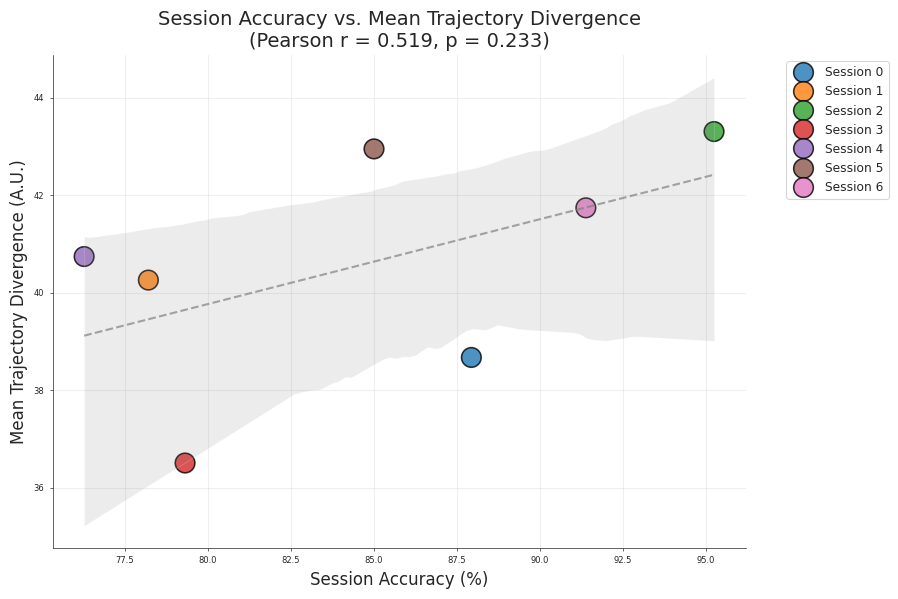

,Session,Mean_Divergence,Accuracy (%)
0,Session 2,43.308281,95.238095
1,Session 6,41.743786,91.379310
2,Session 0,38.673817,87.931034
3,Session 5,42.952129,85.000000
4,Session 3,36.508492,79.310345
5,Session 1,40.261040,78.205128
6,Session 4,40.744133,76.271186


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# 1. 提取每个session的平均分离度和正确率
session_stats = []
for session_name in combined_df['Session'].unique():
    sess_data = combined_df[combined_df['Session'] == session_name]

    # 计算平均分离度
    mean_div = sess_data['avg_dist_above_80'].mean()

    # 计算正确率 (正确 trial 占比)
    accuracy = (sess_data['feedback'] == 'Correct').mean() * 100

    session_stats.append({
        'Session': session_name,
        'Mean_Divergence': mean_div,
        'Accuracy (%)': accuracy
    })

session_stats_df = pd.DataFrame(session_stats)

# 2. 绘制散点图与回归线
plt.figure(figsize=(9, 6))

# 绘制散点，不同session不同颜色
sns.scatterplot(data=session_stats_df, x='Accuracy (%)', y='Mean_Divergence',
                hue='Session', s=200, palette='tab10', edgecolor='black', alpha=0.8)

# 添加回归线趋势
sns.regplot(data=session_stats_df, x='Accuracy (%)', y='Mean_Divergence',
            scatter=False, color='gray', line_kws={'linestyle': '--', 'alpha': 0.7})

# 计算皮尔逊相关系数
corr, pval = stats.pearsonr(session_stats_df['Accuracy (%)'], session_stats_df['Mean_Divergence'])

plt.title(f'Session Accuracy vs. Mean Trajectory Divergence\n(Pearson r = {corr:.3f}, p = {pval:.3f})', fontsize=14)
plt.xlabel('Session Accuracy (%)', fontsize=12)
plt.ylabel('Mean Trajectory Divergence (A.U.)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 显示计算结果表格
display(session_stats_df.sort_values('Accuracy (%)', ascending=False).reset_index(drop=True))


Loading wheel data and calculating wheel speed for strictly aligned trials...


(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/mainenlab/Subjects/ZM_1897/2019-12-02/001/alf/_ibl_wheel.timestamps.npy: 100%|██████████| 3.16M/3.16M [00:00<00:00, 3.33MB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/mainenlab/Subjects/ZM_1897/2019-12-02/001/alf/_ibl_wheel.position.npy: 100%|██████████| 3.16M/3.16M [00:00<00:00, 7.86MB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/cortexlab/Subjects/KS046/2020-12-04/001/alf/_ibl_wheel.timestamps.npy: 100%|██████████| 19.7M/19.7M [00:01<00:00, 14.8MB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/cortexlab/Subjects/KS046/2020-12-04/001/alf/_ibl_wheel.position.npy: 100%|██████████| 19.7M/19.7M [00:00<00:00, 32.9MB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/churchlandlab/Subjects/CSHL060/2020-03-11/004/alf/_ibl_wheel.timestamps.npy: 100%|██████████| 16.0M/16.0M [00:01<00:00, 12.2MB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/churchlandlab/

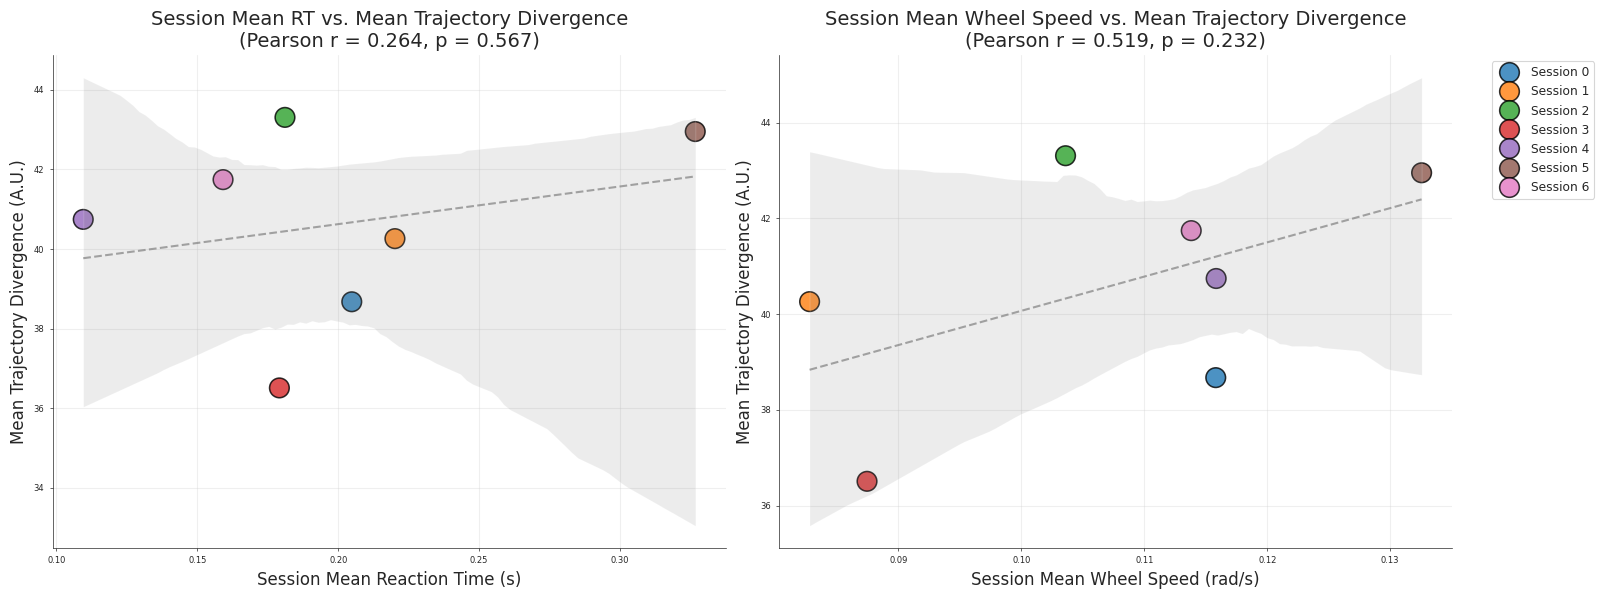

,Session,Mean_Divergence,Mean_RT,Mean_Wheel_Speed
0,Session 2,43.308281,0.181104,0.103592
1,Session 5,42.952129,0.326702,0.132563
2,Session 6,41.743786,0.159128,0.113818
3,Session 4,40.744133,0.109512,0.115846
4,Session 1,40.261040,0.220123,0.082767
5,Session 0,38.673817,0.204806,0.115814
6,Session 3,36.508492,0.179122,0.087441


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

print("Loading wheel data and calculating wheel speed for strictly aligned trials...")
# 为对齐的 trials 计算平均轮盘转速
combined_df['wheel_speed'] = np.nan

for eid in combined_df['eid'].unique():
    sess_mask = combined_df['eid'] == eid
    try:
        # 加载 wheel 数据
        wheel = one.load_object(eid, 'wheel', collection='alf')
        pos = wheel.position
        t = wheel.timestamps

        # 计算绝对角速度 (rad/s)
        dt = np.diff(t)
        dt[dt == 0] = 1e-6  # 避免除以零
        vel = np.abs(np.diff(pos) / dt)
        t_vel = t[:-1] + dt / 2
    except Exception as e:
        print(f"Failed to load wheel data for session {eid}: {e}")
        continue

    for idx, row in combined_df[sess_mask].iterrows():
        start_t = row['stimOn_times']
        end_t = row['firstMovement_times']

        if pd.isna(start_t) or pd.isna(end_t) or start_t >= end_t:
            continue

        # 截取 trial 期间的转速片段
        mask = (t_vel >= start_t) & (t_vel <= end_t)
        if np.sum(mask) > 0:
            combined_df.loc[idx, 'wheel_speed'] = np.mean(vel[mask])
        else:
            combined_df.loc[idx, 'wheel_speed'] = 0.0

# 1. 提取每个 session 的平均分离度、平均 RT 和平均轮盘转速
session_stats_extended = []
for session_name in combined_df['Session'].unique():
    sess_data = combined_df[combined_df['Session'] == session_name]

    mean_div = sess_data['avg_dist_above_80'].mean()
    mean_rt = sess_data['RT'].mean()
    mean_ws = sess_data['wheel_speed'].mean()

    session_stats_extended.append({
        'Session': session_name,
        'Mean_Divergence': mean_div,
        'Mean_RT': mean_rt,
        'Mean_Wheel_Speed': mean_ws
    })

session_stats_ext_df = pd.DataFrame(session_stats_extended)

# 2. 绘制相关性散点图与回归分析
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# A. Mean RT vs Mean Divergence
sns.scatterplot(data=session_stats_ext_df, x='Mean_RT', y='Mean_Divergence',
                hue='Session', s=200, palette='tab10', edgecolor='black', alpha=0.8, ax=axes[0], legend=False)
sns.regplot(data=session_stats_ext_df, x='Mean_RT', y='Mean_Divergence',
            scatter=False, color='gray', line_kws={'linestyle': '--', 'alpha': 0.7}, ax=axes[0])

valid_rt = session_stats_ext_df.dropna(subset=['Mean_RT', 'Mean_Divergence'])
if len(valid_rt) > 1:
    corr_rt, pval_rt = stats.pearsonr(valid_rt['Mean_RT'], valid_rt['Mean_Divergence'])
    axes[0].set_title(f'Session Mean RT vs. Mean Trajectory Divergence\n(Pearson r = {corr_rt:.3f}, p = {pval_rt:.3f})', fontsize=14)
axes[0].set_xlabel('Session Mean Reaction Time (s)', fontsize=12)
axes[0].set_ylabel('Mean Trajectory Divergence (A.U.)', fontsize=12)
axes[0].grid(True, alpha=0.3)

# B. Mean Wheel Speed vs Mean Divergence
sns.scatterplot(data=session_stats_ext_df, x='Mean_Wheel_Speed', y='Mean_Divergence',
                hue='Session', s=200, palette='tab10', edgecolor='black', alpha=0.8, ax=axes[1])
sns.regplot(data=session_stats_ext_df, x='Mean_Wheel_Speed', y='Mean_Divergence',
            scatter=False, color='gray', line_kws={'linestyle': '--', 'alpha': 0.7}, ax=axes[1])

valid_ws = session_stats_ext_df.dropna(subset=['Mean_Wheel_Speed', 'Mean_Divergence'])
if len(valid_ws) > 1:
    corr_ws, pval_ws = stats.pearsonr(valid_ws['Mean_Wheel_Speed'], valid_ws['Mean_Divergence'])
    axes[1].set_title(f'Session Mean Wheel Speed vs. Mean Trajectory Divergence\n(Pearson r = {corr_ws:.3f}, p = {pval_ws:.3f})', fontsize=14)
axes[1].set_xlabel('Session Mean Wheel Speed (rad/s)', fontsize=12)
axes[1].set_ylabel('Mean Trajectory Divergence (A.U.)', fontsize=12)
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

display(session_stats_ext_df.sort_values('Mean_Divergence', ascending=False).reset_index(drop=True))

In [ ]:
import numpy as np

# Calculate total trials in the test dataloaders strictly used by the SPARKS model
total_test_dl_trials = sum([len(multi_dl_dict[sid]['test'].dataset) for sid in multi_dl_dict])

# Calculate total trials collected in combined_df for the behavioral analysis
total_combined_df_trials = len(combined_df)

print("=== Trial Consistency Check ===")
print(f"Total trials strictly filtered for Model Test DataLoaders: {total_test_dl_trials}")
print(f"Total trials in combined_df for Behavioral Analysis: {total_combined_df_trials}")

if total_test_dl_trials == total_combined_df_trials:
    print("\n✅ SUCCESS: The trial counts match perfectly. The analysis is strictly aligned with the previous valid test trials.")
else:
    print("\n❌ WARNING: Trial counts DO NOT match!")
    print("This indicates a potential misalignment in how trials were split or concatenated during the divergence metric extraction.")

    # Further breakdown to find where the mismatch happens
    print("\nBreakdown per session:")
    for sid in multi_dl_dict:
        dl_count = len(multi_dl_dict[sid]['test'].dataset)
        df_count = len(combined_df[combined_df['Session'] == f'Session {sid}'])
        status = "Match" if dl_count == df_count else "Mismatch"
        print(f"  Session {sid}: DataLoader = {dl_count}, DataFrame = {df_count} -> {status}")

=== Trial Consistency Check ===
Total trials strictly filtered for Model Test DataLoaders: 554
Total trials in combined_df for Behavioral Analysis: 554

✅ SUCCESS: The trial counts match perfectly. The analysis is strictly aligned with the previous valid test trials.


# **Demo-1**

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import os
from scipy.io import loadmat
from scipy.signal import correlate, correlation_lags
import torch
import tqdm

from sparks.models.sparks import SPARKS
from sparks.models.dataclasses import HebbianAttentionConfig, AttentionConfig
from sparks.data.mec import make_mec_ca_dataset

In [ ]:
data_path = os.path.join(os.getcwd(), 'calcium_activity_matrix_60584_session17.mat') # path to where the data is located.
# by default where the notebook is located, if the data isn't found it will be downloaded from
# https://github.com/soledadgcogno/Ultraslow-oscillatory-sequences/blob/main/Selection%20of%20codes/calcium_activity_matrix_60584_session17.mat
if not os.path.exists(data_path):
    import urllib.request
    urllib.request.urlretrieve("https://github.com/soledadgcogno/Ultraslow-oscillatory-sequences/raw/main/Selection%20of%20codes/calcium_activity_matrix_60584_session17.mat",
                               "calcium_activity_matrix_60584_session17.mat")
session_data = loadmat(data_path) # spikes saved in a matlab sparse matrix
spikes_idxs = session_data['spikes_d_s'].nonzero() # obtain the spike indices
spikes = np.zeros(session_data['spikes_d_s'].shape) # reconstruct the histogram
spikes[spikes_idxs[0], spikes_idxs[1]] = 1
fs_120 = 7.73 # sampling rate

Text(0, 0.5, 'Neurons')

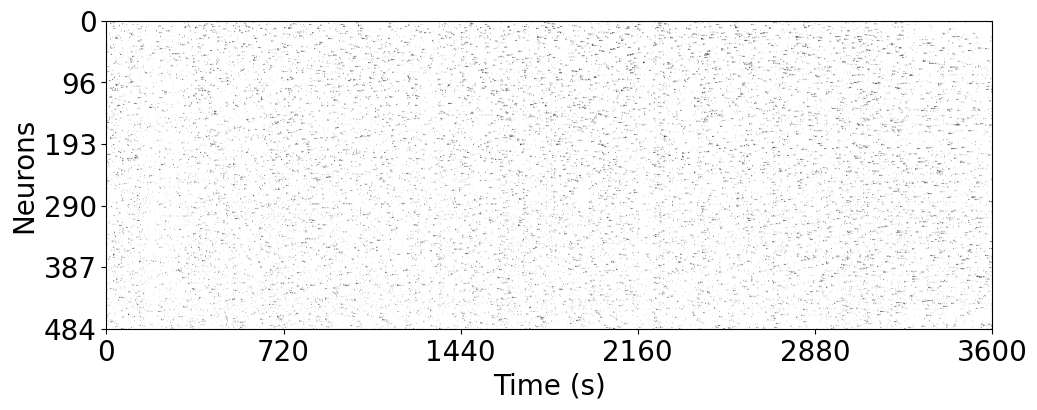

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12, 4))
ax.imshow(np.repeat(spikes, 20, 0), cmap='Greys')

T = spikes.shape[-1] / fs_120
ax.set_xticks(np.arange(0, int(spikes.shape[-1] + spikes.shape[-1] / 5), spikes.shape[-1] / 5))
ax.set_xticklabels(np.arange(0, T + T / 5, T / 5).astype(int), fontsize=20)
ax.set_xlabel('Time (s)', fontsize=20)

ax.set_yticks(np.arange(0, 20 * spikes.shape[0] + 20 * spikes.shape[0] / 5,
                        20 * spikes.shape[0] / 5))
ax.set_yticklabels(np.arange(0, spikes.shape[0] + spikes.shape[0] / 5,
                             spikes.shape[0] / 5).astype(int), fontsize=20)
ax.set_ylabel('Neurons', fontsize=20)

In [ ]:
start_stop_times_train = np.array([(600 + i * 500, 600 + (i + 1) * 500) for i in range(5)])
start_stop_times_test = np.array([[3100, 3600]])
data_path = os.path.join(os.getcwd(), 'calcium_activity_matrix_60584_session17.mat')
ds = 4

train_dataset, train_dl = make_mec_ca_dataset(data_path,
                                                start_stop_times=start_stop_times_train,
                                                downsampling_factor=ds,
                                                batch_size=1,
                                                train=True)

test_dataset, test_dl = make_mec_ca_dataset(data_path,
                                            start_stop_times=start_stop_times_test,
                                            downsampling_factor=ds,
                                            batch_size=1,
                                            train=False)

In [ ]:
embed_dim = 128  # attention embedding dimension (reduced again for stability)
latent_dim = 64  # latent dimension (reduced again for stability)
tau_s = 10  # STDP decay period (reduced for stability)
tau_p = 1  # past time-steps window
tau_f = 1  # future time-steps window
n_layers = 0  # number of conventional attention layers
n_heads = 1  # number of attention heads
input_size = len(train_dataset.spikes)
beta = 0.01  # KDL regularisation strength (increased for stability)
fs = fs_120 / 4 # downsampled sampling rate as in the original MEC paper

# if a gpu is available
if torch.cuda.is_available():
    device = torch.device('cuda')
# If on a recent macbook
elif torch.backends.mps.is_available():
    device = torch.device('mps:0')
else:
    device = torch.device('cpu')

hebbian_config = HebbianAttentionConfig(tau_s=tau_s, dt=1/fs) # Hebbian attention config
attention_config = AttentionConfig() # conventional attention config
sparks = SPARKS(n_neurons_per_session=train_dataset.spikes.shape[0],
                embed_dim=embed_dim,
                latent_dim=latent_dim,
                tau_p=tau_p,
                tau_f=tau_f,
                hebbian_config=hebbian_config,
                attention_config=attention_config,
                output_dim_per_session=train_dataset.spikes.shape[0],
                device=device)

lr = 0.001 # Reduced learning rate for stability
optimizer = torch.optim.Adam(sparks.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.5)
loss_fn = torch.nn.BCEWithLogitsLoss()

In [ ]:
from sparks.utils.train import train
from sparks.utils.test import test

test_period = 1
n_epochs = 1  # Number of training epochs

for epoch in tqdm.tqdm(range(n_epochs)):
    train(sparks=sparks,
            train_dls=[train_dl],
            loss_fn=loss_fn,
            optimizer=optimizer,
            beta=beta,
            device=device,
            unsupervised=True)
    scheduler.step()

    if (epoch + 1) % test_period == 0:
        test_loss, encoder_outputs, decoder_outputs = test(sparks=sparks,
                                                            test_dls=[test_dl],
                                                            loss_fn=loss_fn,
                                                            act=torch.sigmoid,
                                                            unsupervised=True)

        print(f"Epoch {epoch + 1}/{n_epochs}, Test Loss: {test_loss:.4f}")

  0%|          | 0/1 [00:04<?, ?it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 2.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 1.81 MiB is free. Including non-PyTorch memory, this process has 14.56 GiB memory in use. Of the allocated memory 13.09 GiB is allocated by PyTorch, and 1.34 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

In [ ]:
for epoch in tqdm.tqdm(range(n_epochs)):
    train_iterator = iter(train_dl)
    sparks.train()

    for inputs, _ in train_iterator:
        ### Initialize training for a batch
        inputs = inputs.float()
        T = inputs.shape[-1]   # Number of time-steps in the recording
        sparks.encoder.zero_()  # Resets the attention layer

        # Initialize the outputs of the encoder as zeroes to match the input dimension of the decoder in the first time-steps
        encoder_outputs = torch.zeros([len(inputs), latent_dim, tau_p]).to(device)
        loss = 0

        for t in range(T - tau_f + 1):
            encoder_outputs, decoder_outputs, mu, logvar = sparks(inputs[..., t].to(device), encoder_outputs=encoder_outputs, session_id=0)  # pass the input through the SPARKS model
            loss += (loss_fn(decoder_outputs,
                            inputs[..., t:t + tau_f].reshape(inputs.shape[0], -1).to(device))
                     - beta * 0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())) # Compute the current loss

        # Apply SGD at the end of the presentation of the batch ('batch training')
        loss.backward()
        optimizer.step()
        sparks.zero_grad()

100%|██████████| 1/1 [00:21<00:00, 21.80s/it]


In [ ]:
with torch.no_grad():
    test_iterator = iter(test_dl)
    sparks.eval()

    encoder_outputs = torch.Tensor().to(device)
    decoder_outputs = torch.Tensor().to(device)
    test_targets = torch.Tensor()
    test_loss = 0

    for inputs, _ in tqdm.tqdm(test_iterator):
        inputs = inputs.float()
        T = inputs.shape[-1]
        sparks.encoder.zero_()
        encoder_outputs_batch = torch.zeros([len(inputs), latent_dim, tau_p]).to(device)
        decoder_outputs_batch = torch.Tensor().to(device)

        for t in range(T - tau_f + 1):
            encoder_outputs_batch, dec_outputs, mu, logvar = sparks(inputs[..., t].to(device), encoder_outputs=encoder_outputs_batch, session_id=0)  # pass the input through the SPARKS model
            decoder_outputs_batch = torch.cat((decoder_outputs_batch,
                                               dec_outputs.unsqueeze(2)), dim=-1)

        encoder_outputs = torch.cat((encoder_outputs, encoder_outputs_batch), dim=0)
        decoder_outputs = torch.cat((decoder_outputs, decoder_outputs_batch), dim=0)

100%|██████████| 1/1 [00:01<00:00,  1.36s/it]


In [ ]:
res_path = os.path.join(os.getcwd(), 'results/mec_results') # path to where the data is located.
# by default where the notebook is located, if the data isn't found it will be downloaded from
# https://github.com/Iacaruso-lab/sparks-figures/results/mec_resuults

if not os.path.exists(os.path.join(res_path, 'test_enc_outputs_best.npy')):
    # create the directory
    if not os.path.exists(res_path):
        os.makedirs(res_path)
    # download the data
    import urllib.request
    urllib.request.urlretrieve("https://github.com/Iacaruso-lab/sparks-figures/raw/refs/heads/main/results/mec_results/test_enc_outputs_best.npy",
                               os.path.join(res_path, 'test_enc_outputs_best.npy'))

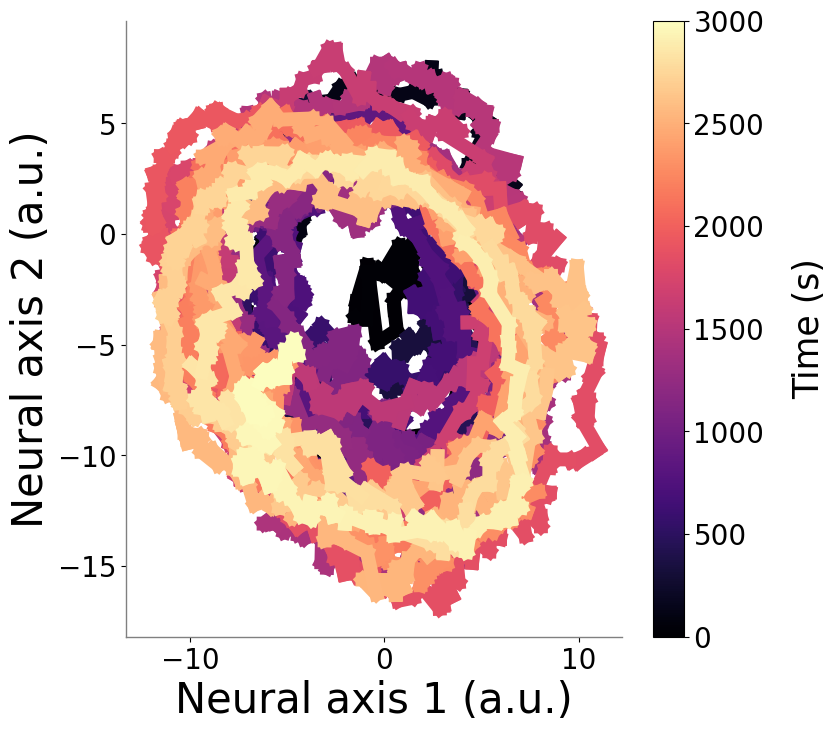

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

test_encs_best = np.load(os.path.join(res_path, 'test_enc_outputs_best.npy'))[0, :, tau_p:]

cmap = plt.get_cmap('magma')
colors = cmap(np.linspace(0, 1, test_encs_best.shape[-1]))
norm = mpl.colors.Normalize(vmin=0, vmax=test_encs_best.shape[-1] / fs)

for t in range(test_encs_best.shape[-1] - 1):
    ax.plot([test_encs_best[1, t], test_encs_best[1, t+1]], [test_encs_best[0, t], test_encs_best[0, t+1]], color=colors[t], linewidth=10)

ax.grid(False)

cbar = plt.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
cbar.ax.tick_params(labelsize=20)
cbar.ax.set_ylabel('Time (s)', fontsize=25, labelpad=20)
cbar.ax.set_yticks(np.arange(0, 3500, 500))

ax.tick_params(axis='both', which='major', labelsize=20)
ax.set_xlabel('Neural axis 1 (a.u.)', fontsize=30)
ax.set_ylabel('Neural axis 2 (a.u.)', fontsize=30)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines["left"].set_color('grey')
ax.spines["bottom"].set_color('grey')
ax.spines["left"].set_linewidth(1)

ax.spines["bottom"].set_linewidth(1)

In [ ]:
import plotly.graph_objects as go
import numpy as np
import os

# Define path and load the data to fix the NameError
res_path = os.path.join(os.getcwd(), 'results/mec_results')
test_encs_best = np.load(os.path.join(res_path, 'test_enc_outputs_best.npy'))[0, :, tau_p:]

# Extract the first 3 dimensions
x = test_encs_best[0, :]
y = test_encs_best[1, :]
z = test_encs_best[2, :]

# Create a time array for the color scale
time_array = np.arange(test_encs_best.shape[-1])

fig = go.Figure(data=[go.Scatter3d(
    x=x, y=y, z=z,
    mode='lines',
    line=dict(
        color=time_array,
        colorscale='magma',
        width=4
    ),
    name='Trajectory'
)])

# Mark the start and end points
fig.add_trace(go.Scatter3d(
    x=[x[0]], y=[y[0]], z=[z[0]],
    mode='markers',
    marker=dict(size=8, color='green', symbol='diamond'),
    name='Start'
))
fig.add_trace(go.Scatter3d(
    x=[x[-1]], y=[y[-1]], z=[z[-1]],
    mode='markers',
    marker=dict(size=8, color='red', symbol='square'),
    name='End'
))

fig.update_layout(
    title='Demo-1: 3D Latent Trajectory (First 3 Dimensions)',
    scene=dict(
        xaxis_title='Neural axis 1 (a.u.)',
        yaxis_title='Neural axis 2 (a.u.)',
        zaxis_title='Neural axis 3 (a.u.)'
    ),
    width=900,
    height=700,
    margin=dict(l=0, r=0, b=0, t=50)
)

fig.show()

FileNotFoundError: [Errno 2] No such file or directory: '/content/results/mec_results/test_enc_outputs_best.npy'

In [ ]:
import math

def calculate_angle(segment1, segment2):
    """
    Calculate the angle in degrees between two segments
    Args:
        segment1:
        segment2:

    Returns:

    """
    # Convert the segments into vectors
    vec1 = (segment1[1][0] - segment1[0][0], segment1[1][1] - segment1[0][1])
    vec2 = (segment2[1][0] - segment2[0][0], segment2[1][1] - segment2[0][1])

    # Calculate the dot product
    dot_product = vec1[0] * vec2[0] + vec1[1] * vec2[1]

    # Calculate the magnitudes of the vectors
    mag_vec1 = math.sqrt(vec1[0]**2 + vec1[1]**2)
    mag_vec2 = math.sqrt(vec2[0]**2 + vec2[1]**2)

    # Calculate the cosine of the angle using the dot product and the magnitudes
    cos_angle = dot_product / (mag_vec1 * mag_vec2)

    # Use the arccos function to find the angle in radians, then convert it to degrees
    angle = math.degrees(math.acos(cos_angle))

    return angle

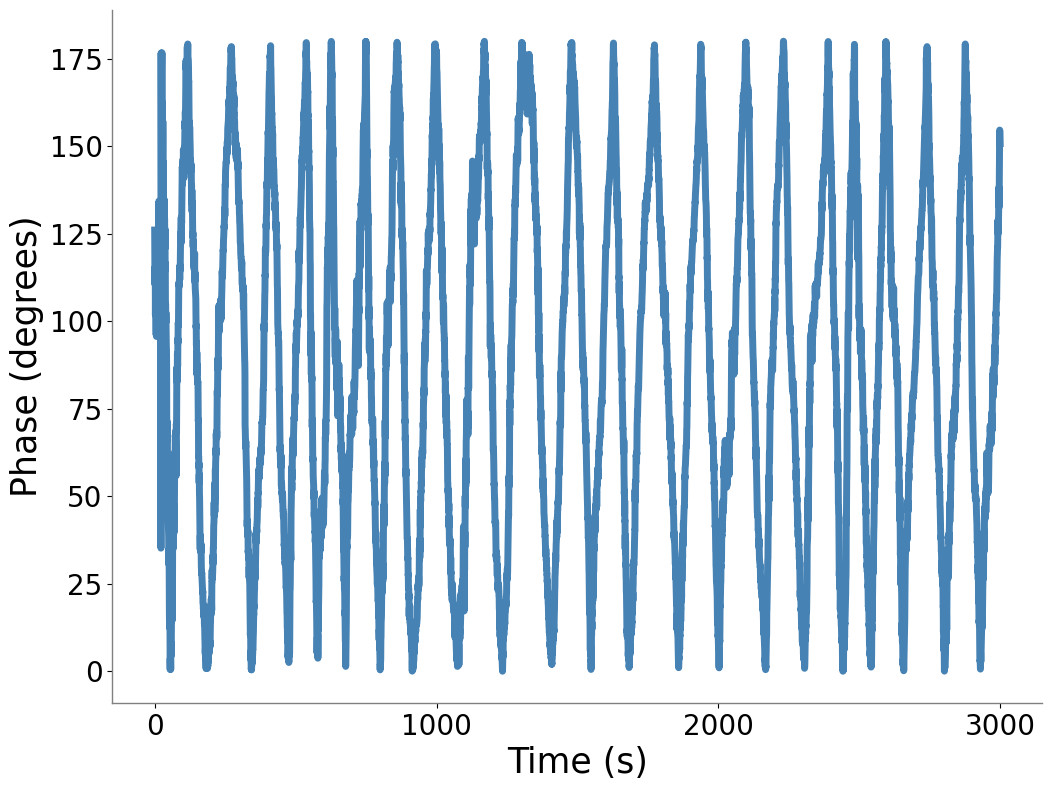

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12, 9))

phi_t = []
window = 200

for t in range(test_encs_best.shape[-1]):
    segment1 = (test_encs_best[..., t], [test_encs_best[0, t] + 10, test_encs_best[1, t]])
    segment2 = (test_encs_best[..., t], np.mean(test_encs_best[..., max(0, t-window):max(t, window)], axis=-1))
    phi_t.append(calculate_angle(segment1, segment2))
phi_t = np.array(phi_t)

ax.plot(phi_t, linewidth=5, color='steelblue')
ax.set_ylabel('Phase (degrees)', fontsize=25)
ax.set_xlabel('Time (s)', fontsize=25)
ax.grid(False)
T = phi_t.shape[-1] / fs
ax.set_xticks(np.arange(0, int(phi_t.shape[-1] + phi_t.shape[-1] / 3), phi_t.shape[-1] / 3))
ax.set_xticklabels(np.arange(0, T + T / 3, T / 3).astype(int), fontsize=20)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines["left"].set_color('grey')
ax.spines["bottom"].set_color('grey')
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)
ax.tick_params(axis='both', which='major', labelsize=20, left=True, bottom=True)

In [ ]:
def sort_with_sparks(spikes, phase, maxlag):
    """"

    Sorts the spikes based on their correlation with the phase signal
    Args:
        spikes: ndarray of shape (n_neurons, n_timepoints)
        phase: phase signal of shape (n_timepoints,)
        maxlag: maximum lag to consider

        Returns: ndarray of shape (n_neurons,) with the indices of the sorted neurons

    """
    corr_vec = np.zeros(spikes.shape[0])
    for i in range(spikes.shape[0]):
        val = correlate(spikes[i], phase, mode='full')
        time = correlation_lags(len(spikes[i]), len(phase), mode='full')
        idx = np.argmax(val[np.abs(time) < maxlag])
        v = val[np.abs(time) < maxlag][idx]
        t = time[np.abs(time) < maxlag][idx]

        if t >= 0:
            corr_vec[i] = v
        else:
            corr_vec[i] = -v

    return np.argsort(corr_vec)

def spikes_downsample(spikes, downsampling_factor, mode='mean'):
    """
    Downsamples the spikes by binning them

    Args:
        spikes:  ndarray of shape (n_neurons, n_timepoints)
        downsampling_factor:  int, factor by which to downsample
        mode: 'mean' or 'max', whether to take the mean or the max in each bin

    Returns: ndarray of shape (n_neurons, n_timepoints // downsampling_factor)
    """
    bins = np.arange(0, spikes.shape[-1] + downsampling_factor, downsampling_factor)
    spike_times = spikes * np.arange(spikes.shape[-1])[None, :]
    if mode == 'mean':
        return np.vstack([(np.histogram(spike_times_unit[spike_times_unit != 0], bins)[0] / downsampling_factor)[None, :] for spike_times_unit in spike_times]).astype(float)
    elif mode == 'max':
        return np.vstack([(np.histogram(spike_times_unit[spike_times_unit != 0], bins)[0] > 0)[None, :] for spike_times_unit in spike_times]).astype(float)

Text(0.5, 0, 'Time (s)')

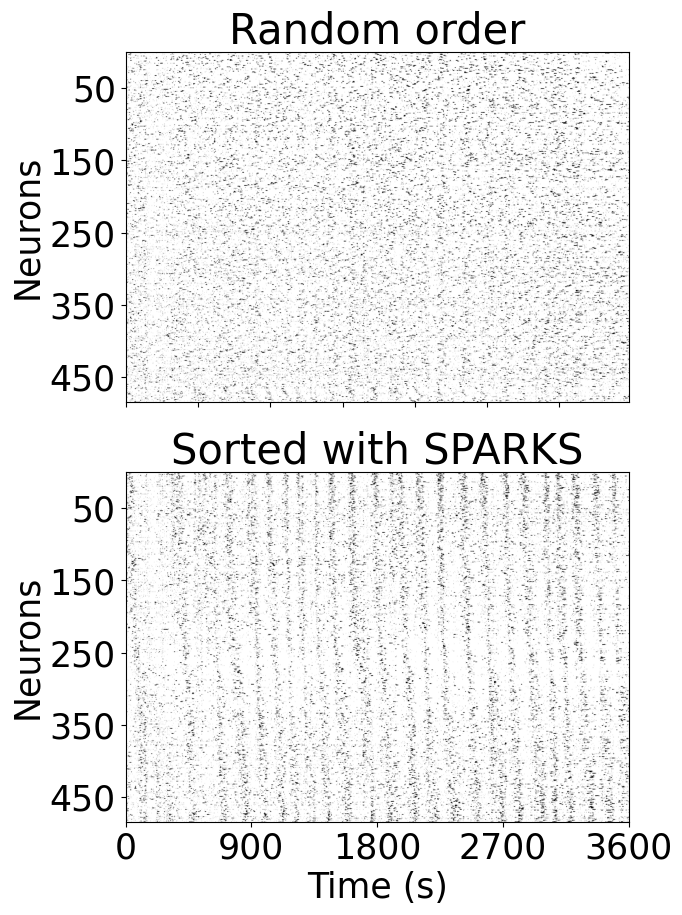

In [ ]:
from scipy.signal import welch

fig, axs = plt.subplots(2, 1, figsize=(20, 10))
window_size = 8192 // 4 # 17.6 min
overlap = window_size // 2  # 50% overlap
plt.rcParams['svg.fonttype'] = 'none'

downsampling_factor = 4
fs = fs_120 / downsampling_factor
spikes_downsampled = spikes_downsample(spikes, downsampling_factor, mode='max')

repeats = 10
axs[0].imshow(np.repeat(spikes_downsampled, repeats, 0), cmap='Greys')
axs[0].set_title('Random order', fontsize=30)
axs[0].grid(False)

maxlag = 10
sorting_sparks = sort_with_sparks(spikes_downsampled[:, int(600 * fs):], phi_t, maxlag * 2)
axs[1].imshow(np.flip(np.repeat(spikes_downsampled[sorting_sparks], repeats, 0), axis=0), cmap='Greys')
axs[1].set_title('Sorted with SPARKS', fontsize=30)
axs[1].grid(False)

for ax in axs:
    ax.grid(False)
    ax.set_yticks(np.arange(50 * 10, 550 * 10, 100 * 10))
    ax.set_yticklabels(np.arange(50, 550, 100), fontsize=25)
    ax.set_ylabel('Neurons', fontsize=25)


T = spikes_downsampled.shape[-1] / fs
axs[0].tick_params(axis='x', which='major', labelbottom=False)
axs[1].set_xticks(np.arange(0, int(spikes_downsampled.shape[-1] + spikes_downsampled.shape[-1] / 4), spikes_downsampled.shape[-1] / 4))
axs[1].set_xticklabels(np.arange(0, T + T / 4, T / 4).astype(int), fontsize=25)
axs[1].set_xlabel('Time (s)', fontsize=25)

# **Demo-2**

In [ ]:
import os

import numpy as np
import matplotlib.pyplot as plt
import torch
from typing import List
import tqdm
from sklearn.metrics import r2_score


from sparks.data.nlb.nwb_interface import NWBDataset
from sparks.data.base import BaseDataset
from sparks.models.sparks import SPARKS
from sparks.models.dataclasses import HebbianAttentionConfig, AttentionConfig
from sparks.utils.train import train
from sparks.utils.test import test

In [ ]:
import os
!pip install dandi

# Create directory
os.makedirs('/content/000127/', exist_ok=True)

# Updated download command: Removed unsupported filter parameter
# This will download the entire mc_maze dandiset, or you can specify a more specific URL
!dandi download https://dandiarchive.org/dandiset/000127/draft -o /content/000127/

PATH                                                   SIZE    DONE    DONE% CHECKSUM STATUS    MESSAGE          
000127/dandiset.yaml                                                                  skipped   no change        
000127/sub-Han/sub-Han_desc-test_ecephys.nwb                                          error     FileExistsError  
000127/sub-Han/sub-Han_desc-train_behavior+ecephys.nwb                                error     FileExistsError  
Summary:                                               0 Bytes 0 Bytes                1 skipped 1 no change      
                                                       +1.8 GB 0.00%                  2 error   2 FileExistsError
2026-05-30 20:28:28,386 [   ERROR] Encountered 2 errors while downloading. The first error: {'status': 'error', 'message': 'FileExistsError', 'path': '000127/sub-Han/sub-Han_desc-train_behavior+ecephys.nwb'}
2026-05-30 20:28:28,386 [    INFO] Logs saved in /root/.local/state/dandi-cli/log/2026.05.30-20.28.21Z-22450

In [ ]:
try:
    # Use glob to search for files in the path to ensure NWBDataset finds the files
    dataset = NWBDataset(dataset_path, "*train*", split_heldout=False)
    print(f"Successfully loaded dataset from {dataset_path}")

    dataset.data['hand_pos'] = (dataset.data['hand_pos'] - dataset.data['hand_pos'].min()) / (dataset.data['hand_pos'].max() - dataset.data['hand_pos'].min())
    trial_mask = (~dataset.trial_info.ctr_hold_bump) & (dataset.trial_info.split != 'none')
    unique_angles = [0.0, 45.0, 90.0, 135.0, 180.0, 225.0, 270.0, 315.0]

    lag = 40
    align_range = (-100, 500)
    align_field = 'move_onset_time'
    lag_align_range = (align_range[0] + lag, align_range[1] + lag)

    align_data_train = [dataset.make_trial_data(align_field=align_field, align_range=align_range, ignored_trials=~(trial_mask & (dataset.trial_info['cond_dir'] == angle) & (dataset.trial_info['split'] == 'train'))) for angle in unique_angles]
    align_data_test = [dataset.make_trial_data(align_field=align_field, align_range=align_range, ignored_trials=~(trial_mask & (dataset.trial_info['cond_dir'] == angle) & (dataset.trial_info['split'] == 'val'))) for angle in unique_angles]
    lag_align_data_train = [dataset.make_trial_data(align_field=align_field, align_range=lag_align_range, ignored_trials=~(trial_mask & (dataset.trial_info['cond_dir'] == angle) & (dataset.trial_info['split'] == 'train'))) for angle in unique_angles]
    lag_align_data_test = [dataset.make_trial_data(align_field=align_field, align_range=lag_align_range, ignored_trials=~(trial_mask & (dataset.trial_info['cond_dir'] == angle) & (dataset.trial_info['split'] == 'val'))) for angle in unique_angles]
except Exception as e:
    print(f"Loading failed: {e}")

Successfully loaded dataset from /content/000127/000127/sub-Han/


In [ ]:
dataset_path = "/content/000127/000127/sub-Han/"  # Updated to the correct local path
dataset = NWBDataset(dataset_path, "*train", split_heldout=False) # NWB dataset

# Normalize the target between [0, 1] if it's not 'direction' (which is categorical)
dataset.data['hand_pos'] = (dataset.data['hand_pos'] - dataset.data['hand_pos'].min()) / (dataset.data['hand_pos'].max() - dataset.data['hand_pos'].min())

trial_mask = (~dataset.trial_info.ctr_hold_bump) & (dataset.trial_info.split != 'none') # Keep only active trials
unique_angles = [0.0, 45.0, 90.0, 135.0, 180.0, 225.0, 270.0, 315.0] # Targets angles

lag = 40  # Assumed lag between neural data and behaviour, taken from the NLB notebook
align_range = (-100, 500)  # 100 ms before to 500 ms after the stimulus onset
align_field = 'move_onset_time'

lag_align_range = (align_range[0] + lag, align_range[1] + lag)


# Obtain train/test data for each angle
align_data_train = [dataset.make_trial_data(align_field=align_field, align_range=align_range,
                                            ignored_trials=~(trial_mask
                                                                & (dataset.trial_info['cond_dir'] == angle)
                                                                & (dataset.trial_info['split'] == 'train')))
                                            for angle in unique_angles]
align_data_test = [dataset.make_trial_data(align_field=align_field, align_range=align_range,
                                            ignored_trials=~(trial_mask
                                                            & (dataset.trial_info['cond_dir'] == angle)
                                                            & (dataset.trial_info['split'] == 'val')))
                                            for angle in unique_angles]

# Obtain corresponding data for the lagged alignment
lag_align_data_train = [dataset.make_trial_data(align_field=align_field, align_range=lag_align_range,
                                                ignored_trials=~(trial_mask
                                                                    & (dataset.trial_info['cond_dir'] == angle)
                                                                    & (dataset.trial_info['split'] == 'train')))
                                                for angle in unique_angles]
lag_align_data_test = [dataset.make_trial_data(align_field=align_field, align_range=lag_align_range,
                                                ignored_trials=~(trial_mask
                                                                & (dataset.trial_info['cond_dir'] == angle)
                                                                & (dataset.trial_info['split'] == 'val')))
                                                for angle in unique_angles]

In [ ]:
class MonkeyReachingDataset(BaseDataset):
    def __init__(self,
                 align_data: List,
                 lag_align_data: List) -> None:

        """
        Abstract Dataset for spike encoding

        Parameters
        --------------------------------------

        :param: align_data : List
        list of aligned data for each angle, each element is a DataFrame with 'spikes' and target keys
        :param: lag_align_data : List
        list of lagged aligned data for each angle, each element is a DataFrame with 'spikes' and target keys
        :param: y_keys : str
        target key to use, e.g. 'hand_pos', 'hand_vel', 'force', 'muscle_len', 'direction', 'joint_ang'
        :param: mode : str
        mode of the dataset, e.g. 'prediction', 'unsupervised', 'spikes_pred'
        :param: smooth : bool
        whether to smooth spikes into FRs
        """

        super(MonkeyReachingDataset).__init__()

        self.x_trial_data = np.vstack([align_data[i]['spikes'].to_numpy().reshape([-1, 600, 65])
                                       for i in range(len(align_data))]).transpose(0, 2, 1)

        y_dim = lag_align_data[0]['hand_pos'].to_numpy().shape[-1]
        y_trial_data = np.vstack([lag_align_data[i]['hand_pos'].to_numpy().reshape([-1, 600, y_dim])
                                    for i in range(len(lag_align_data))]).transpose([0, 2, 1])

        self.y_trial_data = y_trial_data
        self.y_shape = self.y_trial_data.shape[-2]
        self.x_shape = self.x_trial_data.shape[-2]

    def __len__(self):
        return len(self.x_trial_data)

    def __getitem__(self, index: int):
        """
        :param: index: int
         Index
        :return: tuple: (data, target) where target is index of the target class.
        """

        features = torch.tensor(self.x_trial_data[index]).float()
        target = torch.tensor(self.y_trial_data[index]).float()

        return features, target


def get_accuracy(decoder_outputs, targets):
    """"
    Compute accuracy of the model on the test set
    :param: decoder_outputs : torch.Tensor
    model outputs on the test set
    :param: targets : np.ndarray
    ground truth targets on the test dataset
    :return: test_acc : float
    R^2 score of the model on the test set
    """
    preds = decoder_outputs[..., 100:].cpu().numpy().reshape([targets.shape[0], targets.shape[1],
                                                                targets.shape[2] - 100, -1]).transpose(0, 2, 1, 3)
    test_acc = r2_score(targets[..., 100:].transpose(0, 2, 1).reshape(-1, targets.shape[-2]),
                        preds[..., 0].reshape(-1, targets.shape[-2]), multioutput='variance_weighted')

    return test_acc

In [ ]:
batch_size = 256 # minibatch size to perform SGD
train_dataset = MonkeyReachingDataset(align_data_train, lag_align_data_train)
train_dl = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = MonkeyReachingDataset(align_data_test, lag_align_data_test)
test_dl = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
# if a gpu is available
if torch.cuda.is_available():
    device = torch.device('cuda')
# If on a recent macbook
elif torch.backends.mps.is_available():
    device = torch.device('mps:0')
else:
    device = torch.device('cpu')

# Model parameters
tau_f = 1 # Number of future time-steps to predict
tau_p = 10 # Number of past time-steps to use
embed_dim = 32  # attention embedding dimension
latent_dim = 2 # Latent dimension
dt = 0.001 # dataset time bin width
tau_s = 0.5  # STDP decay period (in seconds)
beta = 0.001  # KDL regularisation strength

hebbian_config = HebbianAttentionConfig(tau_s=tau_s, dt=dt) # Hebbian attention config
attention_config = AttentionConfig() # standard attention config
sparks = SPARKS(n_neurons_per_session=train_dataset.x_shape,
                embed_dim=embed_dim,
                latent_dim=latent_dim,
                tau_p=tau_p,
                tau_f=tau_f,
                hebbian_config=hebbian_config,
                attention_config=attention_config,
                output_dim_per_session=train_dataset.y_shape,
                device=device)

# Optimizer and loss function
optimizer = torch.optim.Adam(sparks.parameters(), lr=0.001)
loss_fn = torch.nn.BCEWithLogitsLoss()

In [ ]:
test_period = 10
n_epochs = 150  # Number of training epochs

pbar = tqdm.tqdm(range(n_epochs))
for epoch in pbar:
    train(sparks=sparks,
            train_dls=[train_dl],
            loss_fn=loss_fn,
            optimizer=optimizer,
            beta=beta,
            device=device)

    if (epoch + 1) % test_period == 0:
        test_loss, encoder_outputs, decoder_outputs = test(sparks=sparks,
                                                            test_dls=[test_dl],
                                                            loss_fn=loss_fn,
                                                            act=torch.sigmoid)
        test_acc = get_accuracy(decoder_outputs, test_dataset.y_trial_data)
        pbar.set_description("Epoch %d, acc: %.3f" % (epoch, test_acc))

encoder_outputs = encoder_outputs.cpu().numpy()

Epoch 149, acc: 0.915: 100%|██████████| 150/150 [07:58<00:00,  3.19s/it]


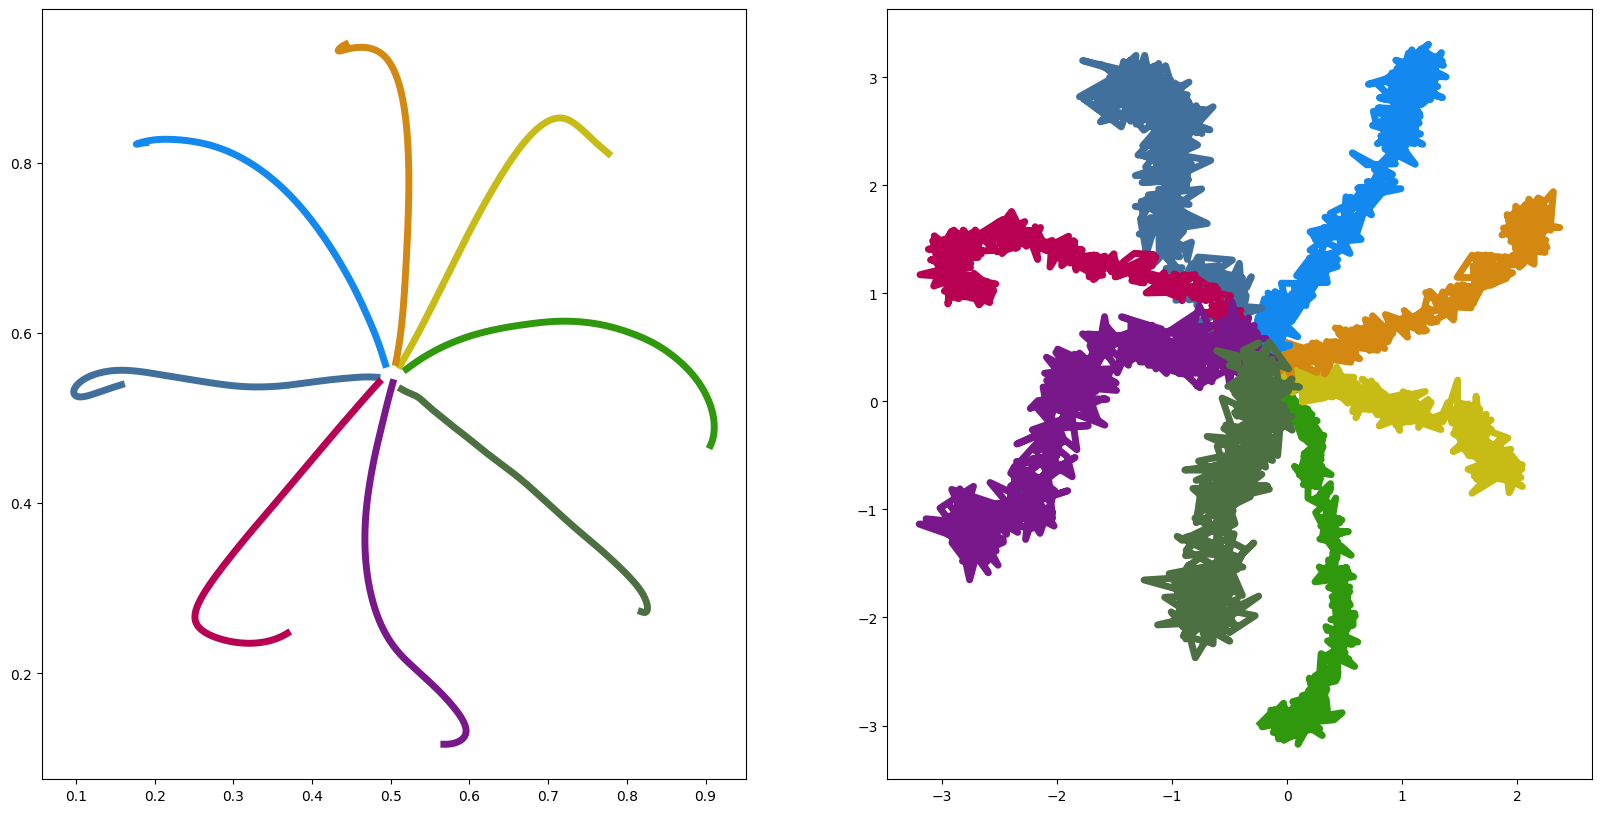

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(20, 10))

n_indices_per_angle = np.array([len(dataset.trial_info[trial_mask & (dataset.trial_info['cond_dir'] == angle)
                                                       & (dataset.trial_info['split'] == 'val')]['split'].to_numpy())
                                                       for angle in unique_angles])
colors = ['#2F980C', '#C7BC16', '#D38811', '#1389F0','#40709B', '#B80152', '#78188B','#4C7041']

for i, angle in enumerate(unique_angles):
    mean_hand_pos = np.mean(test_dataset.y_trial_data[np.sum(n_indices_per_angle[:i]):
                                                      np.sum(n_indices_per_angle[:i+1])], axis=0)[..., 100:] # the first 100 ms are before movement onset
    axs[0].plot(mean_hand_pos[0], mean_hand_pos[1], color=colors[i], linewidth=5)
    mean_encoder_outputs = np.mean(encoder_outputs[np.sum(n_indices_per_angle[:i]):
                                                   np.sum(n_indices_per_angle[:i+1])], axis=0)[:, tau_p:]
    axs[1].plot(mean_encoder_outputs[0, 100 + tau_p:], mean_encoder_outputs[1, 100 + tau_p:], color=colors[i], linewidth=5)

# **Demo-3**

In [ ]:
# 1. 补齐 allensdk 的核心依赖（不强制降级 numpy/pandas，避免编译错误）
!pip install allensdk --no-deps
!pip install SimpleITK argschema boto3 glymur ndx-events psycopg2-binary pynrrd scikit-build semver

# 2. 核心补丁：手动在 numpy 中注入 missing 的 VisibleDeprecationWarning
import numpy as np
if not hasattr(np, 'VisibleDeprecationWarning'):
    class VisibleDeprecationWarning(UserWarning):
        pass
    np.VisibleDeprecationWarning = VisibleDeprecationWarning

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import os
import matplotlib.pyplot as plt
import torch
import tqdm
from typing import List, Any

from sparks.data.allen.movies_multisess import make_allen_movies_dataset
from sparks.data.misc import LongCycler
from sparks.utils.test import test_on_batch
from sparks.utils.train import train_on_batch
from sparks.data.providers import AllenMoviesTargetProvider
from sparks.models.sparks import SPARKS
from sparks.models.dataclasses import HebbianAttentionConfig, AttentionConfig

In [ ]:
path_to_data = os.path.join("/path/to/allen_visual/")

(train_datasets, test_datasets,
    train_dls, test_dls) = make_allen_movies_dataset(path_to_data,
                                                    session_idxs=np.arange(2), # which sessions to load, indexed from 0
                                                    dt=0.01, # time bin size (in seconds), speeds up training at the cost of accuracy for the demo
                                                    batch_size=10,
                                                    mode='prediction', # frame ID prediction
                                                    )

Downloading:   0%|          | 0.00/2.86G [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/3.07G [00:00<?, ?B/s]

In [ ]:
embed_dim = 128  # attention embedding dimension
latent_dim = 64  # latent dimension
tau_s = 1.  # STDP decay period (in seconds)
tau_p = 5  # past time-steps window
tau_f = 1  # future time-steps window
n_layers = 0  # number of conventional attention layers
n_heads = 1  # number of attention heads
beta = 1e-6  # KDL regularisation strength

# if a gpu is available
if torch.cuda.is_available():
    device = torch.device('cuda')
# If on a recent macbook
elif torch.backends.mps.is_available():
    device = torch.device('mps:0')
else:
    device = torch.device('cpu')

input_sizes = [len(train_dataset.good_units_ids) for train_dataset in train_datasets]
output_size = 900

hebbian_config = HebbianAttentionConfig(tau_s=tau_s, dt=0.01) # Hebbian attention config
attention_config = AttentionConfig() # conventional attention config
model = SPARKS(n_neurons_per_session=input_sizes,
               embed_dim=embed_dim,
               latent_dim=latent_dim,
               tau_p=tau_p,
               tau_f=tau_f,
               hebbian_config=hebbian_config,
               attention_config=attention_config,
               output_dim_per_session=output_size,
               joint_decoder=True, # use a single decoder for all sessions
               device=device)

lr = 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.5)
loss_fn = torch.nn.CrossEntropyLoss()

In [ ]:
def train(sparks: SPARKS,
          train_dls: List,
          loss_fn: Any,
          optimizer: torch.optim.Optimizer,
          beta: float = 0.,
          dt=0.01,
          **kwargs):
    """
    Trains the model on a batch of inputs.

    Args:
        sparks (SPARKS): The SPARKS model instance.
        train_dls (List): List of Dataloaders to train on, typically one per session.
        loss_fn (Any): The loss function used to evaluate the model's predictions.
        optimizer (torch.optim.Optimizer): The optimizer algorithm used to update the model's parameters.
        latent_dim (int): The dimensionality of the latent space.
        tau_p (int): The size of the past window for the model to consider.
        tau_f (int): The size of the future window for the model to predict.
        beta (float, optional): The regularization strength of the Kullback–Leibler divergence in the loss function.
                                Default is 0.
        device (torch.device, optional): The device where the tensors will be allocated. Default is 'cpu'.
        **kwargs: Additional keyword arguments.

        Optional arguments include:
            - session_ids (np.ndarray): Array of session identifiers when training with multiple sessions. Default: np.arange(len(train_dls)).
            - online (bool): If True, updates the model parameters at every time-step. Default is False.
            - burnin (int): The number of initial steps to exclude from training. Default is 0.

    Returns:
        None. The model parameters are updated inline.
    """

    session_ids = kwargs.get('session_ids', np.arange(len(train_dls)))
    random_order = np.random.choice(np.arange(len(train_dls)), size=len(train_dls), replace=False)
    train_iterator = LongCycler([train_dls[i] for i in random_order])

    for i, (inputs, _) in enumerate(train_iterator):
        target_provider = AllenMoviesTargetProvider(frames=None,
                                                    mode='prediction',
                                                    dt=dt)
        train_on_batch(sparks=sparks,
                       inputs=inputs,
                       target_provider=target_provider,
                       loss_fn=loss_fn,
                       optimizer=optimizer,
                       beta=beta,
                       session_id=session_ids[random_order[i % len(train_dls)]],
                       **kwargs)


@torch.no_grad()
def test(sparks: SPARKS,
         test_dls: List,
         loss_fn: Any = None,
         device: torch.device = 'cpu',
         dt=0.01,
         **kwargs):
    """
    Tests the model on a dataset represented by a dataloader and computes the loss.

    Args:
        sparks (SPARKS): The SPARKS model instance.
        test_dls  (List[torch.utils.data.DataLoader]): Dataloaders for the testing data.
        latent_dim (int): The dimensionality of the latent space.
        tau_p (int): The size of the past window for the model to consider.
        tau_f (int, optional): The size of the future window for the model to predict. Default is 1.
        loss_fn (Any, optional): The loss function used to evaluate the model's predictions. Default is None.
        device (torch.device, optional): The device where the tensors will be allocated. Default is 'cpu'.
        **kwargs (dict, optional): Additional keyword arguments for advanced configurations.

        Optional arguments include:
            - session_ids (np.ndarray): Array of session identifiers when training with multiple sessions. Default: np.arange(len(test_dls)).
            - online (bool): If True, updates the model parameters at every time-step. Default is False.
            - burnin (int): The number of initial steps to exclude from training. Default is 0.
            - act (callable): Activation function to apply to the decoder outputs. Default is identity.

    Returns:
        test_loss (float): The computed loss for the test dataset.
        encoder_outputs (torch.tensor): The outputs from the encoder.
        decoder_outputs (torch.tensor): The outputs from the decoder.
    """

    encoder_outputs = torch.Tensor()
    decoder_outputs = torch.Tensor()
    test_loss = 0

    session_ids = kwargs.get('session_ids', np.arange(len(test_dls)))

    target_provider = AllenMoviesTargetProvider(frames=None, mode='prediction', dt=dt)

    for i, test_dl in enumerate(test_dls):
        test_iterator = iter(test_dl)
        for inputs, _ in test_iterator:
            test_loss, encoder_outputs_batch, decoder_outputs_batch = test_on_batch(sparks=sparks,
                                                                                    inputs=inputs,
                                                                                    target_provider=target_provider,
                                                                                    test_loss=test_loss,
                                                                                    loss_fn=loss_fn,
                                                                                    device=device,
                                                                                    session_id=session_ids[i],
                                                                                    **kwargs)

            encoder_outputs = torch.cat((encoder_outputs, encoder_outputs_batch), dim=0)
            decoder_outputs = torch.cat((decoder_outputs, decoder_outputs_batch), dim=0)

    test_acc = calculate_test_acc(decoder_outputs, targets=target_provider.targets)

    return test_acc, encoder_outputs, decoder_outputs


@torch.no_grad()
def calculate_test_acc(decoder_outputs: torch.tensor, targets: torch.tensor, tol: int = 30):
    """
    Calculate 1s-test accuracy for the Allen movies datasets
    Args:
        decoder_outputs (torch.tensor): SPARKS predictions.
        frames (torch.tensor): Targets.
        tol (int, optional): Tolerance in number of frames, defaults to 30 (corresponding to 1s).

    Returns:
        test_acc (float): The testing accuracy on this batch.
                          Accuracy is computed as the fraction of time-steps for which the predicted frame was within
                          1s of the correct one.
        encoder_outputs_batch (torch.Tensor): The outputs of the encoder.
        decoder_outputs_batch (torch.Tensor): The outputs of the decoder.
    """

    target_windows = [np.arange(t - tol, t + tol)[None, :] for t in targets.numpy()]
    test_acc = np.mean(np.array([[np.isin(decoder_outputs[k, :, t].cpu().argmax(dim=-1), target_windows[t])
                                  for t in range(decoder_outputs.shape[-1])]
                                 for k in range(decoder_outputs.shape[0])]))

    return test_acc

In [ ]:
test_period = 1
n_epochs = 1  # Number of training epochs

pbar = tqdm.tqdm(range(n_epochs))
for epoch in pbar:
    train(sparks=model,
            train_dls=train_dls,
            loss_fn=loss_fn,
            optimizer=optimizer,
            beta=beta,
            device=device)
    scheduler.step()

    if (epoch + 1) % test_period == 0:
        test_acc, encoder_outputs, decoder_outputs = test(sparks=model,
                                                            test_dls=test_dls,
                                                            loss_fn=loss_fn)

        pbar.set_description("Epoch %d, acc: %.3f" % (epoch, test_acc))

Epoch 0, acc: 0.075: 100%|██████████| 1/1 [00:41<00:00, 41.40s/it]


In [ ]:
session_idxs = [2] # new session
(new_train_datasets, new_test_datasets,
    new_train_dls, new_test_dls) = make_allen_movies_dataset(path_to_data,
                                                    session_idxs=session_idxs, # new session
                                                    dt=0.01, # time bin size (in seconds), speeds up training at the cost of accuracy for the demo
                                                    batch_size=10,
                                                    mode='prediction', # frame ID prediction
                                                    )

# Add a new Hebbian attention head for the new session
for i, train_dataset in enumerate(new_train_datasets):
    model.add_session(n_neurons=len(train_dataset.good_units_ids),
                      hebbian_config=hebbian_config,
                      session_id=session_idxs[i]) # session_id allows the model to keep track of which attention head to use for which session

Downloading:   0%|          | 0.00/1.74G [00:00<?, ?B/s]

In [ ]:
pbar = tqdm.tqdm(range(n_epochs))
for epoch in pbar:
    train(sparks=model,
            train_dls=new_train_dls,
            loss_fn=loss_fn,
            optimizer=optimizer,
            beta=beta,
            session_ids=np.array([2]), # session_ids allows to keep track of the session IDs when training with multiple sessions
            device=device)
    scheduler.step()

    if (epoch + 1) % test_period == 0:
        test_acc, encoder_outputs, decoder_outputs = test(sparks=model,
                                                            test_dls=new_test_dls,
                                                            loss_fn=loss_fn,
                                                            session_ids=np.array([2]))

        pbar.set_description("Epoch %d, acc: %.3f" % (epoch, test_acc))

Epoch 0, acc: 0.069: 100%|██████████| 1/1 [00:19<00:00, 19.80s/it]


In [ ]:
res_path = os.path.join(os.getcwd(), 'results/allen_results') # path to where the data is located.
# by default where the notebook is located, if the data isn't found it will be downloaded from
# https://github.com/Iacaruso-lab/sparks-figures/results/allen_results

if not os.path.exists(os.path.join(res_path, 'test_enc_outputs_best.npy')):
    # create the directory
    if not os.path.exists(res_path):
        os.makedirs(res_path)
    # download the data
    import urllib.request
    urllib.request.urlretrieve("https://github.com/Iacaruso-lab/sparks-figures/raw/refs/heads/main/results/allen_results/test_enc_outputs_best.npy",
                               os.path.join(res_path, 'test_enc_outputs_best.npy'))

(np.float64(-21.309731940428414),
 np.float64(33.963160971800484),
 np.float64(-19.133969446023304),
 np.float64(28.91392817099889),
 np.float64(-33.36809300879638),
 np.float64(0.25833320120970416))

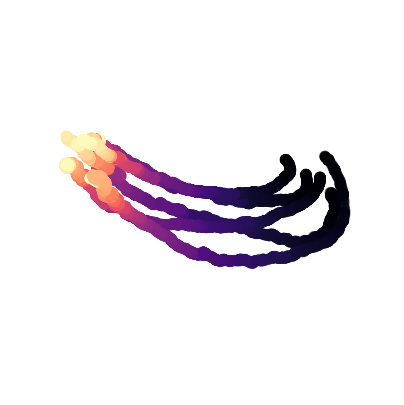

In [ ]:
fig = plt.figure(figsize = (12,5))
plt.rcParams['axes.facecolor'] = 'white'

dt = 0.006
time_bin_edges = np.concatenate((np.arange(0, 30., dt), np.array([30.])))
frames_bin_edges = np.concatenate((np.arange(1/30, 30, 1/30), np.array([30.])))
targets = np.array([np.where(time_bin_edges[i] <= frames_bin_edges)[0][0] for i in range(1, len(time_bin_edges))])

tau_p = 6
encs = np.load(os.path.join(res_path, 'test_enc_outputs_best.npy'))[..., tau_p:].transpose(0, 2, 1)

ax1 = plt.subplot(111, projection='3d')

for i in range(5):
    encs_sess = np.mean(encs[i:i+1, :, :], axis=0)
    a = ax1.scatter(encs_sess[:, 0], encs_sess[:, 1], encs_sess[:, 2], cmap = 'magma', c=targets, s=50, label='block 1')
ax1.axis('off')